# Late Forecast: Wiki Rigor, Movement, and Surprise Model Comparison

This notebook stays on the late-forecast subproblem and runs one controlled Wikipedia residual experiment before moving on.

The target is the consensus estimate residual:

$$r_i = \log\left(\frac{ActualOW_i}{ConsensusEstimate_i}\right)$$

The previous pass showed that raw Wiki views are not the right late adjustment signal. The stronger paper-style variables are edit-side activity, especially collaborative rigor:

- $V$: pageviews;
- $E$: human edits;
- $U$: unique human editors;
- $R$: collaborative rigor, measured as user switches in the human edit train.

Because $E$, $U$, and $R$ are highly collinear, this notebook keeps the candidate set small and tests exactly:

1. raw consensus;
2. $\log R$ at the late forecast origin;
3. post-estimate movement in $\log R$;
4. $\log R$ surprise after removing the consensus/franchise scale effect.

Estimate age and larger interactions are intentionally left out for now.


In [277]:
import os
import sys
import tempfile
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "pm-box-office-matplotlib"))
os.environ.setdefault("XDG_CACHE_HOME", os.path.join(tempfile.gettempdir(), "pm-box-office-cache"))

repo_root = Path.cwd().parent if Path.cwd().name == "eda" else Path.cwd()
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import chi2

from pm_box_office.db.connection import connect_database

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.options.display.float_format = "{:,.4f}".format


## Parameters

The forecast origin is frozen at the benchmark's cutoff date: Thursday before the opening Friday. All Wiki windows end on or before that date.


In [278]:
BENCHMARK_PATH = repo_root / "data" / "diagnostics" / "late_forecast_consensus_benchmark.csv"
TRAIN_YEARS = set(range(2010, 2020)) | {2022, 2023}
TEST_START_YEAR = 2024
EXCLUDED_RELEASE_YEARS = {2020, 2021}
EXCLUDE_DOC_CONCERT_SPECIAL_EVENTS = True
MIN_GROUP_N_FOR_GROUP_SIGMA = 10
PAPER_ORIGIN_DAYS = [-30, -21, -14, -7, -3, -1]
DAILY_FORECAST_ORIGIN_DAYS = list(range(-14, 0))

MODEL_LABELS = {
    "model_0_raw_consensus": "Model 0: raw consensus",
    "model_1_log_rigor": "Model 1: log collaborative rigor",
    "model_2_wiki_move": "Model 2: post-estimate Wiki movement",
    "model_3_wiki_surprise": "Model 3: Wiki rigor surprise",
}
FORECAST_COLUMNS = {
    "model_0_raw_consensus": "model_0_raw_consensus_forecast_usd",
    "model_1_log_rigor": "model_1_log_rigor_forecast_usd",
    "model_2_wiki_move": "model_2_wiki_move_forecast_usd",
    "model_3_wiki_surprise": "model_3_wiki_surprise_forecast_usd",
}


## Load Benchmark Dataset

The benchmark notebook owns the consensus construction. This notebook starts from its one-row-per-release export and adds late Wiki features.


In [279]:
if not BENCHMARK_PATH.exists():
    raise FileNotFoundError(
        f"Missing {BENCHMARK_PATH}. Run eda/late_forecast_consensus_benchmark.ipynb first."
    )

consensus = pd.read_csv(BENCHMARK_PATH)

for col in [
    "opening_weekend_start",
    "forecast_cutoff_date",
    "earliest_estimate_date",
    "latest_estimate_date",
]:
    if col in consensus.columns:
        consensus[col] = pd.to_datetime(consensus[col], errors="coerce")

for col in ["is_franchise", "is_doc_concert", "is_wide_release", "is_large_release"]:
    if col in consensus.columns:
        consensus[col] = consensus[col].fillna(False).astype(bool)

required_cols = {
    "release_run_id",
    "movie_id",
    "title",
    "opening_weekend_start",
    "forecast_cutoff_date",
    "latest_estimate_date",
    "release_year",
    "actual_opening_weekend_gross_usd",
    "consensus_estimate_usd",
    "log_actual_opening_weekend",
    "log_consensus_estimate",
    "benchmark_residual_log",
    "is_franchise",
    "is_doc_concert",
    "estimate_source_count",
}
missing = sorted(required_cols - set(consensus.columns))
if missing:
    raise ValueError(f"Benchmark CSV is missing required columns: {missing}")

consensus.shape, consensus["opening_weekend_start"].min(), consensus["opening_weekend_start"].max()


((180, 39), Timestamp('2014-09-19 00:00:00'), Timestamp('2026-07-03 00:00:00'))

## Refine the Late-Forecast Universe

Concert/documentary/special-event films are removed from this subproblem because they are outside the intended use case and can add noise to the residual model.


In [280]:
def text_contains(series, pattern):
    return series.fillna("").astype(str).str.contains(pattern, case=False, regex=True)

special_event_text = (
    consensus.get("genre", pd.Series(index=consensus.index, dtype="object")).fillna("")
    + " "
    + consensus.get("release_type", pd.Series(index=consensus.index, dtype="object")).fillna("")
    + " "
    + consensus.get("title", pd.Series(index=consensus.index, dtype="object")).fillna("")
)

consensus["is_doc_concert_special_event"] = (
    consensus["is_doc_concert"].fillna(False)
    | text_contains(special_event_text, r"\b(?:documentary|concert|special event|event cinema|fan event)\b")
)

modeling = consensus.copy()
if EXCLUDE_DOC_CONCERT_SPECIAL_EVENTS:
    modeling = modeling.loc[~modeling["is_doc_concert_special_event"]].copy()

modeling = modeling.loc[
    ~modeling["release_year"].isin(EXCLUDED_RELEASE_YEARS)
    & (modeling["actual_opening_weekend_gross_usd"] > 0)
    & (modeling["consensus_estimate_usd"] > 0)
    & modeling["forecast_cutoff_date"].notna()
    & modeling["latest_estimate_date"].notna()
].copy()

modeling["estimate_age_days"] = (
    modeling["forecast_cutoff_date"] - modeling["latest_estimate_date"]
).dt.days
modeling["estimate_age_days"] = modeling["estimate_age_days"].clip(lower=0)
modeling["estimate_age_days"] = modeling["estimate_age_days"].fillna(modeling["estimate_age_days"].median())
modeling["late_origin_day"] = (
    modeling["forecast_cutoff_date"].dt.normalize() - modeling["opening_weekend_start"].dt.normalize()
).dt.days.astype(int)
modeling["estimate_origin_day"] = (
    modeling["latest_estimate_date"].dt.normalize() - modeling["opening_weekend_start"].dt.normalize()
).dt.days.astype(int)

modeling["log_opening_weekend_theaters"] = np.log1p(
    pd.to_numeric(modeling.get("opening_weekend_theaters"), errors="coerce")
)

universe_summary = pd.DataFrame(
    [
        {"stage": "benchmark export", "movies": len(consensus)},
        {"stage": "after refined-universe filters", "movies": len(modeling)},
        {"stage": "excluded doc/concert/special-event", "movies": int(consensus["is_doc_concert_special_event"].sum())},
    ]
)
universe_summary


,stage,movies
0,benchmark export,180
1,after refined-universe filters,174
2,excluded doc/concert/special-event,6


## Load Paper-Style Wikipedia Activity

The query computes the Wikipedia-paper variables in movie time:

- `V`: cumulative pageviews;
- `E`: cumulative human edits;
- `U`: cumulative unique human editors;
- `R`: cumulative collaborative rigor, where a rigor increment is counted when the human edit train switches users.

It loads the standard lag origins plus each movie's actual late forecast origin and latest-estimate date. That lets us compute `WikiAtEstimate`, `WikiAtOrigin`, and `WikiMove` without leaking post-origin information.


In [281]:
def read_db_frame(sql, params=None):
    conn = connect_database()
    try:
        cursor = conn.execute(sql, params or ())
        return pd.DataFrame(cursor.fetchall(), columns=[column.name for column in cursor.description])
    finally:
        conn.close()

release_run_ids = sorted(modeling["release_run_id"].dropna().astype(int).unique().tolist())
if not release_run_ids:
    raise ValueError("No eligible releases remain before loading Wiki features.")

modeling["late_origin_day"] = (
    modeling["forecast_cutoff_date"].dt.normalize() - modeling["opening_weekend_start"].dt.normalize()
).dt.days.astype(int)
origin_days = sorted(set(PAPER_ORIGIN_DAYS) | set(DAILY_FORECAST_ORIGIN_DAYS) | set(modeling["late_origin_day"].dropna().astype(int)) | set(modeling["estimate_origin_day"].dropna().astype(int)))

wiki_paper_sql = """
WITH forecast_origins AS (
    SELECT unnest(%s::int[]) AS origin_day
), wiki_matches AS (
    SELECT
        src.movie_id,
        split_part(src.source_movie_id, ':', 1) AS language,
        split_part(src.source_movie_id, ':', 2)::integer AS wiki_page_id
    FROM movie_source_ids src
    WHERE src.source = 'wikipedia'
      AND src.match_status IN ('matched', 'manual_override')
      AND src.source_movie_id ~ '^[a-z-]+:[0-9]+$'
), base AS (
    SELECT
        o.release_run_id,
        o.movie_id,
        o.title,
        o.opening_weekend_start::date AS opening_weekend_start,
        (o.opening_weekend_start::date + (fo.origin_day * INTERVAL '1 day'))::date AS origin_date,
        (o.opening_weekend_start::date - INTERVAL '30 days')::date AS cumulative_start_date,
        (o.opening_weekend_start::date + ((fo.origin_day - 6) * INTERVAL '1 day'))::date AS recent7_start_date,
        fo.origin_day AS forecast_origin_day,
        wm.language,
        wm.wiki_page_id
    FROM analytics.eda_movie_openings o
    JOIN wiki_matches wm ON wm.movie_id = o.movie_id
    CROSS JOIN forecast_origins fo
    WHERE o.release_run_id = ANY(%s)
), pageviews AS (
    SELECT
        b.release_run_id,
        b.forecast_origin_day,
        SUM(pv.views) FILTER (
            WHERE pv.view_date::date BETWEEN b.cumulative_start_date AND b.origin_date
        )::numeric AS v_cume,
        SUM(pv.views) FILTER (
            WHERE pv.view_date::date BETWEEN b.recent7_start_date AND b.origin_date
        )::numeric AS v_recent7
    FROM base b
    LEFT JOIN wiki_pageviews_daily pv
      ON pv.language = b.language
     AND pv.wiki_page_id = b.wiki_page_id
     AND pv.view_date::date BETWEEN b.cumulative_start_date AND b.origin_date
    GROUP BY b.release_run_id, b.forecast_origin_day
), human_revisions AS (
    SELECT
        wr.language,
        wr.wiki_page_id,
        wr.rev_id,
        wr.rev_timestamp,
        wr.rev_date::date AS rev_date,
        wr.user_key,
        CASE
            WHEN LAG(wr.user_key) OVER (
                PARTITION BY wr.language, wr.wiki_page_id
                ORDER BY wr.rev_timestamp, wr.rev_id
            ) IS NULL THEN 1
            WHEN LAG(wr.user_key) OVER (
                PARTITION BY wr.language, wr.wiki_page_id
                ORDER BY wr.rev_timestamp, wr.rev_id
            ) <> wr.user_key THEN 1
            ELSE 0
        END AS rigor_increment
    FROM wiki_revisions wr
    WHERE wr.is_bot = 0
), revisions AS (
    SELECT
        b.release_run_id,
        b.forecast_origin_day,
        COUNT(hr.user_key) FILTER (
            WHERE hr.rev_date BETWEEN b.cumulative_start_date AND b.origin_date
        )::numeric AS e_cume,
        COUNT(DISTINCT hr.user_key) FILTER (
            WHERE hr.rev_date BETWEEN b.cumulative_start_date AND b.origin_date
        )::numeric AS u_cume,
        COALESCE(SUM(hr.rigor_increment) FILTER (
            WHERE hr.rev_date BETWEEN b.cumulative_start_date AND b.origin_date
        ), 0)::numeric AS r_cume,
        COUNT(hr.user_key) FILTER (
            WHERE hr.rev_date BETWEEN b.recent7_start_date AND b.origin_date
        )::numeric AS e_recent7,
        COUNT(DISTINCT hr.user_key) FILTER (
            WHERE hr.rev_date BETWEEN b.recent7_start_date AND b.origin_date
        )::numeric AS u_recent7,
        COALESCE(SUM(hr.rigor_increment) FILTER (
            WHERE hr.rev_date BETWEEN b.recent7_start_date AND b.origin_date
        ), 0)::numeric AS r_recent7
    FROM base b
    LEFT JOIN human_revisions hr
      ON hr.language = b.language
     AND hr.wiki_page_id = b.wiki_page_id
     AND hr.rev_date BETWEEN b.cumulative_start_date AND b.origin_date
    GROUP BY b.release_run_id, b.forecast_origin_day
)
SELECT
    b.release_run_id,
    b.movie_id,
    b.title,
    b.opening_weekend_start,
    b.forecast_origin_day,
    b.origin_date,
    COALESCE(p.v_cume, 0) AS v_cume,
    COALESCE(r.e_cume, 0) AS e_cume,
    COALESCE(r.u_cume, 0) AS u_cume,
    COALESCE(r.r_cume, 0) AS r_cume,
    COALESCE(p.v_recent7, 0) AS v_recent7,
    COALESCE(r.e_recent7, 0) AS e_recent7,
    COALESCE(r.u_recent7, 0) AS u_recent7,
    COALESCE(r.r_recent7, 0) AS r_recent7
FROM base b
LEFT JOIN pageviews p USING (release_run_id, forecast_origin_day)
LEFT JOIN revisions r USING (release_run_id, forecast_origin_day)
"""
wiki_paper = read_db_frame(wiki_paper_sql, (origin_days, release_run_ids))

for date_col in ["opening_weekend_start", "origin_date"]:
    wiki_paper[date_col] = pd.to_datetime(wiki_paper[date_col], errors="coerce")
for column in [
    "release_run_id", "movie_id", "forecast_origin_day",
    "v_cume", "e_cume", "u_cume", "r_cume",
    "v_recent7", "e_recent7", "u_recent7", "r_recent7",
]:
    wiki_paper[column] = pd.to_numeric(wiki_paper[column], errors="coerce")

print(f"Paper-style Wiki rows loaded: {len(wiki_paper):,}")
print(f"Release runs with Wiki paper features: {wiki_paper['release_run_id'].nunique():,}")
wiki_paper.head()


Paper-style Wiki rows loaded: 2,672
Release runs with Wiki paper features: 167


,release_run_id,movie_id,title,opening_weekend_start,forecast_origin_day,origin_date,v_cume,e_cume,u_cume,r_cume,v_recent7,e_recent7,u_recent7,r_recent7
0,11,11,21 Bridges (2019),2019-11-22,-30,2019-10-23,"2,913.0000",0.0000,0.0000,0.0000,"2,913.0000",0.0000,0.0000,0.0000
1,11,11,21 Bridges (2019),2019-11-22,-21,2019-11-01,"26,198.0000",7.0000,5.0000,6.0000,"19,853.0000",6.0000,5.0000,5.0000
2,11,11,21 Bridges (2019),2019-11-22,-14,2019-11-08,"61,516.0000",12.0000,6.0000,9.0000,"35,318.0000",5.0000,2.0000,3.0000
3,11,11,21 Bridges (2019),2019-11-22,-13,2019-11-09,"67,720.0000",14.0000,8.0000,11.0000,"37,839.0000",7.0000,4.0000,5.0000
4,11,11,21 Bridges (2019),2019-11-22,-12,2019-11-10,"74,159.0000",14.0000,8.0000,11.0000,"39,706.0000",7.0000,4.0000,5.0000


## Build Late-Origin Rigor, Movement, and Surprise Features

`WikiAtOrigin` is $\log(1 + R)$ at the frozen late forecast origin. `WikiAtEstimate` is $\log(1 + R)$ on the latest estimate date used by the consensus. `WikiMove` is the post-estimate change between those two dates.

`WikiSurprise` is computed inside each split from a training-only expected-rigor model:

$$\log R_i = \alpha + \beta_1\log(ConsensusEstimate_i)+\beta_2Franchise_i+\varepsilon_i$$


In [282]:
for prefix in ["cume", "recent7"]:
    for column in ["v", "e", "u", "r"]:
        wiki_paper[f"log_{column}_{prefix}"] = np.log1p(wiki_paper[f"{column}_{prefix}"].clip(lower=0))

origin_feature_cols = [
    "release_run_id", "forecast_origin_day", "origin_date",
    "v_cume", "e_cume", "u_cume", "r_cume",
    "v_recent7", "e_recent7", "u_recent7", "r_recent7",
    "log_v_cume", "log_e_cume", "log_u_cume", "log_r_cume",
    "log_v_recent7", "log_e_recent7", "log_u_recent7", "log_r_recent7",
]
late_wiki = modeling[["release_run_id", "late_origin_day"]].merge(
    wiki_paper[origin_feature_cols],
    left_on=["release_run_id", "late_origin_day"],
    right_on=["release_run_id", "forecast_origin_day"],
    how="inner",
)
estimate_wiki = modeling[["release_run_id", "estimate_origin_day"]].merge(
    wiki_paper[origin_feature_cols],
    left_on=["release_run_id", "estimate_origin_day"],
    right_on=["release_run_id", "forecast_origin_day"],
    how="inner",
)

late_rename = {
    col: f"{col}_origin"
    for col in origin_feature_cols
    if col not in {"release_run_id"}
}
estimate_rename = {
    col: f"{col}_estimate"
    for col in origin_feature_cols
    if col not in {"release_run_id"}
}
late_wiki = late_wiki.rename(columns=late_rename).drop(columns=["late_origin_day"], errors="ignore")
estimate_wiki = estimate_wiki.rename(columns=estimate_rename).drop(columns=["estimate_origin_day"], errors="ignore")

modeling = modeling.merge(late_wiki, on="release_run_id", how="inner")
modeling = modeling.merge(estimate_wiki, on="release_run_id", how="inner")

modeling["wiki_at_origin_log_r"] = modeling["log_r_cume_origin"]
modeling["wiki_at_estimate_log_r"] = modeling["log_r_cume_estimate"]
modeling["wiki_move_log_r"] = modeling["wiki_at_origin_log_r"] - modeling["wiki_at_estimate_log_r"]
modeling["wiki_move_recent7_log_r"] = modeling["log_r_recent7_origin"] - modeling["log_r_recent7_estimate"]

modeling["split"] = np.select(
    [modeling["release_year"].isin(TRAIN_YEARS), modeling["release_year"] >= TEST_START_YEAR],
    ["train", "test"],
    default="holdout_unused",
)
modeling = modeling.loc[modeling["split"].isin(["train", "test"])].copy()

split_summary = (
    modeling.groupby("split")
    .agg(
        movies=("release_run_id", "count"),
        first_opening=("opening_weekend_start", "min"),
        last_opening=("opening_weekend_start", "max"),
        median_consensus_usd=("consensus_estimate_usd", "median"),
        median_r_at_estimate=("r_cume_estimate", "median"),
        median_r_at_origin=("r_cume_origin", "median"),
        median_wiki_move_log_r=("wiki_move_log_r", "median"),
        zero_origin_rigor_share=("r_cume_origin", lambda s: (s == 0).mean()),
    )
)
split_summary


,movies,first_opening,last_opening,median_consensus_usd,median_r_at_estimate,median_r_at_origin,median_wiki_move_log_r,zero_origin_rigor_share
split,,,,,,,,
test,82,2024-01-12,2026-07-03,"11,250,000.0000",44.5000,49.5000,0.0000,0.0244
train,85,2014-09-19,2023-12-29,"8,350,000.0000",33.0000,34.0000,0.0000,0.0235


## Lag and Cumulative Wiki Effects

Inspect paper-style activity at several movie-time origins before fitting the point model. This checks whether cumulative or trailing engagement strengthens as the release approaches the late forecast origin.


In [283]:
def pearson_corr(x, y):
    pair = pd.DataFrame({"x": x, "y": y}).replace([np.inf, -np.inf], np.nan).dropna()
    if len(pair) < 3 or pair["x"].nunique() < 2 or pair["y"].nunique() < 2:
        return np.nan
    return pair["x"].corr(pair["y"])

lag_panel = modeling[[
    "release_run_id",
    "release_year",
    "log_actual_opening_weekend",
    "benchmark_residual_log",
    "split",
]].merge(wiki_paper, on="release_run_id", how="inner")
lag_panel = lag_panel.loc[lag_panel["forecast_origin_day"].isin(PAPER_ORIGIN_DAYS)].copy()

lag_rows = []
for feature_window in ["cume", "recent7"]:
    for origin_day, group in lag_panel.groupby("forecast_origin_day"):
        group = group.copy()
        for column in ["e", "u", "r"]:
            log_col = f"log_{column}_{feature_window}"
            std = group[log_col].std(ddof=0)
            group[f"z_{log_col}"] = (group[log_col] - group[log_col].mean()) / std if std and np.isfinite(std) else np.nan
        group["wiki_engagement_window"] = group[[
            f"z_log_e_{feature_window}",
            f"z_log_u_{feature_window}",
            f"z_log_r_{feature_window}",
        ]].mean(axis=1)
        lag_rows.append(
            {
                "feature_window": feature_window,
                "forecast_origin_day": int(origin_day),
                "n": len(group),
                "corr_logOW_logV": pearson_corr(group[f"log_v_{feature_window}"], group["log_actual_opening_weekend"]),
                "corr_logOW_logE": pearson_corr(group[f"log_e_{feature_window}"], group["log_actual_opening_weekend"]),
                "corr_logOW_logU": pearson_corr(group[f"log_u_{feature_window}"], group["log_actual_opening_weekend"]),
                "corr_logOW_logR": pearson_corr(group[f"log_r_{feature_window}"], group["log_actual_opening_weekend"]),
                "corr_residual_engagement": pearson_corr(group["wiki_engagement_window"], group["benchmark_residual_log"]),
                "corr_residual_logR": pearson_corr(group[f"log_r_{feature_window}"], group["benchmark_residual_log"]),
            }
        )

lag_effect_summary = pd.DataFrame(lag_rows).sort_values(["feature_window", "forecast_origin_day"])
lag_effect_summary


,feature_window,forecast_origin_day,n,corr_logOW_logV,corr_logOW_logE,corr_logOW_logU,corr_logOW_logR,corr_residual_engagement,corr_residual_logR
0,cume,-30,167,0.3363,0.2563,0.3370,0.3096,0.0481,0.0392
1,cume,-21,167,0.3062,0.4888,0.5252,0.5132,0.1477,0.1482
2,cume,-14,167,0.2997,0.5476,0.5926,0.5940,0.1764,0.1826
3,cume,-7,167,0.3089,0.5393,0.5842,0.5807,0.1415,0.1429
4,cume,-3,167,0.3115,0.5622,0.6021,0.6028,0.1400,0.1459
5,cume,-1,167,0.3083,0.6054,0.6474,0.6436,0.1572,0.1646
6,recent7,-30,167,0.3363,0.2563,0.3370,0.3096,0.0481,0.0392
7,recent7,-21,167,0.3117,0.4560,0.4742,0.4796,0.1580,0.1659
8,recent7,-14,167,0.3123,0.5580,0.6172,0.6166,0.2060,0.2128
9,recent7,-7,167,0.3274,0.5179,0.5434,0.5483,0.0991,0.0967


## Fit Models on Training Residuals Only

Model 0 is raw consensus. The candidate residual regressions are intentionally controlled:

- Model 1: current best simple edit-side level, `logR` at the origin;
- Model 2: post-estimate movement, `logR(origin) - logR(estimate date)`;
- Model 3: `logR` surprise after removing the consensus/franchise scale effect.

Estimate age is excluded because the prior pass was unstable in later folds.


In [284]:

# This cell depends on the dataset-building cells above. If this raises,
# use Kernel > Restart & Run All so the refined universe and Wiki features exist.
required_modeling_columns = {
    "split",
    "benchmark_residual_log",
    "wiki_at_origin_log_r",
    "wiki_move_log_r",
    "log_consensus_estimate",
    "is_franchise",
}
if "modeling" not in globals():
    raise RuntimeError(
        "`modeling` is not defined. Restart the kernel and run all cells from the top; "
        "an older copied model-fit block is stale and should not be run."
    )
missing_modeling_columns = sorted(required_modeling_columns - set(modeling.columns))
if missing_modeling_columns:
    raise RuntimeError(
        f"`modeling` is missing required columns {missing_modeling_columns}. "
        "Restart the kernel and run all cells from the top."
    )

def fit_lstsq(x, y):
    beta, *_ = np.linalg.lstsq(x, y, rcond=None)
    fitted = x @ beta
    residuals = y - fitted
    dof = max(len(y) - x.shape[1], 1)
    sigma = float(np.sqrt(np.sum(residuals**2) / dof))
    return beta, sigma, residuals


def expected_rigor_matrix(df):
    return np.column_stack(
        [
            np.ones(len(df)),
            df["log_consensus_estimate"].to_numpy(dtype=float),
            df["is_franchise"].fillna(False).astype(float).to_numpy(),
        ]
    )


def add_wiki_surprise(train, *frames):
    train_fit = train.dropna(subset=["wiki_at_origin_log_r", "log_consensus_estimate", "is_franchise"]).copy()
    x_train = expected_rigor_matrix(train_fit)
    y_train = train_fit["wiki_at_origin_log_r"].to_numpy(dtype=float)
    beta, sigma, _ = fit_lstsq(x_train, y_train)

    out_frames = []
    for frame in frames:
        out = frame.copy()
        expected = expected_rigor_matrix(out) @ beta
        out["expected_wiki_at_origin_log_r"] = expected
        out["wiki_surprise_log_r"] = out["wiki_at_origin_log_r"] - out["expected_wiki_at_origin_log_r"]
        out_frames.append(out)

    expected_row = {
        "n_train_expected_rigor": len(train_fit),
        "expected_rigor_sigma_log": sigma,
        "expected_rigor_intercept": beta[0],
        "expected_rigor_log_consensus_beta": beta[1],
        "expected_rigor_franchise_beta": beta[2],
    }
    return (*out_frames, expected_row)


def residual_model_matrix(df, model_key):
    if model_key == "model_1_log_rigor":
        return np.column_stack([np.ones(len(df)), df["wiki_at_origin_log_r"].to_numpy(dtype=float)])
    if model_key == "model_2_wiki_move":
        return np.column_stack([np.ones(len(df)), df["wiki_move_log_r"].to_numpy(dtype=float)])
    if model_key == "model_3_wiki_surprise":
        return np.column_stack([np.ones(len(df)), df["wiki_surprise_log_r"].to_numpy(dtype=float)])
    raise ValueError(f"No residual design matrix for {model_key}")


def residual_coefficient_names(model_key):
    if model_key == "model_1_log_rigor":
        return ["intercept_alpha", "log_r_beta"]
    if model_key == "model_2_wiki_move":
        return ["intercept_alpha", "wiki_move_beta"]
    if model_key == "model_3_wiki_surprise":
        return ["intercept_alpha", "wiki_surprise_beta"]
    raise ValueError(f"No coefficient names for {model_key}")


def fit_residual_model(train, model_key):
    needed = ["benchmark_residual_log"]
    if model_key == "model_1_log_rigor":
        needed.append("wiki_at_origin_log_r")
    if model_key == "model_2_wiki_move":
        needed.append("wiki_move_log_r")
    if model_key == "model_3_wiki_surprise":
        needed.append("wiki_surprise_log_r")
    train_fit = train.dropna(subset=needed).copy()
    x = residual_model_matrix(train_fit, model_key)
    y = train_fit["benchmark_residual_log"].to_numpy(dtype=float)
    beta, sigma, _ = fit_lstsq(x, y)
    return beta, sigma, len(train_fit)


def add_fold_forecasts(train, test):
    train_features, test_features, surprise_row = add_wiki_surprise(train, train, test)
    train_out = train_features.copy()
    test_out = test_features.copy()
    coefficient_rows = []

    for out in [train_out, test_out]:
        out["model_0_raw_consensus_predicted_residual_log"] = 0.0
        out["model_0_raw_consensus_forecast_usd"] = out["consensus_estimate_usd"]

    for model_key in ["model_1_log_rigor", "model_2_wiki_move", "model_3_wiki_surprise"]:
        beta, sigma, n_train = fit_residual_model(train_features, model_key)
        for out in [train_out, test_out]:
            predicted_residual = residual_model_matrix(out, model_key) @ beta
            out[f"{model_key}_predicted_residual_log"] = predicted_residual
            out[f"{model_key}_forecast_usd"] = np.exp(out["log_consensus_estimate"] + predicted_residual)
        row = {"model": MODEL_LABELS[model_key], "n_train": n_train, "residual_sigma_log": sigma}
        row.update(dict(zip(residual_coefficient_names(model_key), beta)))
        coefficient_rows.append(row)

    return train_out, test_out, pd.DataFrame(coefficient_rows), pd.DataFrame([surprise_row])

main_train = modeling.loc[modeling["split"] == "train"].copy()
main_test = modeling.loc[modeling["split"] == "test"].copy()
train_forecasts, test_forecasts, residual_coefficients, expected_rigor_coefficients = add_fold_forecasts(main_train, main_test)

display(expected_rigor_coefficients)
residual_coefficients


,n_train_expected_rigor,expected_rigor_sigma_log,expected_rigor_intercept,expected_rigor_log_consensus_beta,expected_rigor_franchise_beta
0,85,1.0067,-6.6419,0.6377,0.3927


,model,n_train,residual_sigma_log,intercept_alpha,log_r_beta,wiki_move_beta,wiki_surprise_beta
0,Model 1: log collaborative rigor,85,0.4009,-0.5970,0.1122,NaN,NaN
1,Model 2: post-estimate Wiki movement,85,0.4268,-0.1829,NaN,-0.1526,NaN
2,Model 3: Wiki rigor surprise,85,0.4144,-0.2019,NaN,NaN,0.1066


## 2024+ Test-Set Forecast Errors

Each residual prediction is converted back to dollars as `ConsensusEstimate * exp(predicted_residual)`.


In [285]:
def evaluate_forecasts(df, forecast_col, model_label):
    x = df.replace([np.inf, -np.inf], np.nan).dropna(
        subset=[forecast_col, "actual_opening_weekend_gross_usd"]
    ).copy()
    if x.empty:
        return {
            "model": model_label,
            "n": 0,
            "ME_log": np.nan,
            "MAE_log": np.nan,
            "RMSE_log": np.nan,
            "MdAPE": np.nan,
        }
    e = np.log(x["actual_opening_weekend_gross_usd"]) - np.log(x[forecast_col])
    return {
        "model": model_label,
        "n": len(x),
        "ME_log": e.mean(),
        "MAE_log": e.abs().mean(),
        "RMSE_log": np.sqrt(np.mean(e**2)),
        "MdAPE": np.median(np.abs(x["actual_opening_weekend_gross_usd"] / x[forecast_col] - 1)),
    }

overall_metrics = pd.DataFrame(
    evaluate_forecasts(test_forecasts, forecast_col, MODEL_LABELS[model_key])
    for model_key, forecast_col in FORECAST_COLUMNS.items()
).set_index("model")

overall_metrics


,n,ME_log,MAE_log,RMSE_log,MdAPE
model,,,,,
Model 0: raw consensus,82,-0.2391,0.3226,0.7569,0.1472
Model 1: log collaborative rigor,82,-0.0675,0.3112,0.7253,0.1999
Model 2: post-estimate Wiki movement,82,-0.0387,0.3235,0.7138,0.2294
Model 3: Wiki rigor surprise,82,-0.0219,0.3347,0.7318,0.2346


## Segment Error Tables

These segment tables keep the same strict out-of-sample test period but reveal whether a Wiki model only helps a narrow slice.


In [286]:
test_forecasts["franchise_group"] = np.where(test_forecasts["is_franchise"], "franchise/IP", "non-franchise")
test_forecasts["source_count_group"] = np.where(
    test_forecasts["estimate_source_count"].fillna(0).astype(int) == 1,
    "one-source",
    "multi-source",
)
large_estimate_cutoff_usd = main_train["consensus_estimate_usd"].quantile(0.75)
test_forecasts["estimate_size_group"] = np.where(
    test_forecasts["consensus_estimate_usd"] >= large_estimate_cutoff_usd,
    "large estimate",
    "non-large estimate",
)

SEGMENT_SPECS = [
    ("all", "all movies", test_forecasts.index == test_forecasts.index),
    ("franchise", "franchise/IP", test_forecasts["is_franchise"]),
    ("franchise", "non-franchise", ~test_forecasts["is_franchise"]),
    ("source_count", "one-source", test_forecasts["source_count_group"] == "one-source"),
    ("source_count", "multi-source", test_forecasts["source_count_group"] == "multi-source"),
    ("estimate_size", "large estimate", test_forecasts["estimate_size_group"] == "large estimate"),
    ("estimate_size", "non-large estimate", test_forecasts["estimate_size_group"] == "non-large estimate"),
]

segment_rows = []
for segment_family, segment, mask in SEGMENT_SPECS:
    segment_df = test_forecasts.loc[mask].copy()
    for model_key, forecast_col in FORECAST_COLUMNS.items():
        row = evaluate_forecasts(segment_df, forecast_col, MODEL_LABELS[model_key])
        row["segment_family"] = segment_family
        row["segment"] = segment
        segment_rows.append(row)

segment_metrics = (
    pd.DataFrame(segment_rows)
    .set_index(["segment_family", "segment", "model"])
    .sort_index()
)
segment_metrics


n  \
segment_family segment            model                                      
all            all movies         Model 0: raw consensus                82   
                                  Model 1: log collaborative rigor      82   
                                  Model 2: post-estimate Wiki movement  82   
                                  Model 3: Wiki rigor surprise          82   
estimate_size  large estimate     Model 0: raw consensus                32   
                                  Model 1: log collaborative rigor      32   
                                  Model 2: post-estimate Wiki movement  32   
                                  Model 3: Wiki rigor surprise          32   
               non-large estimate Model 0: raw consensus                50   
                                  Model 1: log collaborative rigor      50   
                                  Model 2: post-estimate Wiki movement  50   
                                  Model 3: Wiki rigor surprise          50   
franchise      franchise/IP       Model 0: raw consensus                27   
                                  Model 1: log collaborative rigor      27   
                                  Model 2: post-estimate Wiki movement  27   
                                  Model 3: Wiki rigor surprise          27   
               non-franchise      Model 0: raw consensus                55   
                                  Model 1: log collaborative rigor      55   
                                  Model 2: post-estimate Wiki movement  55   
                                  Model 3: Wiki rigor surprise          55   
source_count   multi-source       Model 0: raw consensus                58   
                                  Model 1: log collaborative rigor      58   
                                  Model 2: post-estimate Wiki movement  58   
                                  Model 3: Wiki rigor surprise          58   
               one-source         Model 0: raw consensus                24   
                                  Model 1: log collaborative rigor      24   
                                  Model 2: post-estimate Wiki movement  24   
                                  Model 3: Wiki rigor surprise          24   

                                                                        ME_log  \
segment_family segment            model                                          
all            all movies         Model 0: raw consensus               -0.2391   
                                  Model 1: log collaborative rigor     -0.0675   
                                  Model 2: post-estimate Wiki movement -0.0387   
                                  Model 3: Wiki rigor surprise         -0.0219   
estimate_size  large estimate     Model 0: raw consensus               -0.0885   
                                  Model 1: log collaborative rigor     -0.0242   
                                  Model 2: post-estimate Wiki movement  0.1077   
                                  Model 3: Wiki rigor surprise          0.1222   
               non-large estimate Model 0: raw consensus               -0.3355   
                                  Model 1: log collaborative rigor     -0.0952   
                                  Model 2: post-estimate Wiki movement -0.1324   
                                  Model 3: Wiki rigor surprise         -0.1141   
franchise      franchise/IP       Model 0: raw consensus               -0.1262   
                                  Model 1: log collaborative rigor      0.0124   
                                  Model 2: post-estimate Wiki movement  0.0697   
                                  Model 3: Wiki rigor surprise          0.1512   
               non-franchise      Model 0: raw consensus               -0.2945   
                                  Model 1: log collaborative rigor     -0.1067   
                                  Model 2: post-estimate Wiki movement -0.0919   
          

## Paired Error Comparison: Raw Consensus vs Log Rigor

Aggregate metrics conflict, so compare the two forecasts movie by movie. Positive `improvement_log_ae` means the log-rigor adjustment reduced absolute log error for that release.


In [287]:
RAW_FORECAST_COL = FORECAST_COLUMNS["model_0_raw_consensus"]
WIKI_RIGOR_FORECAST_COL = FORECAST_COLUMNS["model_1_log_rigor"]

paired_comparison = test_forecasts.copy()
paired_comparison["raw_ae_log"] = (
    np.log(paired_comparison["actual_opening_weekend_gross_usd"]) - np.log(paired_comparison[RAW_FORECAST_COL])
).abs()
paired_comparison["wiki_rigor_ae_log"] = (
    np.log(paired_comparison["actual_opening_weekend_gross_usd"]) - np.log(paired_comparison[WIKI_RIGOR_FORECAST_COL])
).abs()
paired_comparison["improvement_log_ae"] = paired_comparison["raw_ae_log"] - paired_comparison["wiki_rigor_ae_log"]
paired_comparison["wiki_rigor_improved"] = paired_comparison["improvement_log_ae"] > 0
paired_comparison["raw_ape"] = (paired_comparison["actual_opening_weekend_gross_usd"] / paired_comparison[RAW_FORECAST_COL] - 1).abs()
paired_comparison["wiki_rigor_ape"] = (paired_comparison["actual_opening_weekend_gross_usd"] / paired_comparison[WIKI_RIGOR_FORECAST_COL] - 1).abs()
paired_comparison["improvement_ape"] = paired_comparison["raw_ape"] - paired_comparison["wiki_rigor_ape"]


def paired_summary_frame(df, label):
    if df.empty:
        return {
            "segment": label,
            "n": 0,
            "pct_movies_improved": np.nan,
            "median_improvement_log_ae": np.nan,
            "mean_improvement_log_ae": np.nan,
            "raw_MAE_log": np.nan,
            "wiki_rigor_MAE_log": np.nan,
            "raw_RMSE_log": np.nan,
            "wiki_rigor_RMSE_log": np.nan,
            "raw_MdAPE": np.nan,
            "wiki_rigor_MdAPE": np.nan,
        }
    return {
        "segment": label,
        "n": len(df),
        "pct_movies_improved": df["wiki_rigor_improved"].mean(),
        "median_improvement_log_ae": df["improvement_log_ae"].median(),
        "mean_improvement_log_ae": df["improvement_log_ae"].mean(),
        "raw_MAE_log": df["raw_ae_log"].mean(),
        "wiki_rigor_MAE_log": df["wiki_rigor_ae_log"].mean(),
        "raw_RMSE_log": np.sqrt(np.mean((np.log(df["actual_opening_weekend_gross_usd"]) - np.log(df[RAW_FORECAST_COL])) ** 2)),
        "wiki_rigor_RMSE_log": np.sqrt(np.mean((np.log(df["actual_opening_weekend_gross_usd"]) - np.log(df[WIKI_RIGOR_FORECAST_COL])) ** 2)),
        "raw_MdAPE": df["raw_ape"].median(),
        "wiki_rigor_MdAPE": df["wiki_rigor_ape"].median(),
    }

paired_summary = pd.DataFrame([paired_summary_frame(paired_comparison, "all movies")]).set_index("segment")

paired_segment_specs = [
    ("estimate_size", "large estimate", paired_comparison["estimate_size_group"] == "large estimate"),
    ("estimate_size", "non-large estimate", paired_comparison["estimate_size_group"] == "non-large estimate"),
    ("franchise", "franchise/IP", paired_comparison["is_franchise"]),
    ("franchise", "non-franchise", ~paired_comparison["is_franchise"]),
    ("source_count", "one-source", paired_comparison["source_count_group"] == "one-source"),
    ("source_count", "multi-source", paired_comparison["source_count_group"] == "multi-source"),
]
paired_segment_summary = pd.DataFrame(
    dict(segment_family=family, **paired_summary_frame(paired_comparison.loc[mask].copy(), label))
    for family, label, mask in paired_segment_specs
).set_index(["segment_family", "segment"]).sort_index()

model1_improves_mae = paired_summary.loc["all movies", "wiki_rigor_MAE_log"] < paired_summary.loc["all movies", "raw_MAE_log"]
model1_improves_rmse = paired_summary.loc["all movies", "wiki_rigor_RMSE_log"] < paired_summary.loc["all movies", "raw_RMSE_log"]
model1_improves_majority = paired_summary.loc["all movies", "pct_movies_improved"] > 0.50
large_segment = paired_segment_summary.loc[("estimate_size", "large estimate")]
large_segment_support = (
    large_segment["pct_movies_improved"] > 0.50
    and large_segment["wiki_rigor_MAE_log"] < large_segment["raw_MAE_log"]
    and large_segment["wiki_rigor_RMSE_log"] < large_segment["raw_RMSE_log"]
)

if model1_improves_majority and model1_improves_mae and model1_improves_rmse:
    paired_policy = "adopt_model_1_log_rigor"
    paired_policy_reason = "Model 1 improves more than 50% of test movies and improves both MAE_log and RMSE_log."
elif large_segment_support:
    paired_policy = "use_model_1_for_large_estimates_only"
    paired_policy_reason = "Model 1 does not win overall, but it wins the large-estimate segment."
else:
    paired_policy = "raw_default_model_1_alternative"
    paired_policy_reason = "Model 1 does not win enough movies overall; keep raw consensus as default and use log rigor as an alternative risk-adjustment."

print(paired_policy)
print(paired_policy_reason)
display(paired_summary)
paired_segment_summary


adopt_model_1_log_rigor
Model 1 improves more than 50% of test movies and improves both MAE_log and RMSE_log.


,n,pct_movies_improved,median_improvement_log_ae,mean_improvement_log_ae,raw_MAE_log,wiki_rigor_MAE_log,raw_RMSE_log,wiki_rigor_RMSE_log,raw_MdAPE,wiki_rigor_MdAPE
segment,,,,,,,,,,
all movies,82,0.5854,0.0463,0.0115,0.3226,0.3112,0.7569,0.7253,0.1472,0.1999


n  pct_movies_improved  \
segment_family segment                                       
estimate_size  large estimate      32               0.5625   
               non-large estimate  50               0.6000   
franchise      franchise/IP        27               0.5926   
               non-franchise       55               0.5818   
source_count   multi-source        58               0.6207   
               one-source          24               0.5000   

                                   median_improvement_log_ae  \
segment_family segment                                         
estimate_size  large estimate                         0.0086   
               non-large estimate                     0.0904   
franchise      franchise/IP                           0.0477   
               non-franchise                          0.0449   
source_count   multi-source                           0.0484   
               one-source                             0.0154   

                                   mean_improvement_log_ae  raw_MAE_log  \
segment_family segment                                                    
estimate_size  large estimate                       0.0072       0.1501   
               non-large estimate                   0.0142       0.4331   
franchise      franchise/IP                         0.0061       0.2045   
               non-franchise                        0.0141       0.3807   
source_count   multi-source                         0.0236       0.2369   
               one-source                          -0.0178       0.5299   

                                   wiki_rigor_MAE_log  raw_RMSE_log  \
segment_family segment                                                
estimate_size  large estimate                  0.1429        0.2193   
               non-large estimate              0.4189        0.9533   
franchise      franchise/IP                    0.1983        0.2762   
               non-franchise                   0.3665        0.9037   
source_count   multi-source                    0.2133        0.3383   
               one-source                      0.5477        1.2965   

                                   wiki_rigor_RMSE_log  raw_MdAPE  \
segment_family segment                                              
estimate_size  large estimate                   0.2065     0.1055   
               non-large estimate               0.9141     0.2272   
franchise      franchise/IP                     0.2901     0.1249   
               non-franchise                    0.8620     0.1618   
source_count   multi-source                     0.3037     0.1342   
               one-source                       1.2548     0.1851   

                                   wiki_rigor_MdAPE  
segment_family segment                               
estimate_size  large estimate                0.0916  
               non-large estimate            0.3098  
franchise      franchise/IP                  0.1281  
               non-franchise                 0.2761  
source_count   multi-source                  0.1520  
               one-source                    0.3258

### Movies Helped and Hurt

The largest positive values are the releases where log rigor helps most. The most negative values are where the adjustment hurts most.


In [288]:
paired_display_cols = [
    "title",
    "opening_weekend_start",
    "actual_opening_weekend_gross_usd",
    "consensus_estimate_usd",
    "model_1_log_rigor_forecast_usd",
    "raw_ae_log",
    "wiki_rigor_ae_log",
    "improvement_log_ae",
    "raw_ape",
    "wiki_rigor_ape",
    "estimate_size_group",
    "is_franchise",
    "source_count_group",
    "wiki_at_origin_log_r",
    "r_cume_origin",
]

top_10_helped_by_log_rigor = paired_comparison.sort_values("improvement_log_ae", ascending=False).head(10)[paired_display_cols]
top_10_hurt_by_log_rigor = paired_comparison.sort_values("improvement_log_ae", ascending=True).head(10)[paired_display_cols]

display(top_10_helped_by_log_rigor)
top_10_hurt_by_log_rigor


,title,opening_weekend_start,actual_opening_weekend_gross_usd,consensus_estimate_usd,model_1_log_rigor_forecast_usd,raw_ae_log,wiki_rigor_ae_log,improvement_log_ae,raw_ape,wiki_rigor_ape,estimate_size_group,is_franchise,source_count_group,wiki_at_origin_log_r,r_cume_origin
90,The Chosen: Season 4 Episodes 4-6 (2024),2024-02-16,"3,622,287.0000","6,450,000.0000","3,550,324.2426",0.5770,0.0201,0.5569,0.4384,0.0203,non-large estimate,True,multi-source,0.0000,0.0000
135,Clika (2026),2026-01-23,"1,260,933.0000","2,000,000.0000","1,318,677.9404",0.4613,0.0448,0.4165,0.3695,0.0438,non-large estimate,False,one-source,1.6094,4.0000
113,Brave the Dark (2025),2025-01-24,"2,288,135.0000","3,800,000.0000","2,764,006.0706",0.5073,0.1889,0.3183,0.3979,0.1722,non-large estimate,False,multi-source,2.4849,11.0000
93,Arthur the King (2024),2024-03-15,"7,633,898.0000","12,500,000.0000","9,573,055.5007",0.4931,0.2264,0.2668,0.3893,0.2026,non-large estimate,False,one-source,2.9444,18.0000
104,Afraid (2024),2024-08-30,"3,665,664.0000","7,200,000.0000","5,576,329.3868",0.6751,0.4195,0.2556,0.4909,0.3426,non-large estimate,False,multi-source,3.0445,20.0000
131,Christy (2025),2025-11-07,"1,310,888.0000","2,350,000.0000","1,820,051.9526",0.5837,0.3282,0.2556,0.4422,0.2798,non-large estimate,False,multi-source,3.0445,20.0000
150,In the Grey (2026),2026-05-15,"2,926,879.0000","5,500,000.0000","4,343,820.5654",0.6308,0.3948,0.2360,0.4678,0.3262,non-large estimate,False,one-source,3.2189,24.0000
117,The Alto Knights (2025),2025-03-21,"3,165,349.0000","4,000,000.0000","3,159,142.2294",0.2340,0.0020,0.2321,0.2087,0.0020,non-large estimate,False,multi-source,3.2189,24.0000
97,Boy Kills World (2024),2024-04-26,"1,682,525.0000","2,900,000.0000","2,300,476.1839",0.5444,0.3128,0.2316,0.4198,0.2686,non-large estimate,False,one-source,3.2581,25.0000
86,The Book of Clarence (2024),2024-01-12,"2,557,027.0000","4,900,000.0000","3,903,500.7373",0.6504,0.4230,0.2274,0.4782,0.3449,non-large estimate,False,multi-source,3.2958,26.0000


,title,opening_weekend_start,actual_opening_weekend_gross_usd,consensus_estimate_usd,model_1_log_rigor_forecast_usd,raw_ae_log,wiki_rigor_ae_log,improvement_log_ae,raw_ape,wiki_rigor_ape,estimate_size_group,is_franchise,source_count_group,wiki_at_origin_log_r,r_cume_origin
87,The Chosen: Season 4 Episodes 1-3 (2024),2024-02-02,"5,948,435.0000","4,150,000.0000","2,284,317.1483",0.3600,0.9571,-0.5970,0.4334,1.6040,non-large estimate,True,multi-source,0.0000,0.0000
108,The Best Christmas Pageant Ever (2024),2024-11-08,"10,773,559.0000","8,550,000.0000","5,637,348.1952",0.2312,0.6477,-0.4165,0.2601,0.9111,non-large estimate,False,multi-source,1.6094,4.0000
141,A Great Awakening,2026-04-03,"2,041,328.0000","2,000,000.0000","1,390,061.4414",0.0205,0.3843,-0.3638,0.0207,0.4685,non-large estimate,False,one-source,2.0794,7.0000
109,Bonhoeffer: Pastor. Spy. Assassin (2024),2024-11-22,"5,047,975.0000","4,900,000.0000","3,626,273.9303",0.0298,0.3308,-0.3010,0.0302,0.3921,non-large estimate,False,one-source,2.6391,13.0000
149,Is God Is (2026),2026-05-15,"2,215,153.0000","2,000,000.0000","1,480,111.8083",0.1022,0.4032,-0.3010,0.1076,0.4966,non-large estimate,False,one-source,2.6391,13.0000
119,The Chosen: Last Supper — Part 3 (2025),2025-04-11,"6,070,299.0000","5,800,000.0000","4,386,826.2178",0.0455,0.3248,-0.2793,0.0466,0.3838,non-large estimate,True,one-source,2.8332,16.0000
153,I Love Boosters,2026-05-22,"3,783,187.0000","3,750,000.0000","2,854,552.6559",0.0088,0.2817,-0.2728,0.0088,0.3253,non-large estimate,False,one-source,2.8904,17.0000
162,Leviticus,2026-06-19,"2,610,696.0000","2,600,000.0000","2,002,684.6016",0.0041,0.2651,-0.2610,0.0041,0.3036,non-large estimate,False,multi-source,2.9957,19.0000
122,Clown in a Cornfield (2025),2025-05-09,"3,648,991.0000","3,600,000.0000","2,772,947.9099",0.0135,0.2745,-0.2610,0.0136,0.3159,non-large estimate,False,one-source,2.9957,19.0000
100,The Bikeriders (2024),2024-06-21,"9,698,275.0000","9,500,000.0000","7,357,656.8298",0.0207,0.2762,-0.2556,0.0209,0.3181,non-large estimate,False,multi-source,3.0445,20.0000


## Outlier Inspection

If a Wiki model only improves RMSE, this table makes it easy to see whether that came from one extreme 2024+ miss.


In [289]:
outlier_tables = []
for model_key, forecast_col in FORECAST_COLUMNS.items():
    tmp = test_forecasts.copy()
    tmp["model"] = MODEL_LABELS[model_key]
    tmp["forecast_usd"] = tmp[forecast_col]
    tmp["residual_log"] = np.log(tmp["actual_opening_weekend_gross_usd"]) - np.log(tmp["forecast_usd"])
    tmp["abs_residual_log"] = tmp["residual_log"].abs()
    outlier_tables.append(
        tmp.sort_values("abs_residual_log", ascending=False)
        .head(10)
        [[
            "model",
            "title",
            "opening_weekend_start",
            "actual_opening_weekend_gross_usd",
            "forecast_usd",
            "residual_log",
            "abs_residual_log",
            "wiki_at_estimate_log_r",
            "wiki_at_origin_log_r",
            "wiki_move_log_r",
            "wiki_surprise_log_r",
            "is_franchise",
            "estimate_source_count",
            "estimate_sources",
            "genre",
            "distributor",
        ]]
    )

largest_test_misses = pd.concat(outlier_tables, ignore_index=True)
largest_test_misses


,model,title,opening_weekend_start,actual_opening_weekend_gross_usd,forecast_usd,residual_log,abs_residual_log,wiki_at_estimate_log_r,wiki_at_origin_log_r,wiki_move_log_r,wiki_surprise_log_r,is_franchise,estimate_source_count,estimate_sources,genre,distributor
0,Model 0: raw consensus,Better Man (2024),2024-12-27,"18,259.0000","7,500,000.0000",-6.0180,6.0180,3.4012,3.8067,0.4055,0.3529,False,1,boxofficetheory,Musical,NaN
1,Model 0: raw consensus,Cold Storage (2026),2026-02-13,"936,170.0000","3,500,000.0000",-1.3187,1.3187,2.7081,3.4340,0.7259,0.4662,False,1,boxofficetheory,Action,NaN
2,Model 0: raw consensus,The Death of Robin Hood,2026-06-19,"2,867,662.0000","8,500,000.0000",-1.0866,1.0866,3.4965,3.4965,0.0000,-0.0371,False,3,"boxofficepro, boxofficereport, boxofficetheory",Action,NaN
3,Model 0: raw consensus,The Apprentice (2024),2024-10-11,"1,613,233.0000","4,450,000.0000",-1.0147,1.0147,3.8286,3.8286,0.0000,0.7077,False,2,"boxofficereport, boxofficetheory",Drama,NaN
4,Model 0: raw consensus,Minions & Monsters,2026-07-03,"36,400,000.0000","77,500,000.0000",-0.7557,0.7557,4.7095,4.8978,0.1883,-0.4380,True,1,boxofficetheory,Adventure,Universal
5,Model 0: raw consensus,Afraid (2024),2024-08-30,"3,665,664.0000","7,200,000.0000",-0.6751,0.6751,3.0445,3.0445,0.0000,-0.3832,False,3,"boxofficepro, boxofficereport, boxofficetheory",Horror,NaN
6,Model 0: raw consensus,The Book of Clarence (2024),2024-01-12,"2,557,027.0000","4,900,000.0000",-0.6504,0.6504,3.2958,3.2958,0.0000,0.1135,False,2,"boxofficepro, boxofficereport",Comedy,NaN
7,Model 0: raw consensus,In the Grey (2026),2026-05-15,"2,926,879.0000","5,500,000.0000",-0.6308,0.6308,2.7726,3.2189,0.4463,-0.0371,False,1,boxofficetheory,Action,NaN
8,Model 0: raw consensus,Stop! That! Train!,2026-06-12,"2,024,687.0000","3,750,000.0000",-0.6163,0.6163,3.3322,3.3322,0.0000,0.3205,False,2,"boxofficereport, boxofficetheory",Comedy,NaN
9,Model 0: raw consensus,Christy (2025),2025-11-07,"1,310,888.0000","2,350,000.0000",-0.5837,0.5837,3.0445,3.0445,0.0000,0.3308,False,2,"boxofficereport, boxofficetheory",Drama,NaN


## Rolling-Origin Validation

This is a secondary check after the 2024+ test. Each fold trains only on prior releases and tests the next calendar year.


In [290]:
def run_fold(data, train_mask, test_mask, fold_name):
    fold_train = data.loc[train_mask].copy()
    fold_test = data.loc[test_mask].copy()
    if len(fold_train) < 10 or fold_test.empty:
        return [], None, None
    _, fold_test_forecasts, _, _ = add_fold_forecasts(fold_train, fold_test)
    rows = []
    for model_key, forecast_col in FORECAST_COLUMNS.items():
        row = evaluate_forecasts(fold_test_forecasts, forecast_col, MODEL_LABELS[model_key])
        row["fold"] = fold_name
        row["train_last_year"] = int(fold_train["release_year"].max())
        row["test_year"] = int(fold_test["release_year"].min())
        rows.append(row)
    return rows, fold_train, fold_test_forecasts

rolling_specs = [
    (2022, 2023),
    (2023, 2024),
    (2024, 2025),
    (2025, 2026),
]
rolling_rows = []
for train_through_year, test_year in rolling_specs:
    train_mask = (
        (modeling["release_year"] <= train_through_year)
        & ~modeling["release_year"].isin(EXCLUDED_RELEASE_YEARS)
    )
    test_mask = modeling["release_year"] == test_year
    rows, _, _ = run_fold(
        modeling,
        train_mask,
        test_mask,
        f"train_through_{train_through_year}__test_{test_year}",
    )
    rolling_rows.extend(rows)

rolling_origin_metrics = pd.DataFrame(rolling_rows)
if not rolling_origin_metrics.empty:
    rolling_origin_metrics = rolling_origin_metrics.set_index(["fold", "model"]).sort_index()
rolling_origin_metrics


n  \
fold                          model                                      
train_through_2022__test_2023 Model 0: raw consensus                21   
                              Model 1: log collaborative rigor      21   
                              Model 2: post-estimate Wiki movement  21   
                              Model 3: Wiki rigor surprise          21   
train_through_2023__test_2024 Model 0: raw consensus                28   
                              Model 1: log collaborative rigor      28   
                              Model 2: post-estimate Wiki movement  28   
                              Model 3: Wiki rigor surprise          28   
train_through_2024__test_2025 Model 0: raw consensus                21   
                              Model 1: log collaborative rigor      21   
                              Model 2: post-estimate Wiki movement  21   
                              Model 3: Wiki rigor surprise          21   
train_through_2025__test_2026 Model 0: raw consensus                33   
                              Model 1: log collaborative rigor      33   
                              Model 2: post-estimate Wiki movement  33   
                              Model 3: Wiki rigor surprise          33   

                                                                    ME_log  \
fold                          model                                          
train_through_2022__test_2023 Model 0: raw consensus               -0.0630   
                              Model 1: log collaborative rigor      0.1104   
                              Model 2: post-estimate Wiki movement  0.1802   
                              Model 3: Wiki rigor surprise          0.1636   
train_through_2023__test_2024 Model 0: raw consensus               -0.3759   
                              Model 1: log collaborative rigor     -0.1752   
                              Model 2: post-estimate Wiki movement -0.1844   
                              Model 3: Wiki rigor surprise         -0.1524   
train_through_2024__test_2025 Model 0: raw consensus               -0.1179   
                              Model 1: log collaborative rigor      0.1086   
                              Model 2: post-estimate Wiki movement  0.0754   
                              Model 3: Wiki rigor surprise          0.1326   
train_through_2025__test_2026 Model 0: raw consensus               -0.2001   
                              Model 1: log collaborative rigor     -0.0126   
                              Model 2: post-estimate Wiki movement  0.1021   
                              Model 3: Wiki rigor surprise          0.0249   

                                                                    MAE_log  \
fold                          model                                           
train_through_2022__test_2023 Model 0: raw consensus                 0.2562   
                              Model 1: log collaborative rigor       0.2196   
                              Model 2: post-estimate Wiki movement   0.2658   
                              Model 3: Wiki rigor surprise           0.2470   
train_through_2023__test_2024 Model 0: raw consensus                 0.4776   
                              Model 1: log collaborative rigor       0.4657   
                              Model 2: post-estimate Wiki movement   0.4789   
                              Model 3: Wiki rigor surprise           0.4935   
train_through_2024__test_2025 Model 0: raw consensus                 0.2045   
                              Model 1: log collaborative rigor       0.2022   
                              Model 2: post-estimate Wiki movement   0.2068   
                              Model 3: Wiki rigor surprise           0.2245   
train_through_2025__test_2026 Model 0: raw consensus                 0.2663   
                              Model 1: log collaborative rigor       0.2471   
                              Model 2: post-estimate Wiki movement 

## Practical Model Choice

Use the paired comparison as the final decision rule and rolling-origin validation as supporting evidence. If Model 1 improves more than 50% of test movies while improving MAE/RMSE, it becomes the chosen late point model. The fit uses all non-shock training data available before the forecast period: 2010-2019 plus 2022-2023, excluding documentary/concert/special-event releases.


In [291]:
def rolling_model_summary(rolling_metrics):
    if rolling_metrics.empty:
        return pd.DataFrame()
    rows = rolling_metrics.reset_index().copy()
    raw = rows[rows["model"] == MODEL_LABELS["model_0_raw_consensus"]][
        ["fold", "MAE_log", "RMSE_log", "MdAPE"]
    ].rename(
        columns={
            "MAE_log": "raw_MAE_log",
            "RMSE_log": "raw_RMSE_log",
            "MdAPE": "raw_MdAPE",
        }
    )
    rows = rows.merge(raw, on="fold", how="left")
    rows["improves_MAE_log"] = rows["MAE_log"] < rows["raw_MAE_log"]
    rows["improves_RMSE_log"] = rows["RMSE_log"] < rows["raw_RMSE_log"]
    rows["improves_MdAPE"] = rows["MdAPE"] < rows["raw_MdAPE"]
    return (
        rows.groupby("model")
        .agg(
            folds=("fold", "nunique"),
            mean_MAE_log=("MAE_log", "mean"),
            mean_RMSE_log=("RMSE_log", "mean"),
            mean_MdAPE=("MdAPE", "mean"),
            fold_MAE_improvement_rate=("improves_MAE_log", "mean"),
            fold_RMSE_improvement_rate=("improves_RMSE_log", "mean"),
            fold_MdAPE_improvement_rate=("improves_MdAPE", "mean"),
        )
        .sort_values(["mean_MAE_log", "mean_RMSE_log"])
    )

rolling_selection_summary = rolling_model_summary(rolling_origin_metrics)

if paired_policy == "adopt_model_1_log_rigor":
    chosen_model_key = "model_1_log_rigor"
    choice_reason = paired_policy_reason
elif paired_policy == "use_model_1_for_large_estimates_only":
    chosen_model_key = "model_0_raw_consensus"
    choice_reason = paired_policy_reason + " Keep raw consensus as the broad default until a segment policy is implemented downstream."
else:
    chosen_model_key = "model_0_raw_consensus"
    choice_reason = paired_policy_reason

chosen_model_label = MODEL_LABELS[chosen_model_key]
chosen_forecast_col = FORECAST_COLUMNS[chosen_model_key]

model_choice_audit = rolling_selection_summary.copy()
if not model_choice_audit.empty and MODEL_LABELS["model_0_raw_consensus"] in model_choice_audit.index:
    raw_row = model_choice_audit.loc[MODEL_LABELS["model_0_raw_consensus"]]
    model_choice_audit["improves_rolling_mean_MAE_log"] = model_choice_audit["mean_MAE_log"] < raw_row["mean_MAE_log"]
    model_choice_audit["improves_rolling_mean_RMSE_log"] = model_choice_audit["mean_RMSE_log"] < raw_row["mean_RMSE_log"]
model_choice_audit["paired_policy"] = paired_policy

print(f"Chosen point model: {chosen_model_label}")
print(choice_reason)
display(rolling_selection_summary)
model_choice_audit


Chosen point model: Model 1: log collaborative rigor
Model 1 improves more than 50% of test movies and improves both MAE_log and RMSE_log.


,folds,mean_MAE_log,mean_RMSE_log,mean_MdAPE,fold_MAE_improvement_rate,fold_RMSE_improvement_rate,fold_MdAPE_improvement_rate
model,,,,,,,
Model 1: log collaborative rigor,4,0.2836,0.5123,0.1916,1.0000,1.0000,0.2500
Model 0: raw consensus,4,0.3012,0.5417,0.1747,0.0000,0.0000,0.0000
Model 3: Wiki rigor surprise,4,0.3112,0.5266,0.2442,0.2500,0.5000,0.2500
Model 2: post-estimate Wiki movement,4,0.3152,0.5286,0.2450,0.0000,0.7500,0.0000


,folds,mean_MAE_log,mean_RMSE_log,mean_MdAPE,fold_MAE_improvement_rate,fold_RMSE_improvement_rate,fold_MdAPE_improvement_rate,improves_rolling_mean_MAE_log,improves_rolling_mean_RMSE_log,paired_policy
model,,,,,,,,,,
Model 1: log collaborative rigor,4,0.2836,0.5123,0.1916,1.0000,1.0000,0.2500,True,True,adopt_model_1_log_rigor
Model 0: raw consensus,4,0.3012,0.5417,0.1747,0.0000,0.0000,0.0000,False,False,adopt_model_1_log_rigor
Model 3: Wiki rigor surprise,4,0.3112,0.5266,0.2442,0.2500,0.5000,0.2500,False,True,adopt_model_1_log_rigor
Model 2: post-estimate Wiki movement,4,0.3152,0.5286,0.2450,0.0000,0.7500,0.0000,False,True,adopt_model_1_log_rigor


## Refit Model 1 and Compare Test Residuals

Model 1 is now the chosen point model. It is fit on all non-shock training data before the 2024+ forecast period, using:

$$r_i = \alpha + \beta \log(R_i) + \varepsilon_i$$

where $r_i = \log(ActualOW_i / ConsensusEstimate_i)$ and $R_i$ is collaborative rigor at the frozen late forecast origin.


In [292]:
model1_label = MODEL_LABELS["model_1_log_rigor"]
model1_coefficients = residual_coefficients.loc[residual_coefficients["model"].eq(model1_label)].copy()
if model1_coefficients.empty:
    raise RuntimeError("Model 1 coefficients were not fit.")
model1_alpha = float(model1_coefficients["intercept_alpha"].iloc[0])
model1_beta = float(model1_coefficients["log_r_beta"].iloc[0])

residual_diagnostics = test_forecasts.copy()
residual_diagnostics["raw_forecast_usd"] = residual_diagnostics[FORECAST_COLUMNS["model_0_raw_consensus"]]
residual_diagnostics["log_rigor_forecast_usd"] = residual_diagnostics[FORECAST_COLUMNS["model_1_log_rigor"]]
residual_diagnostics["raw_fitted_log"] = np.log(residual_diagnostics["raw_forecast_usd"])
residual_diagnostics["log_rigor_fitted_log"] = np.log(residual_diagnostics["log_rigor_forecast_usd"])
residual_diagnostics["actual_log"] = np.log(residual_diagnostics["actual_opening_weekend_gross_usd"])
residual_diagnostics["raw_residual_log"] = residual_diagnostics["actual_log"] - residual_diagnostics["raw_fitted_log"]
residual_diagnostics["log_rigor_residual_log"] = residual_diagnostics["actual_log"] - residual_diagnostics["log_rigor_fitted_log"]
residual_diagnostics["raw_abs_residual_log"] = residual_diagnostics["raw_residual_log"].abs()
residual_diagnostics["log_rigor_abs_residual_log"] = residual_diagnostics["log_rigor_residual_log"].abs()
residual_diagnostics = residual_diagnostics.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["raw_residual_log", "log_rigor_residual_log", "log_rigor_fitted_log", "wiki_at_origin_log_r", "opening_weekend_start"]
)

residual_comparison = pd.DataFrame(
    [
        {
            "model": "raw consensus",
            "n": len(residual_diagnostics),
            "ME_log": residual_diagnostics["raw_residual_log"].mean(),
            "MAE_log": residual_diagnostics["raw_abs_residual_log"].mean(),
            "RMSE_log": np.sqrt(np.mean(residual_diagnostics["raw_residual_log"] ** 2)),
            "residual_sd_log": residual_diagnostics["raw_residual_log"].std(ddof=1),
        },
        {
            "model": "Model 1: log collaborative rigor",
            "n": len(residual_diagnostics),
            "ME_log": residual_diagnostics["log_rigor_residual_log"].mean(),
            "MAE_log": residual_diagnostics["log_rigor_abs_residual_log"].mean(),
            "RMSE_log": np.sqrt(np.mean(residual_diagnostics["log_rigor_residual_log"] ** 2)),
            "residual_sd_log": residual_diagnostics["log_rigor_residual_log"].std(ddof=1),
        },
    ]
).set_index("model")

print(f"Model 1 fitted residual equation: r_hat = {model1_alpha:.4f} + {model1_beta:.4f} * log(R)")
residual_comparison


Model 1 fitted residual equation: r_hat = -0.5970 + 0.1122 * log(R)


,n,ME_log,MAE_log,RMSE_log,residual_sd_log
model,,,,,
raw consensus,82,-0.2391,0.3226,0.7569,0.7226
Model 1: log collaborative rigor,82,-0.0675,0.3112,0.7253,0.7266


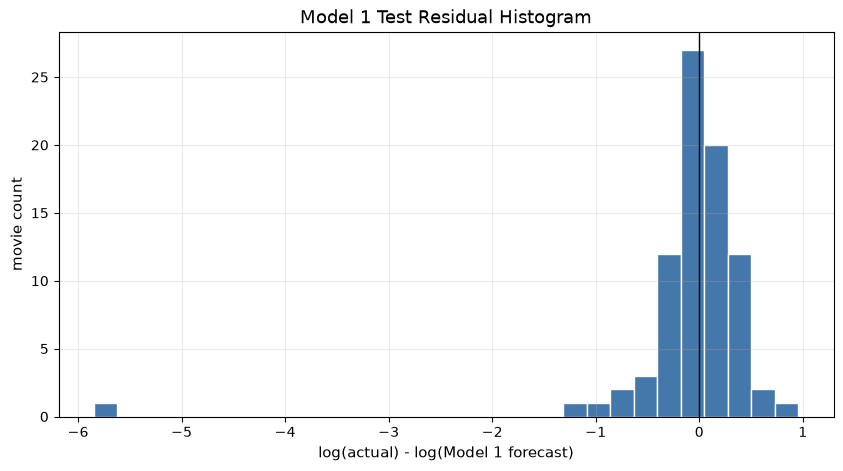

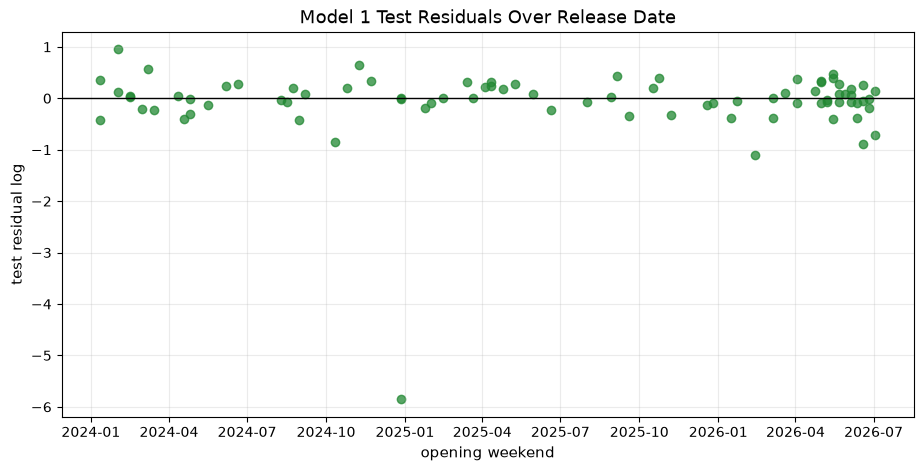

In [293]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(residual_diagnostics["log_rigor_residual_log"], bins=30, color="#4477AA", edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Model 1 Test Residual Histogram")
ax.set_xlabel("log(actual) - log(Model 1 forecast)")
ax.set_ylabel("movie count")
plt.show()

plot_df = residual_diagnostics.sort_values("opening_weekend_start")
fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(plot_df["opening_weekend_start"], plot_df["log_rigor_residual_log"], alpha=0.75, color="#228833")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Model 1 Test Residuals Over Release Date")
ax.set_xlabel("opening weekend")
ax.set_ylabel("test residual log")
plt.show()


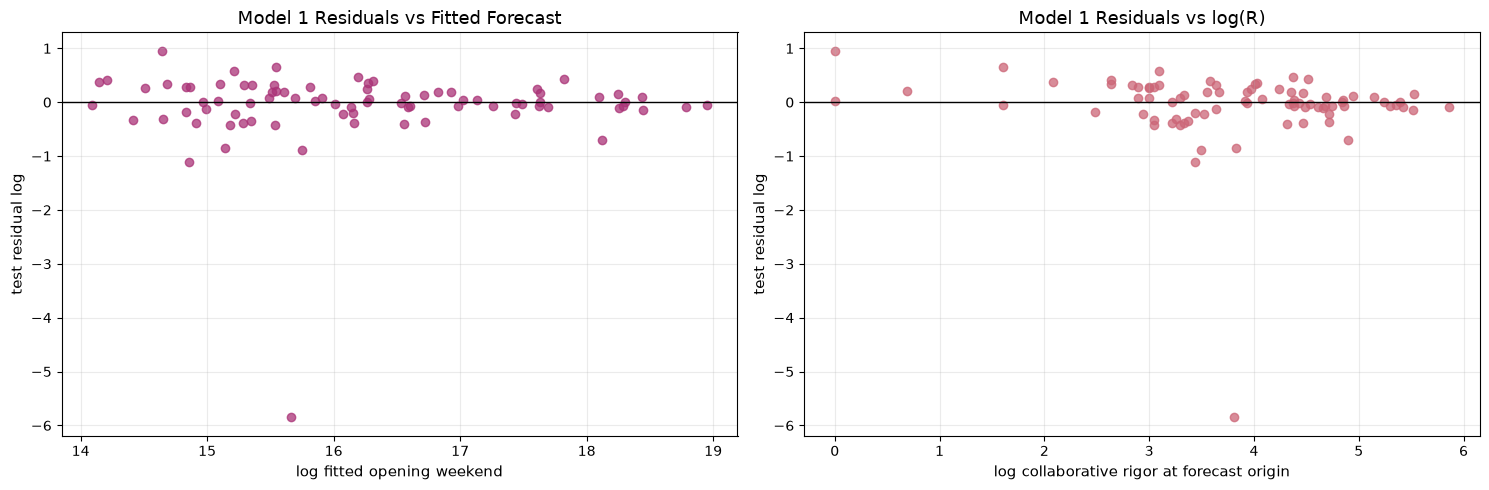

In [294]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(residual_diagnostics["log_rigor_fitted_log"], residual_diagnostics["log_rigor_residual_log"], alpha=0.75, color="#AA3377")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Model 1 Residuals vs Fitted Forecast")
axes[0].set_xlabel("log fitted opening weekend")
axes[0].set_ylabel("test residual log")

axes[1].scatter(residual_diagnostics["wiki_at_origin_log_r"], residual_diagnostics["log_rigor_residual_log"], alpha=0.75, color="#CC6677")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Model 1 Residuals vs log(R)")
axes[1].set_xlabel("log collaborative rigor at forecast origin")
axes[1].set_ylabel("test residual log")
plt.tight_layout()
plt.show()


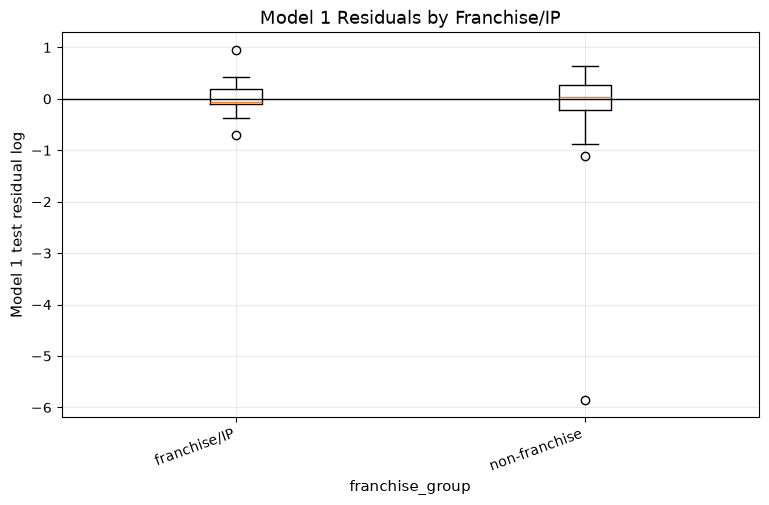

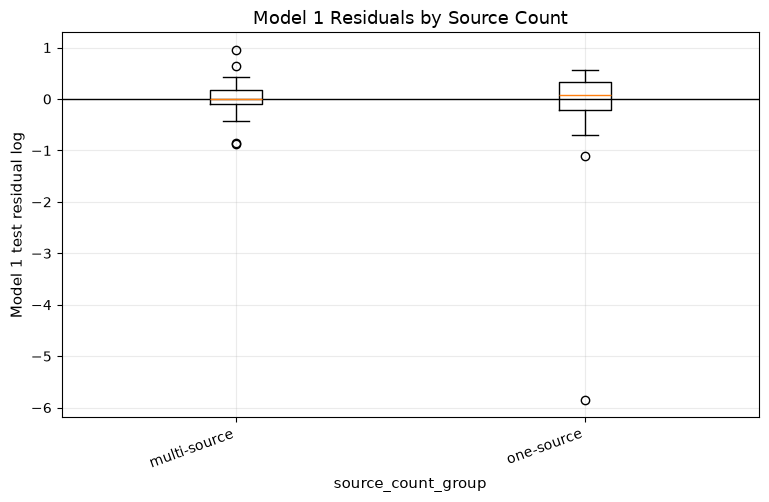

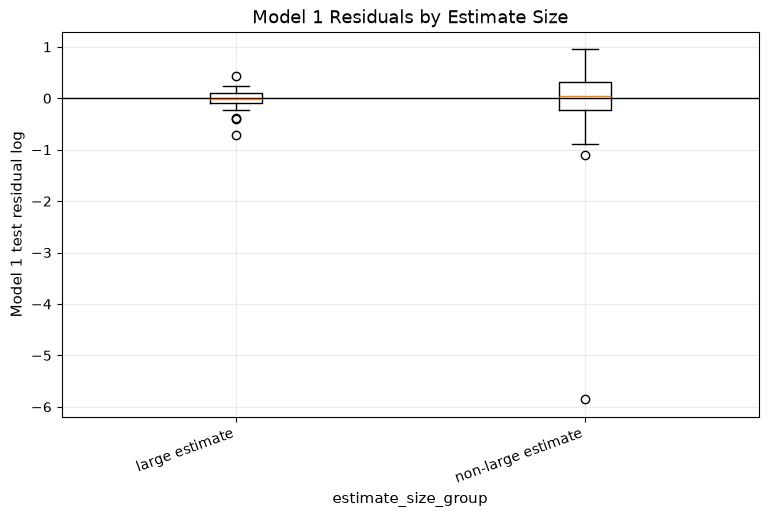

In [295]:
def model1_boxplot_by_group(df, group_col, title):
    plot_df = df.dropna(subset=[group_col, "log_rigor_residual_log"]).copy()
    order = plot_df.groupby(group_col)["log_rigor_residual_log"].median().sort_values().index.tolist()
    data = [plot_df.loc[plot_df[group_col] == group, "log_rigor_residual_log"] for group in order]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.boxplot(data, tick_labels=order, showfliers=True)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel("Model 1 test residual log")
    plt.xticks(rotation=20, ha="right")
    plt.show()

model1_boxplot_by_group(residual_diagnostics, "franchise_group", "Model 1 Residuals by Franchise/IP")
model1_boxplot_by_group(residual_diagnostics, "source_count_group", "Model 1 Residuals by Source Count")
model1_boxplot_by_group(residual_diagnostics, "estimate_size_group", "Model 1 Residuals by Estimate Size")


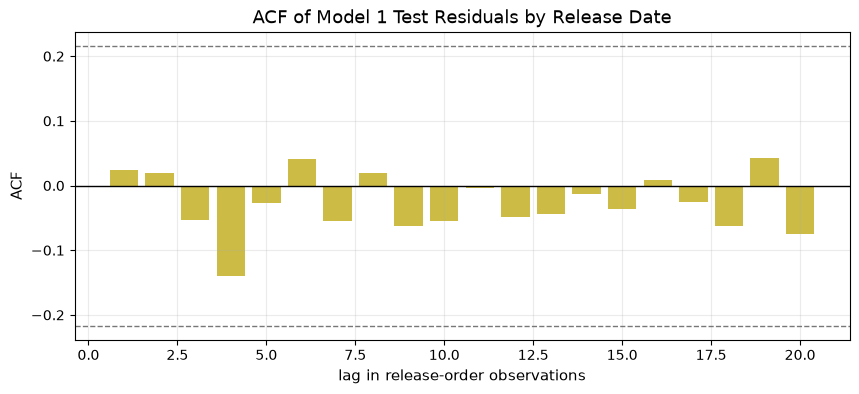

,lag,acf
0,1,0.0233
1,2,0.0192
2,3,-0.0528
3,4,-0.1401
4,5,-0.0267
5,6,0.0415
6,7,-0.0548
7,8,0.0188
8,9,-0.0622
9,10,-0.0554


In [296]:
def acf_values(values, max_lag=20):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    x = x - x.mean()
    denom = np.dot(x, x)
    if len(x) < 3 or denom == 0:
        return pd.DataFrame({"lag": [], "acf": []})
    max_lag = min(max_lag, len(x) - 2)
    return pd.DataFrame(
        {
            "lag": range(1, max_lag + 1),
            "acf": [np.dot(x[:-lag], x[lag:]) / denom for lag in range(1, max_lag + 1)],
        }
    )

acf_plot_df = residual_diagnostics.sort_values("opening_weekend_start")
acf_df = acf_values(acf_plot_df["log_rigor_residual_log"], max_lag=20)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(acf_df["lag"], acf_df["acf"], color="#CCBB44")
ax.axhline(0, color="black", linewidth=1)
if len(acf_plot_df) > 0:
    bound = 1.96 / np.sqrt(len(acf_plot_df))
    ax.axhline(bound, color="#777777", linestyle="--", linewidth=1)
    ax.axhline(-bound, color="#777777", linestyle="--", linewidth=1)
ax.set_title("ACF of Model 1 Test Residuals by Release Date")
ax.set_xlabel("lag in release-order observations")
ax.set_ylabel("ACF")
plt.show()

acf_df


## Rebuild and Compare Prediction Intervals

Do not reuse raw-consensus interval variances for Model 1. For each point forecast, estimate residual standard deviations on that model's training residuals, stratified by franchise status with a global fallback, then compute intervals on the log scale and back-transform.

This section reports both the fixed 2024+ test coverage and rolling-origin coverage with segment breakdowns.


In [297]:
INTERVAL_FORECAST_SPECS = [
    ("raw_consensus", FORECAST_COLUMNS["model_0_raw_consensus"]),
    ("log_rigor", FORECAST_COLUMNS["model_1_log_rigor"]),
]
INTERVAL_LEVELS = {"80": 1.28, "95": 1.96}


def interval_coverage(df, lower_col, upper_col):
    x = df.dropna(subset=[lower_col, upper_col, "actual_opening_weekend_gross_usd"])
    if x.empty:
        return np.nan
    inside = (x["actual_opening_weekend_gross_usd"] >= x[lower_col]) & (
        x["actual_opening_weekend_gross_usd"] <= x[upper_col]
    )
    return inside.mean()


def interval_width_ratio(df, prefix, level, forecast_col):
    lower_col = f"{prefix}_franchise_sd_{level}_lower"
    upper_col = f"{prefix}_franchise_sd_{level}_upper"
    if df.empty:
        return np.nan
    return ((df[upper_col] - df[lower_col]) / df[forecast_col]).mean()


def add_interval_group_columns(train_df, test_df):
    train = train_df.copy()
    test = test_df.copy()
    large_cutoff = train["consensus_estimate_usd"].quantile(0.75)
    for frame in [train, test]:
        frame["franchise_group"] = np.where(frame["is_franchise"].fillna(False), "franchise/IP", "non-franchise")
        frame["source_count_group"] = np.where(
            frame["estimate_source_count"].fillna(0).astype(int) == 1,
            "one-source",
            "multi-source",
        )
        frame["estimate_size_group"] = np.where(
            frame["consensus_estimate_usd"] >= large_cutoff,
            "large estimate",
            "non-large estimate",
        )
    return train, test


def add_franchise_sd_intervals(train_df, test_df, forecast_col, prefix):
    train, test = add_interval_group_columns(train_df, test_df)
    train[f"{prefix}_residual_log"] = (
        np.log(train["actual_opening_weekend_gross_usd"]) - np.log(train[forecast_col])
    )
    global_sigma = train[f"{prefix}_residual_log"].std(ddof=1)
    group_sigma = (
        train.groupby("is_franchise")[f"{prefix}_residual_log"]
        .agg(["count", "std"])
        .reset_index()
    )
    usable_group_sigma = group_sigma.loc[group_sigma["count"] >= MIN_GROUP_N_FOR_GROUP_SIGMA]
    sigma_map = usable_group_sigma.set_index("is_franchise")["std"].to_dict()
    test[f"{prefix}_interval_sigma_log"] = test["is_franchise"].map(sigma_map).fillna(global_sigma)

    for interval_name, z in INTERVAL_LEVELS.items():
        test[f"{prefix}_franchise_sd_{interval_name}_lower"] = np.exp(
            np.log(test[forecast_col]) - z * test[f"{prefix}_interval_sigma_log"]
        )
        test[f"{prefix}_franchise_sd_{interval_name}_upper"] = np.exp(
            np.log(test[forecast_col]) + z * test[f"{prefix}_interval_sigma_log"]
        )
    return test, {
        "point_model": prefix,
        "forecast_col": forecast_col,
        "interval_method": "franchise_sd_on_point_residuals",
        "n_test": len(test),
        "global_sigma_log": global_sigma,
        "usable_group_count": len(usable_group_sigma),
        "coverage_80": interval_coverage(test, f"{prefix}_franchise_sd_80_lower", f"{prefix}_franchise_sd_80_upper"),
        "coverage_95": interval_coverage(test, f"{prefix}_franchise_sd_95_lower", f"{prefix}_franchise_sd_95_upper"),
        "mean_80_width_to_forecast": interval_width_ratio(test, prefix, "80", forecast_col),
        "mean_95_width_to_forecast": interval_width_ratio(test, prefix, "95", forecast_col),
    }


def interval_segments(df):
    return [
        ("all", "all movies", df.index == df.index),
        ("franchise", "franchise/IP", df["franchise_group"] == "franchise/IP"),
        ("franchise", "non-franchise", df["franchise_group"] == "non-franchise"),
        ("source_count", "one-source", df["source_count_group"] == "one-source"),
        ("source_count", "multi-source", df["source_count_group"] == "multi-source"),
        ("estimate_size", "large estimate", df["estimate_size_group"] == "large estimate"),
        ("estimate_size", "non-large estimate", df["estimate_size_group"] == "non-large estimate"),
    ]


def interval_segment_rows(test_df, prefix, forecast_col, fold_name="2024plus_fixed_test"):
    rows = []
    for family, segment, mask in interval_segments(test_df):
        x = test_df.loc[mask].copy()
        rows.append(
            {
                "fold": fold_name,
                "point_model": prefix,
                "segment_family": family,
                "segment": segment,
                "n": len(x),
                "coverage_80": interval_coverage(x, f"{prefix}_franchise_sd_80_lower", f"{prefix}_franchise_sd_80_upper"),
                "coverage_95": interval_coverage(x, f"{prefix}_franchise_sd_95_lower", f"{prefix}_franchise_sd_95_upper"),
                "mean_80_width_to_forecast": interval_width_ratio(x, prefix, "80", forecast_col),
                "mean_95_width_to_forecast": interval_width_ratio(x, prefix, "95", forecast_col),
            }
        )
    return rows


def run_interval_comparison(train_df, test_df, fold_name="2024plus_fixed_test"):
    interval_test = test_df.copy()
    row_list = []
    segment_row_list = []
    for prefix, forecast_col in INTERVAL_FORECAST_SPECS:
        interval_frame, interval_row = add_franchise_sd_intervals(train_df, interval_test, forecast_col, prefix)
        interval_row["fold"] = fold_name
        row_list.append(interval_row)
        segment_row_list.extend(interval_segment_rows(interval_frame, prefix, forecast_col, fold_name=fold_name))
        new_cols = [
            col for col in interval_frame.columns
            if col.startswith(f"{prefix}_") or col in ["franchise_group", "source_count_group", "estimate_size_group"]
        ]
        for col in new_cols:
            interval_test[col] = interval_frame[col]
    return interval_test, row_list, segment_row_list


# Fixed 2024+ interval comparison.
test_intervals, interval_rows, interval_segment_rows_fixed = run_interval_comparison(
    train_forecasts,
    test_forecasts,
)
test_intervals["chosen_forecast_usd"] = test_intervals[chosen_forecast_col]
interval_recheck = pd.DataFrame(interval_rows)
interval_segment_coverage = pd.DataFrame(interval_segment_rows_fixed)

# Rolling-origin interval comparison.
rolling_interval_rows = []
rolling_interval_segment_rows = []
for train_through_year, test_year in rolling_specs:
    train_mask = (
        (modeling["release_year"] <= train_through_year)
        & ~modeling["release_year"].isin(EXCLUDED_RELEASE_YEARS)
    )
    test_mask = modeling["release_year"] == test_year
    fold_train = modeling.loc[train_mask].copy()
    fold_test = modeling.loc[test_mask].copy()
    if len(fold_train) < 10 or fold_test.empty:
        continue
    fold_train_forecasts, fold_test_forecasts, _coef, _surprise = add_fold_forecasts(fold_train, fold_test)
    fold_name = f"train_through_{train_through_year}__test_{test_year}"
    _fold_intervals, fold_rows, fold_segment_rows = run_interval_comparison(
        fold_train_forecasts,
        fold_test_forecasts,
        fold_name=fold_name,
    )
    for row in fold_rows:
        row["train_last_year"] = train_through_year
        row["test_year"] = test_year
    rolling_interval_rows.extend(fold_rows)
    rolling_interval_segment_rows.extend(fold_segment_rows)

rolling_interval_coverage = pd.DataFrame(rolling_interval_rows)
rolling_interval_segment_coverage = pd.DataFrame(rolling_interval_segment_rows)
if not rolling_interval_coverage.empty:
    rolling_interval_summary = (
        rolling_interval_coverage.groupby("point_model")
        .agg(
            folds=("fold", "nunique"),
            mean_coverage_80=("coverage_80", "mean"),
            mean_coverage_95=("coverage_95", "mean"),
            mean_80_width_to_forecast=("mean_80_width_to_forecast", "mean"),
            mean_95_width_to_forecast=("mean_95_width_to_forecast", "mean"),
        )
        .reset_index()
    )
else:
    rolling_interval_summary = pd.DataFrame()

display(interval_recheck)
display(rolling_interval_summary)
rolling_interval_segment_coverage


,point_model,forecast_col,interval_method,n_test,global_sigma_log,usable_group_count,coverage_80,coverage_95,mean_80_width_to_forecast,mean_95_width_to_forecast,fold
0,raw_consensus,model_0_raw_consensus_forecast_usd,franchise_sd_on_point_residuals,82,0.4254,2,0.8293,0.9268,1.0754,1.7579,2024plus_fixed_test
1,log_rigor,model_1_log_rigor_forecast_usd,franchise_sd_on_point_residuals,82,0.3985,2,0.8659,0.9390,1.0097,1.6407,2024plus_fixed_test


,point_model,folds,mean_coverage_80,mean_coverage_95,mean_80_width_to_forecast,mean_95_width_to_forecast
0,log_rigor,4,0.9283,0.9746,1.3380,2.3100
1,raw_consensus,4,0.8877,0.9656,1.3722,2.3744


,fold,point_model,segment_family,segment,n,coverage_80,coverage_95,mean_80_width_to_forecast,mean_95_width_to_forecast
0,train_through_2022__test_2023,raw_consensus,all,all movies,21,0.9524,1.0000,1.1601,1.9089
1,train_through_2022__test_2023,raw_consensus,franchise,franchise/IP,6,1.0000,1.0000,0.7931,1.2552
2,train_through_2022__test_2023,raw_consensus,franchise,non-franchise,15,0.9333,1.0000,1.3069,2.1704
3,train_through_2022__test_2023,raw_consensus,source_count,one-source,7,0.8571,1.0000,1.2335,2.0397
4,train_through_2022__test_2023,raw_consensus,source_count,multi-source,14,1.0000,1.0000,1.1234,1.8436
5,train_through_2022__test_2023,raw_consensus,estimate_size,large estimate,7,1.0000,1.0000,0.9399,1.5167
6,train_through_2022__test_2023,raw_consensus,estimate_size,non-large estimate,14,0.9286,1.0000,1.2702,2.1051
7,train_through_2022__test_2023,log_rigor,all,all movies,21,1.0000,1.0000,1.1206,1.8386
8,train_through_2022__test_2023,log_rigor,franchise,franchise/IP,6,1.0000,1.0000,0.7253,1.1420
9,train_through_2022__test_2023,log_rigor,franchise,non-franchise,15,1.0000,1.0000,1.2787,2.1172


## Late Forecast by Forecast Origin

The fixed-origin model answers the day-before-release question. This section expands the same late-opening setup to a small grid of forecast origins: `-14`, `-7`, `-3`, and `-1` movie-time days. Each row is one movie-origin pair and contains only estimates and Wiki activity available by that origin.


In [298]:
FORECAST_ORIGIN_GRID_DAYS = [-14, -7, -3, -1]

origin_grid = pd.DataFrame({"forecast_origin_day": FORECAST_ORIGIN_GRID_DAYS})
movie_origin_base_cols = [
    "release_run_id",
    "movie_id",
    "title",
    "opening_weekend_start",
    "release_year",
    "actual_opening_weekend_gross_usd",
    "log_actual_opening_weekend",
    "is_franchise",
    "genre",
    "distributor",
    "season_bucket",
]
movie_origin_panel = modeling[[col for col in movie_origin_base_cols if col in modeling.columns]].drop_duplicates("release_run_id").copy()
movie_origin_panel = movie_origin_panel.assign(_cross_key=1).merge(
    origin_grid.assign(_cross_key=1),
    on="_cross_key",
).drop(columns="_cross_key")
movie_origin_panel["forecast_origin_date"] = (
    movie_origin_panel["opening_weekend_start"].dt.normalize()
    + pd.to_timedelta(movie_origin_panel["forecast_origin_day"], unit="D")
)

origin_release_run_ids = sorted(movie_origin_panel["release_run_id"].dropna().astype(int).unique().tolist())
estimate_rows_sql = """
SELECT
    release_run_id,
    estimate_source,
    estimate_date,
    target_start_date,
    forecast_metric,
    estimate_mid_usd
FROM analytics.eda_news_estimates
WHERE release_run_id = ANY(%s)
  AND estimate_mid_usd IS NOT NULL
  AND estimate_mid_usd > 0
"""
origin_estimates = read_db_frame(estimate_rows_sql, (origin_release_run_ids,))
for date_col in ["estimate_date", "target_start_date"]:
    origin_estimates[date_col] = pd.to_datetime(origin_estimates[date_col], errors="coerce")
origin_estimates["estimate_mid_usd"] = pd.to_numeric(origin_estimates["estimate_mid_usd"], errors="coerce")
origin_estimates = origin_estimates.loc[
    origin_estimates["estimate_source"].ne("the_numbers_predictions")
    & origin_estimates["estimate_mid_usd"].gt(0)
].copy()

panel_estimates = movie_origin_panel[[
    "release_run_id",
    "opening_weekend_start",
    "forecast_origin_day",
    "forecast_origin_date",
]].merge(origin_estimates, on="release_run_id", how="left")
forecast_metric = panel_estimates["forecast_metric"].fillna("").astype(str)
panel_estimates = panel_estimates.loc[
    panel_estimates["estimate_mid_usd"].notna()
    & panel_estimates["estimate_date"].notna()
    & (panel_estimates["estimate_date"] <= panel_estimates["forecast_origin_date"])
    & (
        panel_estimates["target_start_date"].isna()
        | (panel_estimates["target_start_date"].dt.normalize() == panel_estimates["opening_weekend_start"].dt.normalize())
        | forecast_metric.str.contains("opening", case=False, na=False)
    )
].copy()

latest_source_estimates = (
    panel_estimates.sort_values(["release_run_id", "forecast_origin_day", "estimate_source", "estimate_date"])
    .groupby(["release_run_id", "forecast_origin_day", "estimate_source"], as_index=False)
    .tail(1)
)
consensus_asof_origin = (
    latest_source_estimates.groupby(["release_run_id", "forecast_origin_day"])
    .agg(
        consensus_estimate_origin_usd=("estimate_mid_usd", "mean"),
        min_estimate_origin_usd=("estimate_mid_usd", "min"),
        max_estimate_origin_usd=("estimate_mid_usd", "max"),
        estimate_source_count_origin=("estimate_source", "nunique"),
        latest_estimate_date_origin=("estimate_date", "max"),
        estimate_sources_origin=("estimate_source", lambda s: ", ".join(sorted(set(s.dropna())))),
    )
    .reset_index()
)

movie_origin_panel = movie_origin_panel.merge(consensus_asof_origin, on=["release_run_id", "forecast_origin_day"], how="left")
movie_origin_panel = movie_origin_panel.loc[movie_origin_panel["consensus_estimate_origin_usd"].gt(0)].copy()
movie_origin_panel["estimate_age_days_origin"] = (
    movie_origin_panel["forecast_origin_date"] - movie_origin_panel["latest_estimate_date_origin"]
).dt.days.clip(lower=0)

rigor_asof_origin = wiki_paper.loc[wiki_paper["forecast_origin_day"].isin(FORECAST_ORIGIN_GRID_DAYS)].copy()
rigor_asof_origin = rigor_asof_origin[[
    "release_run_id",
    "forecast_origin_day",
    "v_cume",
    "e_cume",
    "u_cume",
    "r_cume",
    "v_recent7",
    "e_recent7",
    "u_recent7",
    "r_recent7",
    "log_v_cume",
    "log_e_cume",
    "log_u_cume",
    "log_r_cume",
    "log_r_recent7",
]]
movie_origin_panel = movie_origin_panel.merge(rigor_asof_origin, on=["release_run_id", "forecast_origin_day"], how="inner")
movie_origin_panel["log_consensus_estimate_origin"] = np.log(movie_origin_panel["consensus_estimate_origin_usd"])
movie_origin_panel["residual_log_actual_to_consensus"] = (
    movie_origin_panel["log_actual_opening_weekend"] - movie_origin_panel["log_consensus_estimate_origin"]
)
movie_origin_panel["source_count_group_origin"] = np.where(
    movie_origin_panel["estimate_source_count_origin"].fillna(0).astype(int) == 1,
    "one-source",
    "multi-source",
)
movie_origin_panel["franchise_group"] = np.where(movie_origin_panel["is_franchise"].fillna(False), "franchise/IP", "non-franchise")

movie_origin_summary = (
    movie_origin_panel.groupby("forecast_origin_day")
    .agg(
        rows=("release_run_id", "count"),
        movies=("release_run_id", "nunique"),
        median_consensus_usd=("consensus_estimate_origin_usd", "median"),
        median_source_count=("estimate_source_count_origin", "median"),
        median_estimate_age_days=("estimate_age_days_origin", "median"),
        median_rigor=("r_cume", "median"),
    )
)
movie_origin_summary


,rows,movies,median_consensus_usd,median_source_count,median_estimate_age_days,median_rigor
forecast_origin_day,,,,,,
-14,61,61,"14,000,000.0000",1.0000,0.0000,15.0000
-7,63,63,"12,000,000.0000",1.0000,0.0000,25.0000
-3,65,65,"12,000,000.0000",1.0000,4.0000,36.0000
-1,167,167,"9,600,000.0000",2.0000,0.0000,40.0000


### Rolling Validation by Forecast Origin

Compare raw consensus and the log-rigor adjustment separately at each forecast origin. Model 1 is fit separately by origin inside each rolling fold when enough training rows are available. Accuracy is evaluated on a common origin-fold sample where actuals, raw consensus, and log-rigor forecasts are all available.


In [299]:
ORIGIN_FORECAST_COLS = {
    "raw consensus": "origin_model_0_raw_forecast_usd",
    "log rigor": "origin_model_1_log_rigor_forecast_usd",
}


def fit_origin_log_rigor(train_origin_df):
    model_df = train_origin_df.dropna(subset=["residual_log_actual_to_consensus", "log_r_cume"]).copy()
    if len(model_df) < 10 or model_df["log_r_cume"].nunique() < 2:
        return None
    x = np.column_stack([np.ones(len(model_df)), model_df["log_r_cume"].to_numpy(dtype=float)])
    y = model_df["residual_log_actual_to_consensus"].to_numpy(dtype=float)
    beta, sigma, _ = fit_lstsq(x, y)
    return beta, sigma, len(model_df)


def add_origin_forecasts(train_df, test_df):
    train_out_parts = []
    test_out_parts = []
    coefficient_rows = []
    for origin_day, test_origin in test_df.groupby("forecast_origin_day"):
        train_origin = train_df.loc[train_df["forecast_origin_day"].eq(origin_day)].copy()
        test_origin = test_origin.copy()
        for frame in [train_origin, test_origin]:
            frame["origin_model_0_raw_forecast_usd"] = frame["consensus_estimate_origin_usd"]
            frame["origin_model_0_predicted_residual_log"] = 0.0
        fitted = fit_origin_log_rigor(train_origin)
        if fitted is None:
            for frame in [train_origin, test_origin]:
                frame["origin_model_1_log_rigor_forecast_usd"] = np.nan
                frame["origin_model_1_predicted_residual_log"] = np.nan
            coefficient_rows.append({"forecast_origin_day": origin_day, "n_train": len(train_origin), "intercept_alpha": np.nan, "log_r_beta": np.nan, "residual_sigma_log": np.nan})
        else:
            beta, sigma, n_train = fitted
            for frame in [train_origin, test_origin]:
                predicted_residual = beta[0] + beta[1] * frame["log_r_cume"].to_numpy(dtype=float)
                frame["origin_model_1_predicted_residual_log"] = predicted_residual
                frame["origin_model_1_log_rigor_forecast_usd"] = frame["consensus_estimate_origin_usd"] * np.exp(predicted_residual)
            coefficient_rows.append({"forecast_origin_day": origin_day, "n_train": n_train, "intercept_alpha": beta[0], "log_r_beta": beta[1], "residual_sigma_log": sigma})
        train_out_parts.append(train_origin)
        test_out_parts.append(test_origin)
    return pd.concat(train_out_parts, ignore_index=True), pd.concat(test_out_parts, ignore_index=True), pd.DataFrame(coefficient_rows)


def common_origin_evaluation_sample(df):
    required_cols = ["actual_opening_weekend_gross_usd", *ORIGIN_FORECAST_COLS.values()]
    x = df.replace([np.inf, -np.inf], np.nan).dropna(subset=required_cols).copy()
    positive_mask = x["actual_opening_weekend_gross_usd"].gt(0)
    for forecast_col in ORIGIN_FORECAST_COLS.values():
        positive_mask &= x[forecast_col].gt(0)
    return x.loc[positive_mask].copy()


def evaluate_origin_forecast(df, forecast_col, model_label):
    x = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[forecast_col, "actual_opening_weekend_gross_usd"]).copy()
    x = x.loc[x[forecast_col].gt(0) & x["actual_opening_weekend_gross_usd"].gt(0)].copy()
    if x.empty:
        return {"model": model_label, "n": 0, "ME_log": np.nan, "MAE_log": np.nan, "RMSE_log": np.nan, "MdAPE": np.nan}
    e = np.log(x["actual_opening_weekend_gross_usd"]) - np.log(x[forecast_col])
    return {"model": model_label, "n": len(x), "ME_log": e.mean(), "MAE_log": e.abs().mean(), "RMSE_log": np.sqrt(np.mean(e**2)), "MdAPE": np.median(np.abs(x["actual_opening_weekend_gross_usd"] / x[forecast_col] - 1))}


origin_rolling_rows = []
origin_coefficient_rows = []
origin_fold_frames = []
origin_common_fold_frames = []
for train_through_year, test_year in rolling_specs:
    train_mask = (movie_origin_panel["release_year"] <= train_through_year) & ~movie_origin_panel["release_year"].isin(EXCLUDED_RELEASE_YEARS)
    test_mask = movie_origin_panel["release_year"].eq(test_year)
    fold_train = movie_origin_panel.loc[train_mask].copy()
    fold_test = movie_origin_panel.loc[test_mask].copy()
    if len(fold_train) < 10 or fold_test.empty:
        continue
    fold_train_forecasts, fold_test_forecasts, fold_coefficients = add_origin_forecasts(fold_train, fold_test)
    fold_name = f"train_through_{train_through_year}__test_{test_year}"
    fold_test_forecasts["fold"] = fold_name
    fold_test_forecasts["train_last_year"] = train_through_year
    fold_test_forecasts["test_year"] = test_year
    origin_fold_frames.append(fold_test_forecasts)
    fold_coefficients["fold"] = fold_name
    fold_coefficients["train_last_year"] = train_through_year
    fold_coefficients["test_year"] = test_year
    origin_coefficient_rows.append(fold_coefficients)
    for origin_day, origin_test in fold_test_forecasts.groupby("forecast_origin_day"):
        common_origin_test = common_origin_evaluation_sample(origin_test)
        if common_origin_test.empty:
            continue
        common_origin_test["common_origin_sample"] = True
        origin_common_fold_frames.append(common_origin_test)
        for label, forecast_col in ORIGIN_FORECAST_COLS.items():
            row = evaluate_origin_forecast(common_origin_test, forecast_col, label)
            row.update({
                "fold": fold_name,
                "train_last_year": train_through_year,
                "test_year": test_year,
                "forecast_origin_day": origin_day,
                "common_sample": True,
                "n_common": len(common_origin_test),
            })
            origin_rolling_rows.append(row)

origin_rolling_predictions = pd.concat(origin_fold_frames, ignore_index=True) if origin_fold_frames else pd.DataFrame()
origin_common_evaluation_predictions = pd.concat(origin_common_fold_frames, ignore_index=True) if origin_common_fold_frames else pd.DataFrame()
origin_coefficients = pd.concat(origin_coefficient_rows, ignore_index=True) if origin_coefficient_rows else pd.DataFrame()
origin_rolling_metrics = pd.DataFrame(origin_rolling_rows)
origin_metric_summary_by_origin = (
    origin_rolling_metrics.groupby(["forecast_origin_day", "model"])
    .agg(
        folds=("fold", "nunique"),
        mean_n=("n", "mean"),
        mean_ME_log=("ME_log", "mean"),
        mean_MAE_log=("MAE_log", "mean"),
        mean_RMSE_log=("RMSE_log", "mean"),
        mean_MdAPE=("MdAPE", "mean"),
    )
    .reset_index()
    .sort_values(["forecast_origin_day", "model"])
)
origin_metric_summary_by_origin


,forecast_origin_day,model,folds,mean_n,mean_ME_log,mean_MAE_log,mean_RMSE_log,mean_MdAPE
0,-14,log rigor,2,24.5000,0.2954,0.4289,0.5645,0.3793
1,-14,raw consensus,2,24.5000,-0.1677,0.3928,0.4996,0.2944
2,-7,log rigor,2,25.0000,0.3971,0.5484,0.6303,0.7102
3,-7,raw consensus,2,25.0000,-0.1228,0.3438,0.4377,0.3001
4,-3,log rigor,2,25.0000,0.3275,0.4635,0.5481,0.5219
5,-3,raw consensus,2,25.0000,-0.1238,0.3428,0.4376,0.3001
6,-1,log rigor,4,25.7500,0.0130,0.2873,0.5139,0.2189
7,-1,raw consensus,4,25.7500,-0.1842,0.3020,0.5401,0.1868


### Interval Coverage by Forecast Origin

Intervals are computed on the log scale and back-transformed. Residual standard deviations are fit separately by forecast origin and point model, with franchise-status stratification when group cells are large enough. Coverage is evaluated on the same common origin-fold samples used for point accuracy.


In [300]:
def add_origin_intervals(train_df, test_df, forecast_col, prefix):
    train = train_df.copy()
    test = common_origin_evaluation_sample(test_df)
    large_cutoff = train["consensus_estimate_origin_usd"].quantile(0.75)
    for frame in (train, test):
        frame["franchise_group"] = np.where(frame["is_franchise"].fillna(False), "franchise/IP", "non-franchise")
        frame["source_count_group"] = np.where(frame["estimate_source_count_origin"].fillna(0).astype(int) == 1, "one-source", "multi-source")
        frame["estimate_size_group"] = np.where(frame["consensus_estimate_origin_usd"] >= large_cutoff, "large-estimate", "smaller-estimate")
    rows = []
    segment_rows = []
    for origin_day, test_origin in test.groupby("forecast_origin_day"):
        train_origin = train.loc[train["forecast_origin_day"].eq(origin_day)].replace([np.inf, -np.inf], np.nan).dropna(subset=[forecast_col, "actual_opening_weekend_gross_usd"]).copy()
        test_origin = test_origin.copy()
        train_origin = train_origin.loc[train_origin[forecast_col].gt(0) & train_origin["actual_opening_weekend_gross_usd"].gt(0)].copy()
        train_origin[f"{prefix}_origin_residual_log"] = np.log(train_origin["actual_opening_weekend_gross_usd"]) - np.log(train_origin[forecast_col])
        global_sigma = train_origin[f"{prefix}_origin_residual_log"].std(ddof=1)
        group_sigma = train_origin.groupby("is_franchise")[f"{prefix}_origin_residual_log"].agg(["count", "std"]).reset_index()
        usable_group_sigma = group_sigma.loc[group_sigma["count"] >= MIN_GROUP_N_FOR_GROUP_SIGMA]
        sigma_map = usable_group_sigma.set_index("is_franchise")["std"].to_dict()
        test_origin[f"{prefix}_origin_interval_sigma_log"] = test_origin["is_franchise"].map(sigma_map).fillna(global_sigma)
        for level, z in INTERVAL_LEVELS.items():
            test_origin[f"{prefix}_origin_{level}_lower"] = np.exp(np.log(test_origin[forecast_col]) - z * test_origin[f"{prefix}_origin_interval_sigma_log"])
            test_origin[f"{prefix}_origin_{level}_upper"] = np.exp(np.log(test_origin[forecast_col]) + z * test_origin[f"{prefix}_origin_interval_sigma_log"])
        rows.append({
            "point_model": prefix,
            "forecast_origin_day": origin_day,
            "n_test": len(test_origin),
            "global_sigma_log": global_sigma,
            "usable_group_count": len(usable_group_sigma),
            "coverage_80": interval_coverage(test_origin, f"{prefix}_origin_80_lower", f"{prefix}_origin_80_upper"),
            "coverage_95": interval_coverage(test_origin, f"{prefix}_origin_95_lower", f"{prefix}_origin_95_upper"),
            "mean_80_width_to_forecast": ((test_origin[f"{prefix}_origin_80_upper"] - test_origin[f"{prefix}_origin_80_lower"]) / test_origin[forecast_col]).mean(),
            "mean_95_width_to_forecast": ((test_origin[f"{prefix}_origin_95_upper"] - test_origin[f"{prefix}_origin_95_lower"]) / test_origin[forecast_col]).mean(),
            "common_sample": True,
        })
        for family, segment, mask in interval_segments(test_origin):
            x = test_origin.loc[mask].copy()
            segment_rows.append({
                "point_model": prefix,
                "forecast_origin_day": origin_day,
                "segment_family": family,
                "segment": segment,
                "n": len(x),
                "coverage_80": interval_coverage(x, f"{prefix}_origin_80_lower", f"{prefix}_origin_80_upper"),
                "coverage_95": interval_coverage(x, f"{prefix}_origin_95_lower", f"{prefix}_origin_95_upper"),
                "mean_80_width_to_forecast": ((x[f"{prefix}_origin_80_upper"] - x[f"{prefix}_origin_80_lower"]) / x[forecast_col]).mean() if len(x) else np.nan,
                "mean_95_width_to_forecast": ((x[f"{prefix}_origin_95_upper"] - x[f"{prefix}_origin_95_lower"]) / x[forecast_col]).mean() if len(x) else np.nan,
                "common_sample": True,
            })
    return pd.DataFrame(rows), pd.DataFrame(segment_rows)


origin_interval_rows = []
origin_interval_segment_rows = []
for train_through_year, test_year in rolling_specs:
    fold_name = f"train_through_{train_through_year}__test_{test_year}"
    train_mask = (movie_origin_panel["release_year"] <= train_through_year) & ~movie_origin_panel["release_year"].isin(EXCLUDED_RELEASE_YEARS)
    test_mask = movie_origin_panel["release_year"].eq(test_year)
    fold_train = movie_origin_panel.loc[train_mask].copy()
    fold_test = movie_origin_panel.loc[test_mask].copy()
    if len(fold_train) < 10 or fold_test.empty:
        continue
    fold_train_forecasts, fold_test_forecasts, _fold_coefficients = add_origin_forecasts(fold_train, fold_test)
    fold_test_common = common_origin_evaluation_sample(fold_test_forecasts)
    if fold_test_common.empty:
        continue
    for prefix, forecast_col in [("raw_consensus", "origin_model_0_raw_forecast_usd"), ("log_rigor", "origin_model_1_log_rigor_forecast_usd")]:
        fold_interval, fold_segment_interval = add_origin_intervals(fold_train_forecasts, fold_test_common, forecast_col, prefix)
        fold_interval["fold"] = fold_name
        fold_interval["train_last_year"] = train_through_year
        fold_interval["test_year"] = test_year
        fold_segment_interval["fold"] = fold_name
        fold_segment_interval["train_last_year"] = train_through_year
        fold_segment_interval["test_year"] = test_year
        origin_interval_rows.append(fold_interval)
        origin_interval_segment_rows.append(fold_segment_interval)

origin_interval_coverage = pd.concat(origin_interval_rows, ignore_index=True) if origin_interval_rows else pd.DataFrame()
origin_interval_segment_coverage = pd.concat(origin_interval_segment_rows, ignore_index=True) if origin_interval_segment_rows else pd.DataFrame()
origin_interval_summary_by_origin = (
    origin_interval_coverage.groupby(["forecast_origin_day", "point_model"])
    .agg(
        folds=("fold", "nunique"),
        mean_n_test=("n_test", "mean"),
        mean_coverage_80=("coverage_80", "mean"),
        mean_coverage_95=("coverage_95", "mean"),
        mean_80_width_to_forecast=("mean_80_width_to_forecast", "mean"),
        mean_95_width_to_forecast=("mean_95_width_to_forecast", "mean"),
        mean_sigma_log=("global_sigma_log", "mean"),
    )
    .reset_index()
    .sort_values(["forecast_origin_day", "point_model"])
)
origin_interval_summary_by_origin


,forecast_origin_day,point_model,folds,mean_n_test,mean_coverage_80,mean_coverage_95,mean_80_width_to_forecast,mean_95_width_to_forecast,mean_sigma_log
0,-14,log_rigor,2,24.5000,1.0000,1.0000,6.0396,17.5616,1.3776
1,-14,raw_consensus,2,24.5000,0.9677,1.0000,6.1795,18.3001,1.4030
2,-7,log_rigor,2,25.0000,0.9219,0.9844,6.0227,17.5816,1.3780
3,-7,raw_consensus,2,25.0000,0.9375,0.9844,6.0936,17.9035,1.3844
4,-3,log_rigor,2,25.0000,0.9844,0.9844,6.1606,18.4577,1.3164
5,-3,raw_consensus,2,25.0000,0.9375,0.9844,6.1560,18.4668,1.3174
6,-1,log_rigor,4,25.7500,0.9207,0.9627,1.3387,2.3112,0.5318
7,-1,raw_consensus,4,25.7500,0.8758,0.9656,1.3728,2.3755,0.5479


### Common-Sample Origin Performance Curve

This table and plot join accuracy, interval coverage, interval width, and residual sigma by forecast origin. The comparison is now row-aligned within each origin-fold, so differences reflect model behavior rather than sample availability.


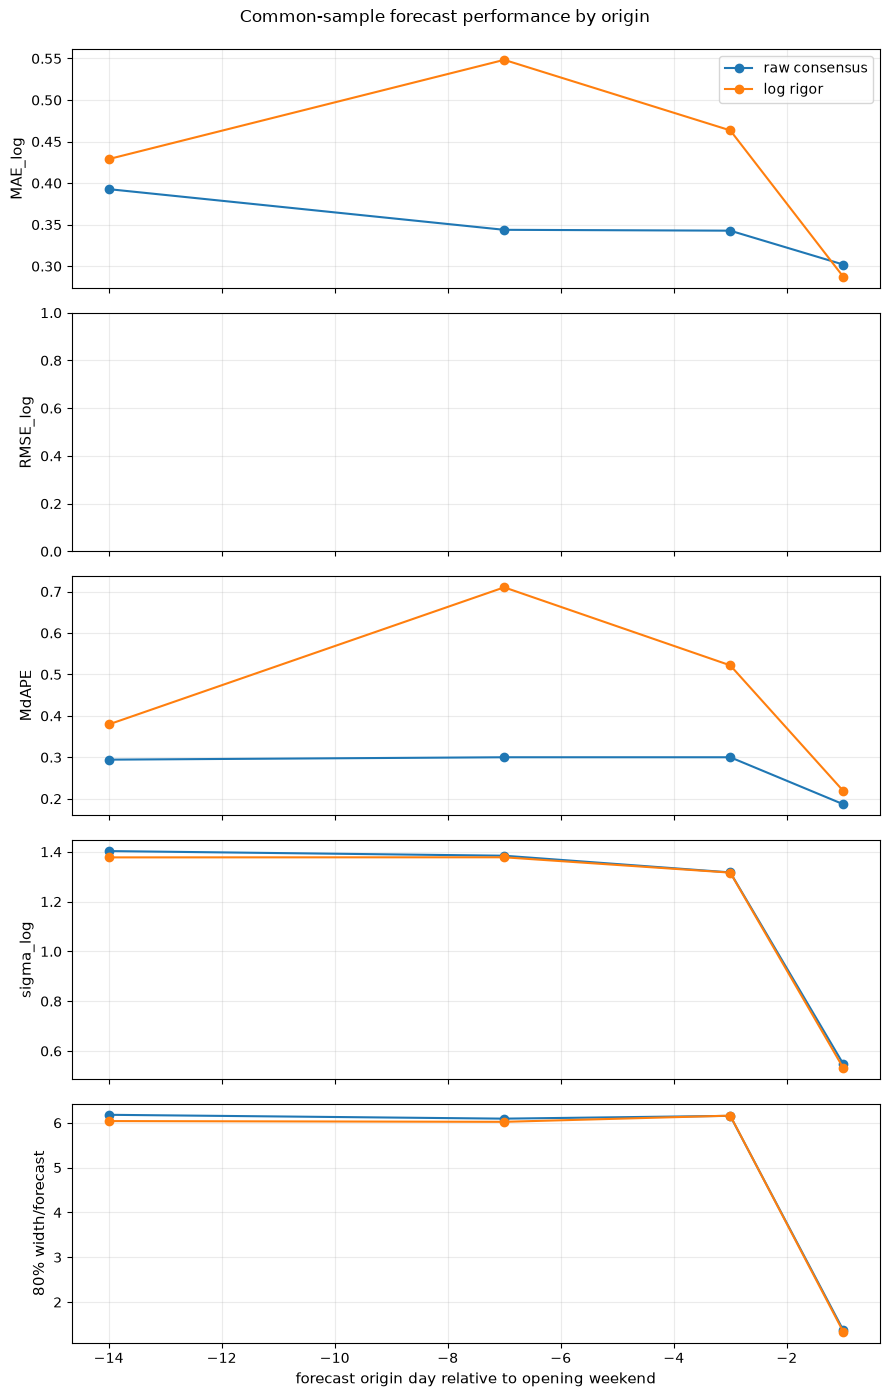

,forecast_origin_day,mean_n_raw consensus,mean_n_log rigor,mean_MAE_log_raw consensus,mean_MAE_log_log rigor,mean_RMSE_log_raw consensus,mean_RMSE_log_log rigor,mean_MdAPE_raw consensus,mean_MdAPE_log rigor,mean_sigma_log_raw_consensus,...,mean_95_width_to_forecast_log_rigor,mean_coverage_80_raw_consensus,mean_coverage_80_log_rigor,mean_coverage_95_raw_consensus,mean_coverage_95_log_rigor,MAE_log_improvement_log_rigor,RMSE_log_improvement_log_rigor,MdAPE_improvement_log_rigor,common_sample_n_matches,origin_decision
0,-14,24.5000,24.5000,0.3928,0.4289,0.4996,0.5645,0.2944,0.3793,1.4030,...,17.5616,0.9677,1.0000,1.0000,1.0000,-0.0361,-0.0649,-0.0849,True,raw consensus default / exploratory
1,-7,25.0000,25.0000,0.3438,0.5484,0.4377,0.6303,0.3001,0.7102,1.3844,...,17.5816,0.9375,0.9219,0.9844,0.9844,-0.2046,-0.1926,-0.4101,True,raw consensus default / exploratory
2,-3,25.0000,25.0000,0.3428,0.4635,0.4376,0.5481,0.3001,0.5219,1.3174,...,18.4577,0.9375,0.9844,0.9844,0.9844,-0.1207,-0.1106,-0.2218,True,raw consensus default / exploratory
3,-1,25.7500,25.7500,0.3020,0.2873,0.5401,0.5139,0.1868,0.2189,0.5479,...,2.3112,0.8758,0.9207,0.9656,0.9627,0.0147,0.0262,-0.0321,True,use log-rigor operationally


In [301]:
origin_accuracy_wide = origin_metric_summary_by_origin.pivot(
    index="forecast_origin_day",
    columns="model",
    values=["mean_n", "mean_ME_log", "mean_MAE_log", "mean_RMSE_log", "mean_MdAPE"],
)
origin_accuracy_wide.columns = [f"{metric}_{model}" for metric, model in origin_accuracy_wide.columns]
origin_accuracy_wide = origin_accuracy_wide.reset_index()

origin_interval_wide = origin_interval_summary_by_origin.pivot(
    index="forecast_origin_day",
    columns="point_model",
    values=["mean_n_test", "mean_coverage_80", "mean_coverage_95", "mean_80_width_to_forecast", "mean_95_width_to_forecast", "mean_sigma_log"],
)
origin_interval_wide.columns = [f"{metric}_{model}" for metric, model in origin_interval_wide.columns]
origin_interval_wide = origin_interval_wide.reset_index()

late_forecast_by_origin_summary = origin_accuracy_wide.merge(origin_interval_wide, on="forecast_origin_day", how="outer").sort_values("forecast_origin_day")
if {"mean_MAE_log_raw consensus", "mean_MAE_log_log rigor"}.issubset(late_forecast_by_origin_summary.columns):
    late_forecast_by_origin_summary["MAE_log_improvement_log_rigor"] = late_forecast_by_origin_summary["mean_MAE_log_raw consensus"] - late_forecast_by_origin_summary["mean_MAE_log_log rigor"]
if {"mean_RMSE_log_raw consensus", "mean_RMSE_log_log rigor"}.issubset(late_forecast_by_origin_summary.columns):
    late_forecast_by_origin_summary["RMSE_log_improvement_log_rigor"] = late_forecast_by_origin_summary["mean_RMSE_log_raw consensus"] - late_forecast_by_origin_summary["mean_RMSE_log_log rigor"]
if {"mean_MdAPE_raw consensus", "mean_MdAPE_log rigor"}.issubset(late_forecast_by_origin_summary.columns):
    late_forecast_by_origin_summary["MdAPE_improvement_log_rigor"] = late_forecast_by_origin_summary["mean_MdAPE_raw consensus"] - late_forecast_by_origin_summary["mean_MdAPE_log rigor"]
if {"mean_n_raw consensus", "mean_n_log rigor"}.issubset(late_forecast_by_origin_summary.columns):
    late_forecast_by_origin_summary["common_sample_n_matches"] = np.isclose(
        late_forecast_by_origin_summary["mean_n_raw consensus"],
        late_forecast_by_origin_summary["mean_n_log rigor"],
    )


def classify_origin_use(row):
    improves_mae = row.get("MAE_log_improvement_log_rigor", np.nan) > 0
    improves_rmse = row.get("RMSE_log_improvement_log_rigor", np.nan) > 0
    improves_mdape = row.get("MdAPE_improvement_log_rigor", np.nan) > 0
    if row["forecast_origin_day"] == -1 and improves_mae and improves_rmse:
        return "use log-rigor operationally"
    if improves_mae and improves_rmse and improves_mdape:
        return "candidate log-rigor origin"
    if improves_rmse and not improves_mae:
        return "raw consensus default; log-rigor risk flag only"
    return "raw consensus default / exploratory"


late_forecast_by_origin_summary["origin_decision"] = late_forecast_by_origin_summary.apply(classify_origin_use, axis=1)

origin_curve_cols = [
    "forecast_origin_day",
    "mean_n_raw consensus",
    "mean_n_log rigor",
    "mean_MAE_log_raw consensus",
    "mean_MAE_log_log rigor",
    "mean_RMSE_log_raw consensus",
    "mean_RMSE_log_log rigor",
    "mean_MdAPE_raw consensus",
    "mean_MdAPE_log rigor",
    "mean_sigma_log_raw_consensus",
    "mean_sigma_log_log_rigor",
    "mean_80_width_to_forecast_raw_consensus",
    "mean_80_width_to_forecast_log_rigor",
    "mean_95_width_to_forecast_raw_consensus",
    "mean_95_width_to_forecast_log_rigor",
    "mean_coverage_80_raw_consensus",
    "mean_coverage_80_log_rigor",
    "mean_coverage_95_raw_consensus",
    "mean_coverage_95_log_rigor",
    "MAE_log_improvement_log_rigor",
    "RMSE_log_improvement_log_rigor",
    "MdAPE_improvement_log_rigor",
    "common_sample_n_matches",
    "origin_decision",
]
origin_performance_curve = late_forecast_by_origin_summary[[col for col in origin_curve_cols if col in late_forecast_by_origin_summary.columns]].copy()

plot_metrics = [
    ("mean_MAE_log", "MAE_log"),
    ("mean_RMSE_log", "RMSE_log"),
    ("mean_MdAPE", "MdAPE"),
    ("mean_sigma_log", "sigma_log"),
    ("mean_80_width_to_forecast", "80% width/forecast"),
]
fig, axes = plt.subplots(len(plot_metrics), 1, figsize=(9, 14), sharex=True)
for ax, (metric_prefix, label) in zip(axes, plot_metrics):
    raw_col = f"{metric_prefix}_raw consensus" if metric_prefix.startswith("mean_M") else f"{metric_prefix}_raw_consensus"
    wiki_col = f"{metric_prefix}_log rigor" if metric_prefix.startswith("mean_M") else f"{metric_prefix}_log_rigor"
    if raw_col in late_forecast_by_origin_summary.columns:
        ax.plot(late_forecast_by_origin_summary["forecast_origin_day"], late_forecast_by_origin_summary[raw_col], marker="o", label="raw consensus")
    if wiki_col in late_forecast_by_origin_summary.columns:
        ax.plot(late_forecast_by_origin_summary["forecast_origin_day"], late_forecast_by_origin_summary[wiki_col], marker="o", label="log rigor")
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel("forecast origin day relative to opening weekend")
axes[0].legend(loc="best")
fig.suptitle("Common-sample forecast performance by origin", y=0.995)
fig.tight_layout()
plt.show()

origin_performance_curve


## Chosen Origin Policy Residual Diagnostics

Residual diagnostics now use the selected policy by forecast origin: raw consensus remains the default for exploratory earlier origins, while the day-before origin uses the log-rigor adjustment. Residuals are computed on the same common-sample rolling predictions used for origin-level model selection.


In [302]:
origin_specific_policy_table = pd.DataFrame(
    [
        {"forecast_origin_day": -14, "chosen_origin_policy_model": "raw_consensus", "chosen_origin_policy_label": "raw consensus"},
        {"forecast_origin_day": -7, "chosen_origin_policy_model": "raw_consensus", "chosen_origin_policy_label": "raw consensus"},
        {"forecast_origin_day": -3, "chosen_origin_policy_model": "raw_consensus", "chosen_origin_policy_label": "raw consensus"},
        {"forecast_origin_day": -1, "chosen_origin_policy_model": "log_rigor", "chosen_origin_policy_label": "log-rigor adjustment"},
    ]
)
origin_policy_map = origin_specific_policy_table.set_index("forecast_origin_day")["chosen_origin_policy_model"].to_dict()

origin_policy_residual_diagnostics = origin_common_evaluation_predictions.copy()
origin_policy_residual_diagnostics["chosen_origin_policy_model"] = origin_policy_residual_diagnostics["forecast_origin_day"].map(origin_policy_map)
origin_policy_residual_diagnostics["chosen_origin_forecast_usd"] = np.where(
    origin_policy_residual_diagnostics["chosen_origin_policy_model"].eq("log_rigor"),
    origin_policy_residual_diagnostics["origin_model_1_log_rigor_forecast_usd"],
    origin_policy_residual_diagnostics["origin_model_0_raw_forecast_usd"],
)
origin_policy_residual_diagnostics["chosen_origin_fitted_log"] = np.log(origin_policy_residual_diagnostics["chosen_origin_forecast_usd"])
origin_policy_residual_diagnostics["actual_log"] = np.log(origin_policy_residual_diagnostics["actual_opening_weekend_gross_usd"])
origin_policy_residual_diagnostics["chosen_origin_residual_log"] = (
    origin_policy_residual_diagnostics["actual_log"] - origin_policy_residual_diagnostics["chosen_origin_fitted_log"]
)
origin_policy_residual_diagnostics["chosen_origin_abs_residual_log"] = origin_policy_residual_diagnostics["chosen_origin_residual_log"].abs()
origin_policy_residual_diagnostics["chosen_origin_ape"] = (
    origin_policy_residual_diagnostics["actual_opening_weekend_gross_usd"] / origin_policy_residual_diagnostics["chosen_origin_forecast_usd"] - 1
).abs()
origin_policy_residual_diagnostics["source_count_group"] = np.where(
    origin_policy_residual_diagnostics["estimate_source_count_origin"].fillna(0).astype(int).eq(1),
    "one-source",
    "multi-source",
)
origin_policy_residual_diagnostics["franchise_group"] = np.where(
    origin_policy_residual_diagnostics["is_franchise"].fillna(False),
    "franchise/IP",
    "non-franchise",
)
origin_policy_size_cutoffs = origin_policy_residual_diagnostics.groupby("forecast_origin_day")["consensus_estimate_origin_usd"].transform(
    lambda s: s.quantile(0.75)
)
origin_policy_residual_diagnostics["estimate_size_group"] = np.where(
    origin_policy_residual_diagnostics["consensus_estimate_origin_usd"] >= origin_policy_size_cutoffs,
    "large-estimate",
    "smaller-estimate",
)
origin_policy_residual_diagnostics = origin_policy_residual_diagnostics.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["chosen_origin_forecast_usd", "chosen_origin_residual_log", "opening_weekend_start"]
).copy()

origin_policy_residual_summary = (
    origin_policy_residual_diagnostics.groupby(["forecast_origin_day", "chosen_origin_policy_model"])
    .agg(
        n=("release_run_id", "count"),
        ME_log=("chosen_origin_residual_log", "mean"),
        MAE_log=("chosen_origin_abs_residual_log", "mean"),
        RMSE_log=("chosen_origin_residual_log", lambda s: np.sqrt(np.mean(s**2))),
        MdAPE=("chosen_origin_ape", "median"),
        residual_sd_log=("chosen_origin_residual_log", lambda s: s.std(ddof=1)),
        median_fitted_forecast_usd=("chosen_origin_forecast_usd", "median"),
    )
    .reset_index()
    .sort_values("forecast_origin_day")
)

origin_policy_residual_group_rows = []
for group_col, family in [
    ("franchise_group", "franchise"),
    ("estimate_size_group", "estimate_size"),
    ("source_count_group", "source_count"),
]:
    grouped = (
        origin_policy_residual_diagnostics.groupby(["forecast_origin_day", group_col])
        .agg(
            n=("release_run_id", "count"),
            ME_log=("chosen_origin_residual_log", "mean"),
            MAE_log=("chosen_origin_abs_residual_log", "mean"),
            RMSE_log=("chosen_origin_residual_log", lambda s: np.sqrt(np.mean(s**2))),
            residual_sd_log=("chosen_origin_residual_log", lambda s: s.std(ddof=1)),
        )
        .reset_index()
        .rename(columns={group_col: "segment"})
    )
    grouped["segment_family"] = family
    origin_policy_residual_group_rows.append(grouped)
origin_policy_residual_group_summary = pd.concat(origin_policy_residual_group_rows, ignore_index=True)

origin_policy_residual_summary


,forecast_origin_day,chosen_origin_policy_model,n,ME_log,MAE_log,RMSE_log,MdAPE,residual_sd_log,median_fitted_forecast_usd
0,-14,raw_consensus,49,-0.1727,0.3931,0.5028,0.3000,0.4771,"16,750,000.0000"
1,-7,raw_consensus,50,-0.1294,0.3506,0.4529,0.3027,0.4384,"13,250,000.0000"
2,-3,raw_consensus,50,-0.1307,0.3493,0.4527,0.3027,0.4378,"13,250,000.0000"
3,-1,log_rigor,103,-0.0015,0.2950,0.6599,0.2193,0.6631,"9,446,772.7088"


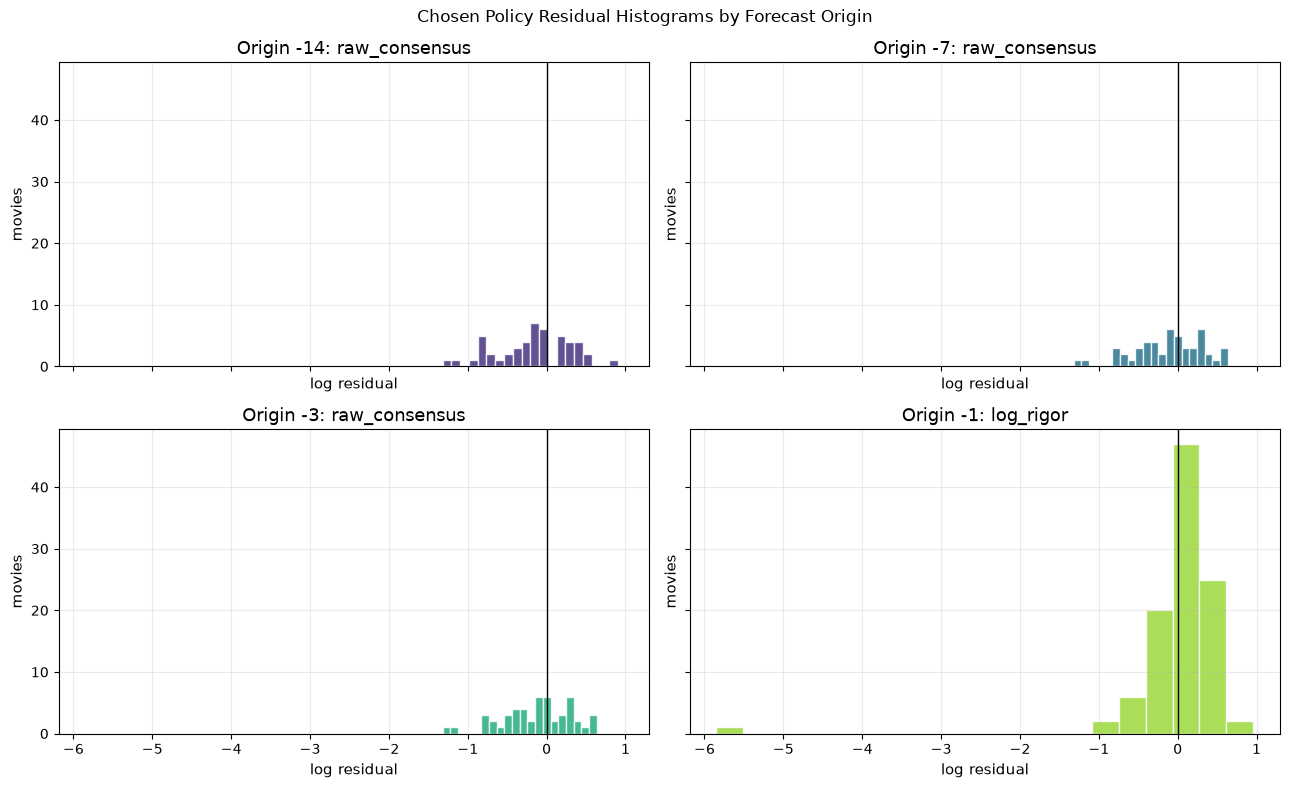

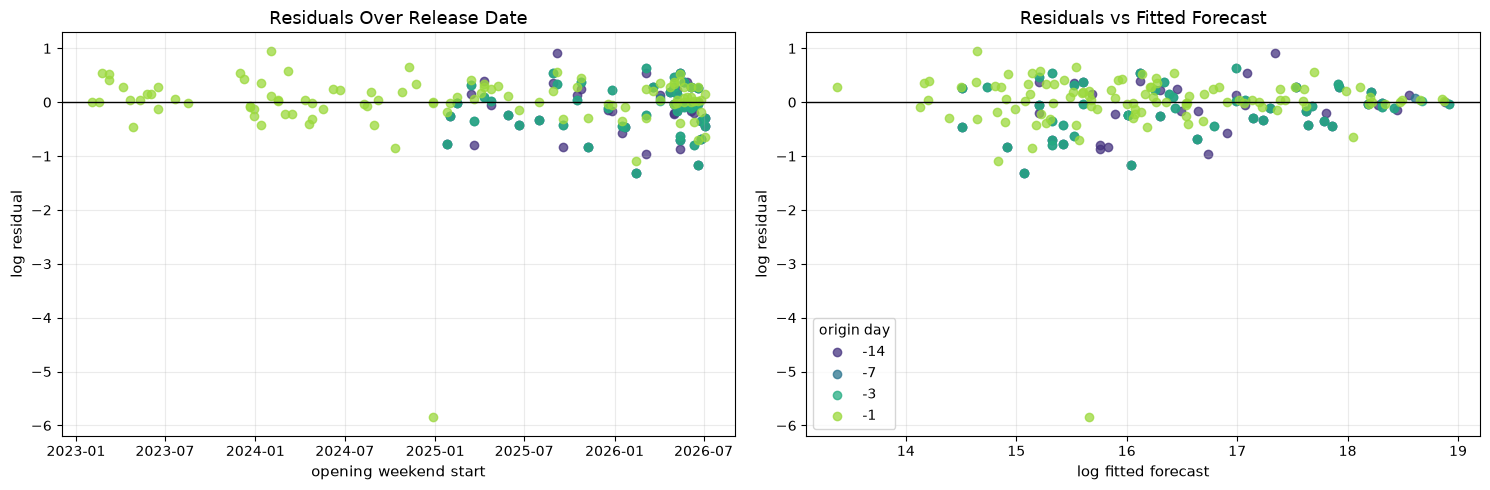

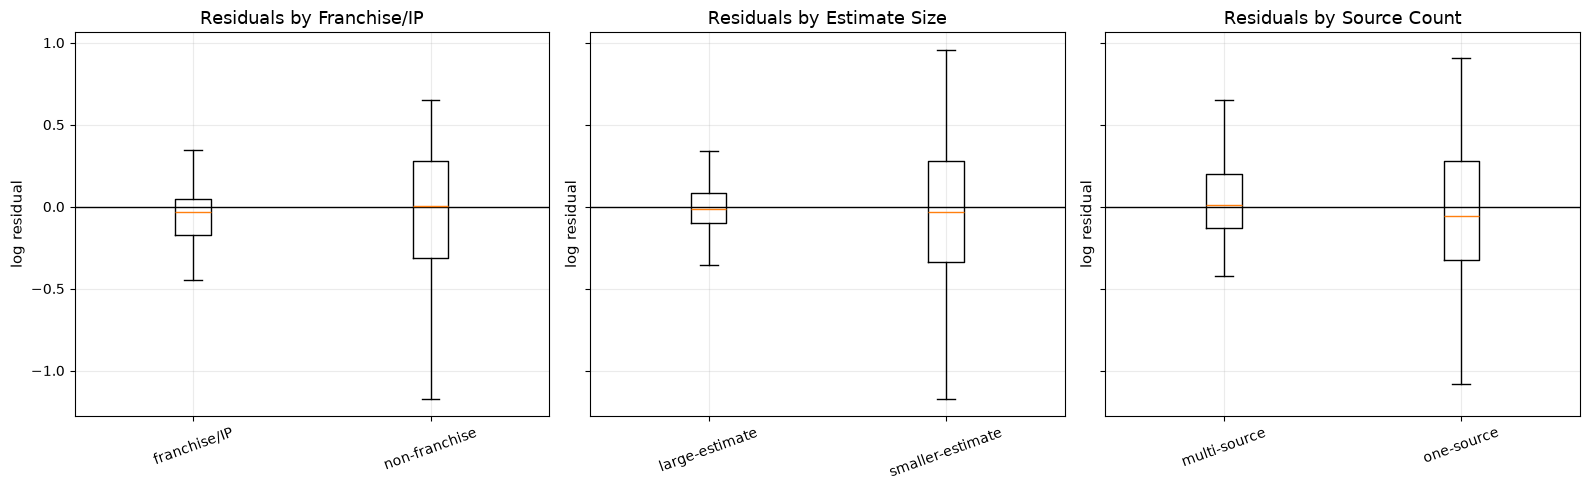

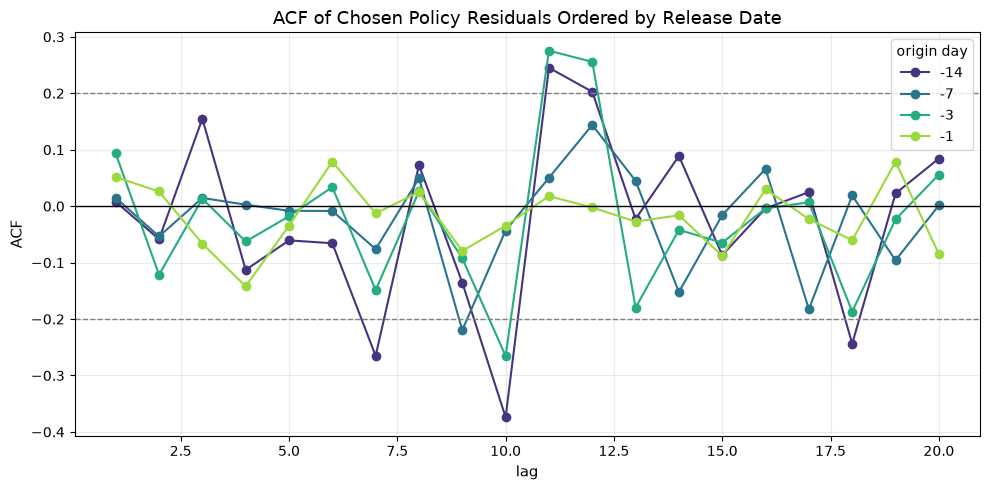

,lag,acf,forecast_origin_day,n
0,1,0.0079,-14,49
1,2,-0.0586,-14,49
2,3,0.1549,-14,49
3,4,-0.1130,-14,49
4,5,-0.0606,-14,49
5,6,-0.0657,-14,49
6,7,-0.2652,-14,49
7,8,0.0727,-14,49
8,9,-0.1354,-14,49
9,10,-0.3739,-14,49


In [303]:
origin_palette = dict(zip(FORECAST_ORIGIN_GRID_DAYS, plt.cm.viridis(np.linspace(0.15, 0.85, len(FORECAST_ORIGIN_GRID_DAYS)))))

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
for ax, origin_day in zip(axes.ravel(), FORECAST_ORIGIN_GRID_DAYS):
    x = origin_policy_residual_diagnostics.loc[
        origin_policy_residual_diagnostics["forecast_origin_day"].eq(origin_day),
        "chosen_origin_residual_log",
    ]
    ax.hist(x, bins=20, color=origin_palette[origin_day], edgecolor="white", alpha=0.85)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Origin {origin_day}: {origin_policy_map.get(origin_day)}")
    ax.set_xlabel("log residual")
    ax.set_ylabel("movies")
fig.suptitle("Chosen Policy Residual Histograms by Forecast Origin", y=0.98)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for origin_day, group in origin_policy_residual_diagnostics.groupby("forecast_origin_day"):
    ordered = group.sort_values("opening_weekend_start")
    axes[0].scatter(
        ordered["opening_weekend_start"],
        ordered["chosen_origin_residual_log"],
        alpha=0.75,
        color=origin_palette[origin_day],
        label=f"{origin_day}",
    )
    axes[1].scatter(
        ordered["chosen_origin_fitted_log"],
        ordered["chosen_origin_residual_log"],
        alpha=0.75,
        color=origin_palette[origin_day],
        label=f"{origin_day}",
    )
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residuals Over Release Date")
axes[0].set_xlabel("opening weekend start")
axes[0].set_ylabel("log residual")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Residuals vs Fitted Forecast")
axes[1].set_xlabel("log fitted forecast")
axes[1].set_ylabel("log residual")
axes[1].legend(title="origin day")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, group_col, title in [
    (axes[0], "franchise_group", "Residuals by Franchise/IP"),
    (axes[1], "estimate_size_group", "Residuals by Estimate Size"),
    (axes[2], "source_count_group", "Residuals by Source Count"),
]:
    labels = sorted(origin_policy_residual_diagnostics[group_col].dropna().unique())
    data = [origin_policy_residual_diagnostics.loc[origin_policy_residual_diagnostics[group_col].eq(label), "chosen_origin_residual_log"] for label in labels]
    try:
        ax.boxplot(data, tick_labels=labels, showfliers=False)
    except TypeError:
        ax.boxplot(data, labels=labels, showfliers=False)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(title)
    ax.set_ylabel("log residual")
    ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()

origin_policy_acf_rows = []
for origin_day, group in origin_policy_residual_diagnostics.sort_values("opening_weekend_start").groupby("forecast_origin_day"):
    max_lag = min(20, len(group) - 1)
    if max_lag < 1:
        continue
    acf_part = acf_values(group["chosen_origin_residual_log"], max_lag=max_lag)
    acf_part["forecast_origin_day"] = origin_day
    acf_part["n"] = len(group)
    origin_policy_acf_rows.append(acf_part)
origin_policy_residual_acf = pd.concat(origin_policy_acf_rows, ignore_index=True) if origin_policy_acf_rows else pd.DataFrame()

fig, ax = plt.subplots(figsize=(10, 5))
for origin_day, group in origin_policy_residual_acf.groupby("forecast_origin_day"):
    ax.plot(group["lag"], group["acf"], marker="o", label=f"{origin_day}", color=origin_palette.get(origin_day))
ax.axhline(0, color="black", linewidth=1)
ax.axhline(0.2, color="gray", linestyle="--", linewidth=1)
ax.axhline(-0.2, color="gray", linestyle="--", linewidth=1)
ax.set_title("ACF of Chosen Policy Residuals Ordered by Release Date")
ax.set_xlabel("lag")
ax.set_ylabel("ACF")
ax.legend(title="origin day")
fig.tight_layout()
plt.show()

origin_policy_residual_acf.head(12)


## Final Origin Policy Checks

The origin policy is now fixed explicitly: raw consensus at `-14`, `-7`, and `-3`; log-rigor adjustment at `-1`. These checks use that policy for portmanteau residual tests, interval calibration, risk-label review, and day-before failure-mode inspection.


In [304]:
def ljung_box_test(values, lags=(1, 2, 3, 5, 10)):
    x = pd.Series(values).dropna().astype(float).to_numpy()
    x = x - x.mean()
    n = len(x)
    rows = []
    if n < 4 or np.isclose(np.sum(x**2), 0):
        return pd.DataFrame(rows)
    max_allowed_lag = n - 2
    for lag_count in lags:
        lag_count = min(int(lag_count), max_allowed_lag)
        if lag_count < 1:
            continue
        acfs = []
        denominator = np.dot(x, x)
        for lag in range(1, lag_count + 1):
            acfs.append(np.dot(x[lag:], x[:-lag]) / denominator)
        q_stat = n * (n + 2) * sum((acf**2) / (n - lag) for lag, acf in enumerate(acfs, start=1))
        p_value = chi2.sf(q_stat, lag_count)
        rows.append({"lag_count": lag_count, "n": n, "ljung_box_q": q_stat, "p_value": p_value})
    return pd.DataFrame(rows)


origin_policy_ljung_box_rows = []
for origin_day, group in origin_policy_residual_diagnostics.sort_values("opening_weekend_start").groupby("forecast_origin_day"):
    lb = ljung_box_test(group["chosen_origin_residual_log"], lags=(1, 2, 3, 5, 10))
    if lb.empty:
        continue
    lb["forecast_origin_day"] = origin_day
    lb["chosen_origin_policy_model"] = origin_policy_map.get(origin_day)
    origin_policy_ljung_box_rows.append(lb)
origin_policy_ljung_box = (
    pd.concat(origin_policy_ljung_box_rows, ignore_index=True)
    if origin_policy_ljung_box_rows
    else pd.DataFrame(columns=["forecast_origin_day", "chosen_origin_policy_model", "lag_count", "n", "ljung_box_q", "p_value"])
)
origin_policy_ljung_box = origin_policy_ljung_box[[
    "forecast_origin_day",
    "chosen_origin_policy_model",
    "lag_count",
    "n",
    "ljung_box_q",
    "p_value",
]].sort_values(["forecast_origin_day", "lag_count"])

origin_specific_policy_table.merge(
    origin_policy_residual_summary[["forecast_origin_day", "n", "ME_log", "MAE_log", "RMSE_log", "residual_sd_log"]],
    on="forecast_origin_day",
    how="left",
)


,forecast_origin_day,chosen_origin_policy_model,chosen_origin_policy_label,n,ME_log,MAE_log,RMSE_log,residual_sd_log
0,-14,raw_consensus,raw consensus,49,-0.1727,0.3931,0.5028,0.4771
1,-7,raw_consensus,raw consensus,50,-0.1294,0.3506,0.4529,0.4384
2,-3,raw_consensus,raw consensus,50,-0.1307,0.3493,0.4527,0.4378
3,-1,log_rigor,log-rigor adjustment,103,-0.0015,0.2950,0.6599,0.6631


In [305]:
def add_chosen_policy_intervals(train_df, test_df):
    train = train_df.copy()
    test = test_df.copy()
    rows = []
    segment_rows = []
    prediction_parts = []
    for origin_day, test_origin in test.groupby("forecast_origin_day"):
        train_origin = train.loc[train["forecast_origin_day"].eq(origin_day)].copy()
        test_origin = test_origin.copy()
        policy = origin_policy_map.get(origin_day, "raw_consensus")
        forecast_col = "origin_model_1_log_rigor_forecast_usd" if policy == "log_rigor" else "origin_model_0_raw_forecast_usd"
        train_origin = train_origin.replace([np.inf, -np.inf], np.nan).dropna(subset=[forecast_col, "actual_opening_weekend_gross_usd"]).copy()
        test_origin = test_origin.replace([np.inf, -np.inf], np.nan).dropna(subset=[forecast_col, "actual_opening_weekend_gross_usd"]).copy()
        train_origin = train_origin.loc[train_origin[forecast_col].gt(0) & train_origin["actual_opening_weekend_gross_usd"].gt(0)].copy()
        test_origin = test_origin.loc[test_origin[forecast_col].gt(0) & test_origin["actual_opening_weekend_gross_usd"].gt(0)].copy()
        if train_origin.empty or test_origin.empty:
            continue
        size_cutoff = train_origin["consensus_estimate_origin_usd"].quantile(0.75)
        for frame in (train_origin, test_origin):
            frame["franchise_group"] = np.where(frame["is_franchise"].fillna(False), "franchise/IP", "non-franchise")
            frame["source_count_group"] = np.where(frame["estimate_source_count_origin"].fillna(0).astype(int).eq(1), "one-source", "multi-source")
            frame["estimate_size_group"] = np.where(frame["consensus_estimate_origin_usd"] >= size_cutoff, "large estimate", "non-large estimate")
        train_residuals = np.log(train_origin["actual_opening_weekend_gross_usd"]) - np.log(train_origin[forecast_col])
        global_sigma = train_residuals.std(ddof=1)
        test_origin["chosen_origin_interval_sigma_log"] = global_sigma
        for level, z in INTERVAL_LEVELS.items():
            test_origin[f"chosen_policy_{level}_lower"] = np.exp(np.log(test_origin[forecast_col]) - z * test_origin["chosen_origin_interval_sigma_log"])
            test_origin[f"chosen_policy_{level}_upper"] = np.exp(np.log(test_origin[forecast_col]) + z * test_origin["chosen_origin_interval_sigma_log"])
        test_origin["chosen_origin_policy_model"] = policy
        test_origin["chosen_origin_forecast_usd"] = test_origin[forecast_col]
        prediction_parts.append(test_origin)
        rows.append({
            "forecast_origin_day": origin_day,
            "chosen_origin_policy_model": policy,
            "n_test": len(test_origin),
            "global_sigma_log": global_sigma,
            "coverage_80": interval_coverage(test_origin, "chosen_policy_80_lower", "chosen_policy_80_upper"),
            "coverage_95": interval_coverage(test_origin, "chosen_policy_95_lower", "chosen_policy_95_upper"),
            "mean_80_width_to_forecast": ((test_origin["chosen_policy_80_upper"] - test_origin["chosen_policy_80_lower"]) / test_origin[forecast_col]).mean(),
            "mean_95_width_to_forecast": ((test_origin["chosen_policy_95_upper"] - test_origin["chosen_policy_95_lower"]) / test_origin[forecast_col]).mean(),
        })
        for family, segment, mask in interval_segments(test_origin):
            x = test_origin.loc[mask].copy()
            segment_rows.append({
                "forecast_origin_day": origin_day,
                "chosen_origin_policy_model": policy,
                "segment_family": family,
                "segment": segment,
                "n": len(x),
                "coverage_80": interval_coverage(x, "chosen_policy_80_lower", "chosen_policy_80_upper"),
                "coverage_95": interval_coverage(x, "chosen_policy_95_lower", "chosen_policy_95_upper"),
                "mean_80_width_to_forecast": ((x["chosen_policy_80_upper"] - x["chosen_policy_80_lower"]) / x[forecast_col]).mean() if len(x) else np.nan,
                "mean_95_width_to_forecast": ((x["chosen_policy_95_upper"] - x["chosen_policy_95_lower"]) / x[forecast_col]).mean() if len(x) else np.nan,
            })
    return pd.DataFrame(rows), pd.DataFrame(segment_rows), pd.concat(prediction_parts, ignore_index=True) if prediction_parts else pd.DataFrame()


chosen_policy_interval_rows = []
chosen_policy_interval_segment_rows = []
chosen_policy_interval_prediction_rows = []
for train_through_year, test_year in rolling_specs:
    fold_name = f"train_through_{train_through_year}__test_{test_year}"
    train_mask = (movie_origin_panel["release_year"] <= train_through_year) & ~movie_origin_panel["release_year"].isin(EXCLUDED_RELEASE_YEARS)
    test_mask = movie_origin_panel["release_year"].eq(test_year)
    fold_train = movie_origin_panel.loc[train_mask].copy()
    fold_test = movie_origin_panel.loc[test_mask].copy()
    if len(fold_train) < 10 or fold_test.empty:
        continue
    fold_train_forecasts, fold_test_forecasts, _ = add_origin_forecasts(fold_train, fold_test)
    fold_test_common = common_origin_evaluation_sample(fold_test_forecasts)
    if fold_test_common.empty:
        continue
    fold_interval, fold_segment_interval, fold_interval_predictions = add_chosen_policy_intervals(fold_train_forecasts, fold_test_common)
    for frame in (fold_interval, fold_segment_interval, fold_interval_predictions):
        if not frame.empty:
            frame["fold"] = fold_name
            frame["train_last_year"] = train_through_year
            frame["test_year"] = test_year
    chosen_policy_interval_rows.append(fold_interval)
    chosen_policy_interval_segment_rows.append(fold_segment_interval)
    chosen_policy_interval_prediction_rows.append(fold_interval_predictions)

chosen_policy_interval_coverage = pd.concat(chosen_policy_interval_rows, ignore_index=True) if chosen_policy_interval_rows else pd.DataFrame()
chosen_policy_interval_segment_coverage = pd.concat(chosen_policy_interval_segment_rows, ignore_index=True) if chosen_policy_interval_segment_rows else pd.DataFrame()
chosen_policy_interval_predictions = pd.concat(chosen_policy_interval_prediction_rows, ignore_index=True) if chosen_policy_interval_prediction_rows else pd.DataFrame()
chosen_policy_interval_summary = (
    chosen_policy_interval_coverage.groupby(["forecast_origin_day", "chosen_origin_policy_model"])
    .agg(
        folds=("fold", "nunique"),
        mean_n_test=("n_test", "mean"),
        mean_coverage_80=("coverage_80", "mean"),
        mean_coverage_95=("coverage_95", "mean"),
        mean_80_width_to_forecast=("mean_80_width_to_forecast", "mean"),
        mean_95_width_to_forecast=("mean_95_width_to_forecast", "mean"),
        mean_sigma_log=("global_sigma_log", "mean"),
    )
    .reset_index()
    .sort_values("forecast_origin_day")
)

segment_calibration_summary = (
    chosen_policy_interval_segment_coverage.groupby(["segment_family", "segment"])
    .agg(
        rows=("n", "sum"),
        mean_coverage_80=("coverage_80", "mean"),
        mean_coverage_95=("coverage_95", "mean"),
        mean_80_width_to_forecast=("mean_80_width_to_forecast", "mean"),
        mean_95_width_to_forecast=("mean_95_width_to_forecast", "mean"),
    )
    .reset_index()
    .sort_values(["segment_family", "segment"])
)
segment_calibration_summary["recommended_use"] = np.where(
    (segment_calibration_summary["mean_coverage_80"] >= 0.75) & (segment_calibration_summary["mean_coverage_95"] >= 0.90),
    "risk label only; do not create separate sigma group yet",
    "risk label only; group-specific interval calibration is weak",
)
chosen_policy_interval_summary


,forecast_origin_day,chosen_origin_policy_model,folds,mean_n_test,mean_coverage_80,mean_coverage_95,mean_80_width_to_forecast,mean_95_width_to_forecast,mean_sigma_log
0,-14,raw_consensus,2,24.5000,1.0000,1.0000,6.2293,17.9199,1.4030
1,-7,raw_consensus,2,25.0000,1.0000,1.0000,6.0424,17.0723,1.3844
2,-3,raw_consensus,2,25.0000,1.0000,1.0000,5.4378,14.4855,1.3174
3,-1,log_rigor,4,25.7500,0.9478,0.9732,1.4861,2.5513,0.5318


In [306]:
day_before_failure_modes = origin_common_evaluation_predictions.loc[
    origin_common_evaluation_predictions["forecast_origin_day"].eq(-1)
].copy()
day_before_failure_modes = day_before_failure_modes.replace([np.inf, -np.inf], np.nan).dropna(
    subset=[
        "actual_opening_weekend_gross_usd",
        "origin_model_0_raw_forecast_usd",
        "origin_model_1_log_rigor_forecast_usd",
    ]
).copy()
day_before_failure_modes["raw_abs_log_error"] = (
    np.log(day_before_failure_modes["actual_opening_weekend_gross_usd"]) - np.log(day_before_failure_modes["origin_model_0_raw_forecast_usd"])
).abs()
day_before_failure_modes["log_rigor_abs_log_error"] = (
    np.log(day_before_failure_modes["actual_opening_weekend_gross_usd"]) - np.log(day_before_failure_modes["origin_model_1_log_rigor_forecast_usd"])
).abs()
day_before_failure_modes["log_rigor_improvement_log_ae"] = (
    day_before_failure_modes["raw_abs_log_error"] - day_before_failure_modes["log_rigor_abs_log_error"]
)
day_before_failure_modes["raw_ape"] = (
    day_before_failure_modes["actual_opening_weekend_gross_usd"] / day_before_failure_modes["origin_model_0_raw_forecast_usd"] - 1
).abs()
day_before_failure_modes["log_rigor_ape"] = (
    day_before_failure_modes["actual_opening_weekend_gross_usd"] / day_before_failure_modes["origin_model_1_log_rigor_forecast_usd"] - 1
).abs()
day_before_failure_modes["log_rigor_improvement_ape"] = day_before_failure_modes["raw_ape"] - day_before_failure_modes["log_rigor_ape"]

failure_mode_cols = [
    "title",
    "opening_weekend_start",
    "actual_opening_weekend_gross_usd",
    "origin_model_0_raw_forecast_usd",
    "origin_model_1_log_rigor_forecast_usd",
    "r_cume",
    "log_r_cume",
    "estimate_source_count_origin",
    "franchise_group",
    "estimate_size_group",
    "raw_abs_log_error",
    "log_rigor_abs_log_error",
    "log_rigor_improvement_log_ae",
    "raw_ape",
    "log_rigor_ape",
    "log_rigor_improvement_ape",
]
top_10_day_before_helped_by_log_rigor = day_before_failure_modes.sort_values(
    "log_rigor_improvement_log_ae", ascending=False
)[[col for col in failure_mode_cols if col in day_before_failure_modes.columns]].head(10)
top_10_day_before_hurt_by_log_rigor = day_before_failure_modes.sort_values(
    "log_rigor_improvement_log_ae", ascending=True
)[[col for col in failure_mode_cols if col in day_before_failure_modes.columns]].head(10)

display(top_10_day_before_helped_by_log_rigor)
top_10_day_before_hurt_by_log_rigor


,title,opening_weekend_start,actual_opening_weekend_gross_usd,origin_model_0_raw_forecast_usd,origin_model_1_log_rigor_forecast_usd,r_cume,log_r_cume,estimate_source_count_origin,franchise_group,raw_abs_log_error,log_rigor_abs_log_error,log_rigor_improvement_log_ae,raw_ape,log_rigor_ape,log_rigor_improvement_ape
26,The Chosen: Season 4 Episodes 4-6 (2024),2024-02-16,"3,622,287.0000","6,450,000.0000","3,550,324.2426",0.0000,0.0000,2.0000,franchise/IP,0.5770,0.0201,0.5569,0.4384,0.0203,0.4181
220,Clika (2026),2026-01-23,"1,260,933.0000","2,000,000.0000","1,367,176.2902",4.0000,1.6094,1.0000,non-franchise,0.4613,0.0809,0.3804,0.3695,0.0777,0.2918
103,Brave the Dark (2025),2025-01-24,"2,288,135.0000","3,800,000.0000","2,739,132.0870",11.0000,2.4849,2.0000,non-franchise,0.5073,0.1799,0.3274,0.3979,0.1646,0.2332
121,Christy (2025),2025-11-07,"1,310,888.0000","2,350,000.0000","1,769,710.3824",20.0000,3.0445,2.0000,non-franchise,0.5837,0.3001,0.2836,0.4422,0.2593,0.1829
29,Arthur the King (2024),2024-03-15,"7,633,898.0000","12,500,000.0000","9,573,055.5007",18.0000,2.9444,1.0000,non-franchise,0.4931,0.2264,0.2668,0.3893,0.2026,0.1867
118,A Big Bold Beautiful Journey (2025),2025-09-19,"3,252,578.0000","5,750,000.0000","4,440,826.4348",28.0000,3.3673,2.0000,non-franchise,0.5698,0.3114,0.2584,0.4343,0.2676,0.1668
12,The Blackening (2023),2023-06-16,"6,013,131.0000","8,750,000.0000","6,775,759.2280",25.0000,3.2581,2.0000,non-franchise,0.3751,0.1194,0.2557,0.3128,0.1126,0.2002
40,Afraid (2024),2024-08-30,"3,665,664.0000","7,233,333.3333","5,602,145.7265",20.0000,3.0445,3.0000,non-franchise,0.6797,0.4241,0.2556,0.4932,0.3457,0.1476
17,Anyone But You (2023),2023-12-22,"6,000,344.0000","8,300,000.0000","6,451,640.6431",26.0000,3.2958,1.0000,non-franchise,0.3244,0.0725,0.2519,0.2771,0.0700,0.2071
235,In the Grey (2026),2026-05-15,"2,926,879.0000","5,500,000.0000","4,275,546.1980",24.0000,3.2189,1.0000,non-franchise,0.6308,0.3790,0.2518,0.4678,0.3154,0.1524


,title,opening_weekend_start,actual_opening_weekend_gross_usd,origin_model_0_raw_forecast_usd,origin_model_1_log_rigor_forecast_usd,r_cume,log_r_cume,estimate_source_count_origin,franchise_group,raw_abs_log_error,log_rigor_abs_log_error,log_rigor_improvement_log_ae,raw_ape,log_rigor_ape,log_rigor_improvement_ape
23,The Chosen: Season 4 Episodes 1-3 (2024),2024-02-02,"5,948,435.0000","4,150,000.0000","2,284,317.1483",0.0000,0.0000,2.0000,franchise/IP,0.3600,0.9571,-0.5970,0.4334,1.6040,-1.1707
44,The Best Christmas Pageant Ever (2024),2024-11-08,"10,773,559.0000","8,550,000.0000","5,637,348.1952",4.0000,1.6094,2.0000,non-franchise,0.2312,0.6477,-0.4165,0.2601,0.9111,-0.6510
226,A Great Awakening,2026-04-03,"2,041,328.0000","2,000,000.0000","1,419,481.7632",7.0000,2.0794,1.0000,non-franchise,0.0205,0.3633,-0.3429,0.0207,0.4381,-0.4174
45,Bonhoeffer: Pastor. Spy. Assassin (2024),2024-11-22,"5,047,975.0000","4,900,000.0000","3,626,273.9303",13.0000,2.6391,1.0000,non-franchise,0.0298,0.3308,-0.3010,0.0302,0.3921,-0.3619
109,The Chosen: Last Supper — Part 3 (2025),2025-04-11,"6,070,299.0000","5,800,000.0000","4,296,216.1181",16.0000,2.8332,1.0000,franchise/IP,0.0455,0.3457,-0.3001,0.0466,0.4129,-0.3663
234,Is God Is (2026),2026-05-15,"2,215,153.0000","2,000,000.0000","1,484,376.0166",13.0000,2.6391,1.0000,non-franchise,0.1022,0.4003,-0.2982,0.1076,0.4923,-0.3847
112,Clown in a Cornfield (2025),2025-05-09,"3,648,991.0000","3,600,000.0000","2,700,722.0358",19.0000,2.9957,1.0000,non-franchise,0.0135,0.3009,-0.2874,0.0136,0.3511,-0.3375
238,I Love Boosters,2026-05-22,"3,783,187.0000","3,750,000.0000","2,839,643.1391",17.0000,2.8904,1.0000,non-franchise,0.0088,0.2869,-0.2781,0.0088,0.3323,-0.3234
247,Leviticus,2026-06-19,"2,610,696.0000","2,600,000.0000","1,985,459.3395",19.0000,2.9957,2.0000,non-franchise,0.0041,0.2738,-0.2697,0.0041,0.3149,-0.3108
230,Hokum (2026),2026-05-01,"6,428,305.0000","6,000,000.0000","4,616,845.9865",21.0000,3.0910,1.0000,non-franchise,0.0690,0.3310,-0.2620,0.0714,0.3924,-0.3210


## Daily Forecast-Origin Evaluation Panel

This panel evaluates every forecast origin from `-14` through `-1` as an evaluation exercise for a daily updating forecast. It does not fit 14 unrelated regressions. The daily log-rigor candidates use pooled origin-effect models: one with a common rigor slope and one diagnostic interaction version with origin-specific rigor slopes.


In [307]:
DAILY_ORIGIN_GRID_DAYS = DAILY_FORECAST_ORIGIN_DAYS

daily_origin_grid = pd.DataFrame({"forecast_origin_day": DAILY_ORIGIN_GRID_DAYS})
daily_origin_panel = modeling[[col for col in movie_origin_base_cols if col in modeling.columns]].drop_duplicates("release_run_id").copy()
daily_origin_panel = daily_origin_panel.assign(_cross_key=1).merge(
    daily_origin_grid.assign(_cross_key=1),
    on="_cross_key",
).drop(columns="_cross_key")
daily_origin_panel["forecast_origin_date"] = (
    daily_origin_panel["opening_weekend_start"].dt.normalize()
    + pd.to_timedelta(daily_origin_panel["forecast_origin_day"], unit="D")
)

daily_panel_estimates = daily_origin_panel[[
    "release_run_id",
    "opening_weekend_start",
    "forecast_origin_day",
    "forecast_origin_date",
]].merge(origin_estimates, on="release_run_id", how="left")
daily_forecast_metric = daily_panel_estimates["forecast_metric"].fillna("").astype(str)
daily_panel_estimates = daily_panel_estimates.loc[
    daily_panel_estimates["estimate_mid_usd"].notna()
    & daily_panel_estimates["estimate_date"].notna()
    & (daily_panel_estimates["estimate_date"] <= daily_panel_estimates["forecast_origin_date"])
    & (
        daily_panel_estimates["target_start_date"].isna()
        | (daily_panel_estimates["target_start_date"].dt.normalize() == daily_panel_estimates["opening_weekend_start"].dt.normalize())
        | daily_forecast_metric.str.contains("opening", case=False, na=False)
    )
].copy()

daily_latest_source_estimates = (
    daily_panel_estimates.sort_values(["release_run_id", "forecast_origin_day", "estimate_source", "estimate_date"])
    .groupby(["release_run_id", "forecast_origin_day", "estimate_source"], as_index=False)
    .tail(1)
)
daily_consensus_asof_origin = (
    daily_latest_source_estimates.groupby(["release_run_id", "forecast_origin_day"])
    .agg(
        consensus_estimate_origin_usd=("estimate_mid_usd", "mean"),
        min_estimate_origin_usd=("estimate_mid_usd", "min"),
        max_estimate_origin_usd=("estimate_mid_usd", "max"),
        estimate_source_count_origin=("estimate_source", "nunique"),
        latest_estimate_date_origin=("estimate_date", "max"),
        estimate_sources_origin=("estimate_source", lambda s: ", ".join(sorted(set(s.dropna())))),
    )
    .reset_index()
)

daily_origin_panel = daily_origin_panel.merge(daily_consensus_asof_origin, on=["release_run_id", "forecast_origin_day"], how="left")
daily_origin_panel = daily_origin_panel.loc[daily_origin_panel["consensus_estimate_origin_usd"].gt(0)].copy()
daily_origin_panel["estimate_age_days_origin"] = (
    daily_origin_panel["forecast_origin_date"] - daily_origin_panel["latest_estimate_date_origin"]
).dt.days.clip(lower=0)

daily_rigor_asof_origin = wiki_paper.loc[wiki_paper["forecast_origin_day"].isin(DAILY_ORIGIN_GRID_DAYS)].copy()
daily_rigor_asof_origin = daily_rigor_asof_origin[[
    "release_run_id",
    "forecast_origin_day",
    "v_cume",
    "e_cume",
    "u_cume",
    "r_cume",
    "v_recent7",
    "e_recent7",
    "u_recent7",
    "r_recent7",
    "log_v_cume",
    "log_e_cume",
    "log_u_cume",
    "log_r_cume",
    "log_r_recent7",
]]
daily_origin_panel = daily_origin_panel.merge(daily_rigor_asof_origin, on=["release_run_id", "forecast_origin_day"], how="inner")
daily_origin_panel["log_consensus_estimate_origin"] = np.log(daily_origin_panel["consensus_estimate_origin_usd"])
daily_origin_panel["residual_log_actual_to_consensus"] = (
    daily_origin_panel["log_actual_opening_weekend"] - daily_origin_panel["log_consensus_estimate_origin"]
)
daily_origin_panel["source_count_group"] = np.where(
    daily_origin_panel["estimate_source_count_origin"].fillna(0).astype(int).eq(1),
    "one-source",
    "multi-source",
)
daily_origin_panel["franchise_group"] = np.where(daily_origin_panel["is_franchise"].fillna(False), "franchise/IP", "non-franchise")

daily_origin_summary = (
    daily_origin_panel.groupby("forecast_origin_day")
    .agg(
        rows=("release_run_id", "count"),
        movies=("release_run_id", "nunique"),
        median_consensus_usd=("consensus_estimate_origin_usd", "median"),
        median_source_count=("estimate_source_count_origin", "median"),
        median_estimate_age_days=("estimate_age_days_origin", "median"),
        median_rigor=("r_cume", "median"),
    )
    .reset_index()
)
daily_origin_summary


,forecast_origin_day,rows,movies,median_consensus_usd,median_source_count,median_estimate_age_days,median_rigor
0,-14,61,61,"14,000,000.0000",1.0000,0.0000,15.0000
1,-13,61,61,"14,000,000.0000",1.0000,1.0000,16.0000
2,-12,61,61,"14,000,000.0000",1.0000,2.0000,16.0000
3,-11,61,61,"14,000,000.0000",1.0000,3.0000,17.0000
4,-10,61,61,"14,000,000.0000",1.0000,4.0000,18.0000
5,-9,61,61,"14,000,000.0000",1.0000,5.0000,22.0000
6,-8,62,62,"14,250,000.0000",1.0000,6.0000,25.0000
7,-7,63,63,"12,000,000.0000",1.0000,0.0000,25.0000
8,-6,63,63,"12,000,000.0000",1.0000,1.0000,26.0000
9,-5,63,63,"12,000,000.0000",1.0000,2.0000,29.0000


In [308]:
DAILY_MODEL_FORECAST_COLS = {
    "raw consensus": "daily_model_0_raw_forecast_usd",
    "pooled log rigor": "daily_model_1_pooled_log_rigor_forecast_usd",
    "origin-interaction log rigor": "daily_model_2_interaction_log_rigor_forecast_usd",
}


def make_daily_origin_design(df, origin_days, interaction=False):
    x = pd.DataFrame(index=df.index)
    x["intercept"] = 1.0
    for day in origin_days[1:]:
        x[f"origin_{day}"] = df["forecast_origin_day"].eq(day).astype(float)
    x["log_r_cume"] = df["log_r_cume"].astype(float)
    if interaction:
        for day in origin_days[1:]:
            x[f"origin_{day}_x_log_r_cume"] = x[f"origin_{day}"] * x["log_r_cume"]
    return x


def fit_daily_pooled_log_rigor(train_df, origin_days, interaction=False):
    model_df = train_df.dropna(subset=["residual_log_actual_to_consensus", "log_r_cume"]).copy()
    if len(model_df) < 30 or model_df["log_r_cume"].nunique() < 2:
        return None
    design = make_daily_origin_design(model_df, origin_days, interaction=interaction)
    beta, sigma, _ = fit_lstsq(design.to_numpy(dtype=float), model_df["residual_log_actual_to_consensus"].to_numpy(dtype=float))
    return {"beta": beta, "columns": design.columns.tolist(), "sigma": sigma, "n_train": len(model_df), "interaction": interaction}


def predict_daily_pooled_log_rigor(model, df, origin_days):
    if model is None:
        return pd.Series(np.nan, index=df.index)
    design = make_daily_origin_design(df, origin_days, interaction=model["interaction"])
    design = design.reindex(columns=model["columns"], fill_value=0.0)
    return pd.Series(design.to_numpy(dtype=float) @ model["beta"], index=df.index)


def add_daily_policy_forecasts(train_df, test_df):
    train = train_df.copy()
    test = test_df.copy()
    for frame in (train, test):
        frame["daily_model_0_raw_forecast_usd"] = frame["consensus_estimate_origin_usd"]
        frame["daily_model_0_predicted_residual_log"] = 0.0
    pooled_model = fit_daily_pooled_log_rigor(train, DAILY_ORIGIN_GRID_DAYS, interaction=False)
    interaction_model = fit_daily_pooled_log_rigor(train, DAILY_ORIGIN_GRID_DAYS, interaction=True)
    for model, prefix in [
        (pooled_model, "daily_model_1_pooled_log_rigor"),
        (interaction_model, "daily_model_2_interaction_log_rigor"),
    ]:
        for frame in (train, test):
            predicted_residual = predict_daily_pooled_log_rigor(model, frame, DAILY_ORIGIN_GRID_DAYS)
            frame[f"{prefix}_predicted_residual_log"] = predicted_residual
            frame[f"{prefix}_forecast_usd"] = frame["consensus_estimate_origin_usd"] * np.exp(predicted_residual)
    coefficient_rows = []
    for model_name, model in [("pooled log rigor", pooled_model), ("origin-interaction log rigor", interaction_model)]:
        if model is None:
            coefficient_rows.append({"model": model_name, "n_train": len(train), "sigma_log": np.nan, "interaction": model_name.startswith("origin")})
            continue
        row = {"model": model_name, "n_train": model["n_train"], "sigma_log": model["sigma"], "interaction": model["interaction"]}
        row.update({f"coef_{col}": value for col, value in zip(model["columns"], model["beta"])})
        coefficient_rows.append(row)
    return train, test, pd.DataFrame(coefficient_rows)


def common_daily_evaluation_sample(df):
    required_cols = ["actual_opening_weekend_gross_usd", *DAILY_MODEL_FORECAST_COLS.values()]
    x = df.replace([np.inf, -np.inf], np.nan).dropna(subset=required_cols).copy()
    positive = x["actual_opening_weekend_gross_usd"].gt(0)
    for forecast_col in DAILY_MODEL_FORECAST_COLS.values():
        positive &= x[forecast_col].gt(0)
    return x.loc[positive].copy()


def evaluate_daily_forecast(df, forecast_col, model_label):
    x = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[forecast_col, "actual_opening_weekend_gross_usd"]).copy()
    x = x.loc[x[forecast_col].gt(0) & x["actual_opening_weekend_gross_usd"].gt(0)].copy()
    if x.empty:
        return {"model": model_label, "n": 0, "ME_log": np.nan, "MAE_log": np.nan, "RMSE_log": np.nan, "MdAPE": np.nan}
    residual = np.log(x["actual_opening_weekend_gross_usd"]) - np.log(x[forecast_col])
    return {
        "model": model_label,
        "n": len(x),
        "ME_log": residual.mean(),
        "MAE_log": residual.abs().mean(),
        "RMSE_log": np.sqrt(np.mean(residual**2)),
        "MdAPE": np.median(np.abs(x["actual_opening_weekend_gross_usd"] / x[forecast_col] - 1)),
        "sigma_log": residual.std(ddof=1),
    }


daily_metric_rows = []
daily_coefficient_rows = []
daily_prediction_rows = []
for train_through_year, test_year in rolling_specs:
    fold_name = f"train_through_{train_through_year}__test_{test_year}"
    train_mask = (daily_origin_panel["release_year"] <= train_through_year) & ~daily_origin_panel["release_year"].isin(EXCLUDED_RELEASE_YEARS)
    test_mask = daily_origin_panel["release_year"].eq(test_year)
    fold_train = daily_origin_panel.loc[train_mask].copy()
    fold_test = daily_origin_panel.loc[test_mask].copy()
    if len(fold_train) < 30 or fold_test.empty:
        continue
    fold_train_forecasts, fold_test_forecasts, fold_coefficients = add_daily_policy_forecasts(fold_train, fold_test)
    fold_test_common = common_daily_evaluation_sample(fold_test_forecasts)
    if fold_test_common.empty:
        continue
    fold_test_common["fold"] = fold_name
    fold_test_common["train_last_year"] = train_through_year
    fold_test_common["test_year"] = test_year
    daily_prediction_rows.append(fold_test_common)
    fold_coefficients["fold"] = fold_name
    fold_coefficients["train_last_year"] = train_through_year
    fold_coefficients["test_year"] = test_year
    daily_coefficient_rows.append(fold_coefficients)
    for origin_day, origin_test in fold_test_common.groupby("forecast_origin_day"):
        for model_label, forecast_col in DAILY_MODEL_FORECAST_COLS.items():
            row = evaluate_daily_forecast(origin_test, forecast_col, model_label)
            row.update({"fold": fold_name, "train_last_year": train_through_year, "test_year": test_year, "forecast_origin_day": origin_day})
            daily_metric_rows.append(row)

daily_origin_predictions = pd.concat(daily_prediction_rows, ignore_index=True) if daily_prediction_rows else pd.DataFrame()
daily_origin_coefficients = pd.concat(daily_coefficient_rows, ignore_index=True) if daily_coefficient_rows else pd.DataFrame()
daily_origin_metrics = pd.DataFrame(daily_metric_rows)
daily_origin_metric_summary = (
    daily_origin_metrics.groupby(["forecast_origin_day", "model"])
    .agg(
        folds=("fold", "nunique"),
        mean_n=("n", "mean"),
        mean_ME_log=("ME_log", "mean"),
        mean_MAE_log=("MAE_log", "mean"),
        mean_RMSE_log=("RMSE_log", "mean"),
        mean_MdAPE=("MdAPE", "mean"),
        mean_sigma_log=("sigma_log", "mean"),
    )
    .reset_index()
    .sort_values(["forecast_origin_day", "model"])
)
daily_origin_metric_summary


,forecast_origin_day,model,folds,mean_n,mean_ME_log,mean_MAE_log,mean_RMSE_log,mean_MdAPE,mean_sigma_log
0,-14,origin-interaction log rigor,3,20.3333,0.0989,0.5476,0.9191,0.3984,0.8755
1,-14,pooled log rigor,3,20.3333,0.1454,0.5755,0.9209,0.4620,0.8630
2,-14,raw consensus,3,20.3333,-0.3326,0.5130,0.9127,0.2592,0.8805
3,-13,origin-interaction log rigor,3,20.3333,0.0929,0.5453,0.9150,0.3866,0.8733
4,-13,pooled log rigor,3,20.3333,0.1423,0.5735,0.9191,0.4594,0.8613
5,-13,raw consensus,3,20.3333,-0.3326,0.5130,0.9127,0.2592,0.8805
6,-12,origin-interaction log rigor,3,20.3333,0.0894,0.5361,0.9083,0.3810,0.8661
7,-12,pooled log rigor,3,20.3333,0.1387,0.5723,0.9186,0.4498,0.8618
8,-12,raw consensus,3,20.3333,-0.3326,0.5130,0.9127,0.2592,0.8805
9,-11,origin-interaction log rigor,3,20.3333,0.1066,0.5511,0.9157,0.4141,0.8598


In [309]:
def add_daily_origin_intervals(train_df, test_df):
    train = train_df.copy()
    test = common_daily_evaluation_sample(test_df)
    rows = []
    prediction_parts = []
    for model_label, forecast_col in DAILY_MODEL_FORECAST_COLS.items():
        for origin_day, origin_test in test.groupby("forecast_origin_day"):
            train_origin = train.loc[train["forecast_origin_day"].eq(origin_day)].replace([np.inf, -np.inf], np.nan).dropna(
                subset=[forecast_col, "actual_opening_weekend_gross_usd"]
            ).copy()
            origin_test = origin_test.replace([np.inf, -np.inf], np.nan).dropna(subset=[forecast_col, "actual_opening_weekend_gross_usd"]).copy()
            train_origin = train_origin.loc[train_origin[forecast_col].gt(0) & train_origin["actual_opening_weekend_gross_usd"].gt(0)].copy()
            origin_test = origin_test.loc[origin_test[forecast_col].gt(0) & origin_test["actual_opening_weekend_gross_usd"].gt(0)].copy()
            if train_origin.empty or origin_test.empty:
                continue
            residual = np.log(train_origin["actual_opening_weekend_gross_usd"]) - np.log(train_origin[forecast_col])
            sigma = residual.std(ddof=1)
            out = origin_test.copy()
            out["daily_interval_model"] = model_label
            out["daily_interval_forecast_col"] = forecast_col
            out["daily_interval_sigma_log"] = sigma
            for level, z in INTERVAL_LEVELS.items():
                out[f"daily_{level}_lower"] = np.exp(np.log(out[forecast_col]) - z * sigma)
                out[f"daily_{level}_upper"] = np.exp(np.log(out[forecast_col]) + z * sigma)
            prediction_parts.append(out)
            rows.append({
                "model": model_label,
                "forecast_origin_day": origin_day,
                "n_test": len(out),
                "sigma_log": sigma,
                "coverage_80": interval_coverage(out, "daily_80_lower", "daily_80_upper"),
                "coverage_95": interval_coverage(out, "daily_95_lower", "daily_95_upper"),
                "mean_80_width_to_forecast": ((out["daily_80_upper"] - out["daily_80_lower"]) / out[forecast_col]).mean(),
                "mean_95_width_to_forecast": ((out["daily_95_upper"] - out["daily_95_lower"]) / out[forecast_col]).mean(),
            })
    return pd.DataFrame(rows), pd.concat(prediction_parts, ignore_index=True) if prediction_parts else pd.DataFrame()


daily_interval_rows = []
daily_interval_prediction_rows = []
for train_through_year, test_year in rolling_specs:
    fold_name = f"train_through_{train_through_year}__test_{test_year}"
    train_mask = (daily_origin_panel["release_year"] <= train_through_year) & ~daily_origin_panel["release_year"].isin(EXCLUDED_RELEASE_YEARS)
    test_mask = daily_origin_panel["release_year"].eq(test_year)
    fold_train = daily_origin_panel.loc[train_mask].copy()
    fold_test = daily_origin_panel.loc[test_mask].copy()
    if len(fold_train) < 30 or fold_test.empty:
        continue
    fold_train_forecasts, fold_test_forecasts, _ = add_daily_policy_forecasts(fold_train, fold_test)
    fold_interval, fold_interval_predictions = add_daily_origin_intervals(fold_train_forecasts, fold_test_forecasts)
    if not fold_interval.empty:
        fold_interval["fold"] = fold_name
        fold_interval["train_last_year"] = train_through_year
        fold_interval["test_year"] = test_year
        daily_interval_rows.append(fold_interval)
    if not fold_interval_predictions.empty:
        fold_interval_predictions["fold"] = fold_name
        fold_interval_predictions["train_last_year"] = train_through_year
        fold_interval_predictions["test_year"] = test_year
        daily_interval_prediction_rows.append(fold_interval_predictions)

daily_origin_interval_coverage = pd.concat(daily_interval_rows, ignore_index=True) if daily_interval_rows else pd.DataFrame()
daily_origin_interval_predictions = pd.concat(daily_interval_prediction_rows, ignore_index=True) if daily_interval_prediction_rows else pd.DataFrame()
daily_origin_interval_summary = (
    daily_origin_interval_coverage.groupby(["forecast_origin_day", "model"])
    .agg(
        folds=("fold", "nunique"),
        mean_n_test=("n_test", "mean"),
        mean_coverage_80=("coverage_80", "mean"),
        mean_coverage_95=("coverage_95", "mean"),
        mean_80_width_to_forecast=("mean_80_width_to_forecast", "mean"),
        mean_95_width_to_forecast=("mean_95_width_to_forecast", "mean"),
        mean_interval_sigma_log=("sigma_log", "mean"),
    )
    .reset_index()
    .sort_values(["forecast_origin_day", "model"])
)

daily_accuracy_wide = daily_origin_metric_summary.pivot(
    index="forecast_origin_day",
    columns="model",
    values=["mean_n", "mean_MAE_log", "mean_RMSE_log", "mean_MdAPE", "mean_sigma_log"],
)
daily_accuracy_wide.columns = [f"{metric}_{model}" for metric, model in daily_accuracy_wide.columns]
daily_accuracy_wide = daily_accuracy_wide.reset_index()
daily_interval_wide = daily_origin_interval_summary.pivot(
    index="forecast_origin_day",
    columns="model",
    values=["mean_coverage_80", "mean_coverage_95", "mean_80_width_to_forecast", "mean_95_width_to_forecast", "mean_interval_sigma_log"],
)
daily_interval_wide.columns = [f"{metric}_{model}" for metric, model in daily_interval_wide.columns]
daily_interval_wide = daily_interval_wide.reset_index()
daily_origin_performance_curve = daily_accuracy_wide.merge(daily_interval_wide, on="forecast_origin_day", how="outer").sort_values("forecast_origin_day")
for candidate in ["pooled log rigor", "origin-interaction log rigor"]:
    raw_mae = "mean_MAE_log_raw consensus"
    cand_mae = f"mean_MAE_log_{candidate}"
    raw_rmse = "mean_RMSE_log_raw consensus"
    cand_rmse = f"mean_RMSE_log_{candidate}"
    if {raw_mae, cand_mae}.issubset(daily_origin_performance_curve.columns):
        daily_origin_performance_curve[f"MAE_log_improvement_{candidate}"] = daily_origin_performance_curve[raw_mae] - daily_origin_performance_curve[cand_mae]
    if {raw_rmse, cand_rmse}.issubset(daily_origin_performance_curve.columns):
        daily_origin_performance_curve[f"RMSE_log_improvement_{candidate}"] = daily_origin_performance_curve[raw_rmse] - daily_origin_performance_curve[cand_rmse]

daily_policy_switch_candidates = daily_origin_performance_curve[[
    col for col in [
        "forecast_origin_day",
        "mean_MAE_log_raw consensus",
        "mean_MAE_log_pooled log rigor",
        "mean_RMSE_log_raw consensus",
        "mean_RMSE_log_pooled log rigor",
        "mean_MdAPE_raw consensus",
        "mean_MdAPE_pooled log rigor",
        "MAE_log_improvement_pooled log rigor",
        "RMSE_log_improvement_pooled log rigor",
        "mean_coverage_80_raw consensus",
        "mean_coverage_80_pooled log rigor",
        "mean_80_width_to_forecast_raw consensus",
        "mean_80_width_to_forecast_pooled log rigor",
    ] if col in daily_origin_performance_curve.columns
]].copy()

daily_policy_switch_candidates["pooled_log_rigor_beats_raw_mae_rmse"] = (
    daily_policy_switch_candidates.get("MAE_log_improvement_pooled log rigor", pd.Series(index=daily_policy_switch_candidates.index, dtype=float)).gt(0)
    & daily_policy_switch_candidates.get("RMSE_log_improvement_pooled log rigor", pd.Series(index=daily_policy_switch_candidates.index, dtype=float)).gt(0)
)

daily_policy_switch_candidates


,forecast_origin_day,mean_MAE_log_raw consensus,mean_MAE_log_pooled log rigor,mean_RMSE_log_raw consensus,mean_RMSE_log_pooled log rigor,mean_MdAPE_raw consensus,mean_MdAPE_pooled log rigor,MAE_log_improvement_pooled log rigor,RMSE_log_improvement_pooled log rigor,mean_coverage_80_raw consensus,mean_coverage_80_pooled log rigor,mean_80_width_to_forecast_raw consensus,mean_80_width_to_forecast_pooled log rigor,pooled_log_rigor_beats_raw_mae_rmse
0,-14,0.5130,0.5755,0.9127,0.9209,0.2592,0.4620,-0.0626,-0.0082,1.0000,1.0000,6.2293,6.1366,False
1,-13,0.5130,0.5735,0.9127,0.9191,0.2592,0.4594,-0.0606,-0.0064,1.0000,1.0000,6.2293,6.1309,False
2,-12,0.5130,0.5723,0.9127,0.9186,0.2592,0.4498,-0.0594,-0.0059,1.0000,1.0000,6.2293,6.1415,False
3,-11,0.5130,0.5729,0.9127,0.9224,0.2592,0.4492,-0.0599,-0.0097,1.0000,1.0000,6.2293,6.1815,False
4,-10,0.5130,0.5705,0.9127,0.9217,0.2592,0.4416,-0.0575,-0.0090,1.0000,1.0000,6.2293,6.1691,False
5,-9,0.5130,0.5727,0.9127,0.9280,0.2592,0.4397,-0.0598,-0.0153,1.0000,1.0000,6.2293,6.2404,False
6,-8,0.4990,0.5764,0.7983,0.8153,0.2858,0.4962,-0.0774,-0.0170,1.0000,1.0000,5.7952,5.8042,False
7,-7,0.4700,0.5997,0.7787,0.8290,0.2801,0.5080,-0.1298,-0.0503,1.0000,1.0000,6.0424,6.1001,False
8,-6,0.4700,0.6002,0.7787,0.8299,0.2801,0.5081,-0.1303,-0.0512,1.0000,1.0000,6.0424,6.1093,False
9,-5,0.4700,0.5984,0.7787,0.8304,0.2801,0.5063,-0.1284,-0.0516,1.0000,1.0000,6.0424,6.0980,False


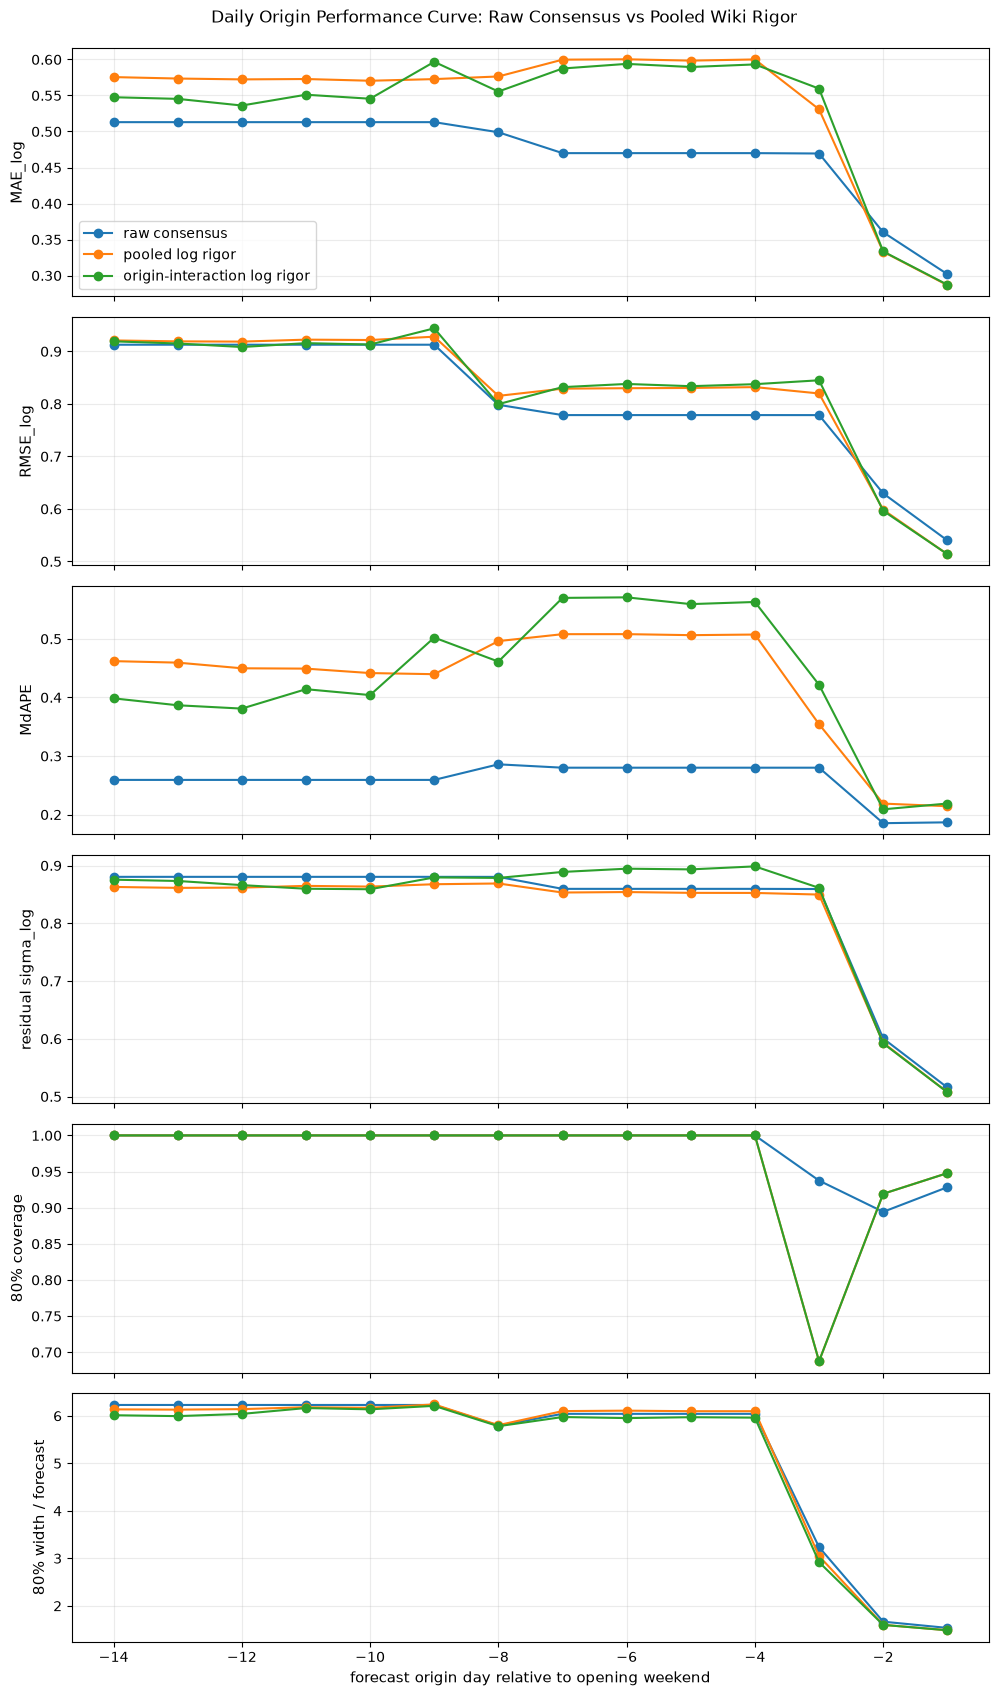

,forecast_origin_day,mean_n_origin-interaction log rigor,mean_n_pooled log rigor,mean_n_raw consensus,mean_MAE_log_origin-interaction log rigor,mean_MAE_log_pooled log rigor,mean_MAE_log_raw consensus,mean_RMSE_log_origin-interaction log rigor,mean_RMSE_log_pooled log rigor,mean_RMSE_log_raw consensus,...,mean_95_width_to_forecast_origin-interaction log rigor,mean_95_width_to_forecast_pooled log rigor,mean_95_width_to_forecast_raw consensus,mean_interval_sigma_log_origin-interaction log rigor,mean_interval_sigma_log_pooled log rigor,mean_interval_sigma_log_raw consensus,MAE_log_improvement_pooled log rigor,RMSE_log_improvement_pooled log rigor,MAE_log_improvement_origin-interaction log rigor,RMSE_log_improvement_origin-interaction log rigor
0,-14,20.3333,20.3333,20.3333,0.5476,0.5755,0.5130,0.9191,0.9209,0.9127,...,17.0080,17.5454,17.9199,1.3776,1.3912,1.4030,-0.0626,-0.0082,-0.0346,-0.0064
1,-13,20.3333,20.3333,20.3333,0.5453,0.5735,0.5130,0.9150,0.9191,0.9127,...,16.9295,17.5224,17.9199,1.3755,1.3905,1.4030,-0.0606,-0.0064,-0.0323,-0.0023
2,-12,20.3333,20.3333,20.3333,0.5361,0.5723,0.5130,0.9083,0.9186,0.9127,...,17.1304,17.5663,17.9199,1.3806,1.3918,1.4030,-0.0594,-0.0059,-0.0231,0.0044
3,-11,20.3333,20.3333,20.3333,0.5511,0.5729,0.5130,0.9157,0.9224,0.9127,...,17.6690,17.7369,17.9199,1.3941,1.3964,1.4030,-0.0599,-0.0097,-0.0381,-0.0030
4,-10,20.3333,20.3333,20.3333,0.5455,0.5705,0.5130,0.9131,0.9217,0.9127,...,17.5528,17.6839,17.9199,1.3910,1.3950,1.4030,-0.0575,-0.0090,-0.0325,-0.0004
5,-9,20.3333,20.3333,20.3333,0.5967,0.5727,0.5130,0.9439,0.9280,0.9127,...,17.8464,17.9883,17.9199,1.4005,1.4032,1.4030,-0.0598,-0.0153,-0.0837,-0.0312
6,-8,15.5000,15.5000,15.5000,0.5555,0.5764,0.4990,0.7996,0.8153,0.7983,...,15.9425,16.0416,15.9901,1.3561,1.3582,1.3580,-0.0774,-0.0170,-0.0565,-0.0013
7,-7,15.7500,15.7500,15.7500,0.5874,0.5997,0.4700,0.8319,0.8290,0.7787,...,16.7629,17.3234,17.0723,1.3780,1.3907,1.3844,-0.1298,-0.0503,-0.1175,-0.0532
8,-6,15.7500,15.7500,15.7500,0.5939,0.6002,0.4700,0.8380,0.8299,0.7787,...,16.6612,17.3634,17.0723,1.3759,1.3917,1.3844,-0.1303,-0.0512,-0.1239,-0.0593
9,-5,15.7500,15.7500,15.7500,0.5895,0.5984,0.4700,0.8337,0.8304,0.7787,...,16.7456,17.3140,17.0723,1.3777,1.3904,1.3844,-0.1284,-0.0516,-0.1196,-0.0550


In [310]:
plot_specs = [
    ("mean_MAE_log", "MAE_log"),
    ("mean_RMSE_log", "RMSE_log"),
    ("mean_MdAPE", "MdAPE"),
    ("mean_sigma_log", "residual sigma_log"),
    ("mean_coverage_80", "80% coverage"),
    ("mean_80_width_to_forecast", "80% width / forecast"),
]
fig, axes = plt.subplots(len(plot_specs), 1, figsize=(10, 17), sharex=True)
for ax, (metric_prefix, ylabel) in zip(axes, plot_specs):
    for model_label in ["raw consensus", "pooled log rigor", "origin-interaction log rigor"]:
        col = f"{metric_prefix}_{model_label}"
        if col in daily_origin_performance_curve.columns:
            ax.plot(
                daily_origin_performance_curve["forecast_origin_day"],
                daily_origin_performance_curve[col],
                marker="o",
                label=model_label,
            )
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel("forecast origin day relative to opening weekend")
axes[0].legend(loc="best")
fig.suptitle("Daily Origin Performance Curve: Raw Consensus vs Pooled Wiki Rigor", y=0.995)
fig.tight_layout()
plt.show()

daily_origin_performance_curve


## Export Wiki Model Comparison

The export keeps one row per 2024+ test release, Wiki features, all point forecasts, the chosen forecast, and any recomputed interval columns.


In [311]:
export_df = test_intervals.copy()
export_df["chosen_model"] = chosen_model_label
export_df["chosen_forecast_usd"] = export_df[chosen_forecast_col]
export_df["chosen_residual_log"] = np.log(export_df["actual_opening_weekend_gross_usd"]) - np.log(export_df["chosen_forecast_usd"])

export_cols = [
    "release_run_id",
    "movie_id",
    "title",
    "opening_weekend_start",
    "forecast_cutoff_date",
    "late_origin_day",
    "latest_estimate_date",
    "estimate_origin_day",
    "release_year",
    "actual_opening_weekend_gross_usd",
    "consensus_estimate_usd",
    "is_franchise",
    "estimate_source_count",
    "estimate_sources",
    "estimate_age_days",
    "estimate_size_group",
    "source_count_group",
    "v_cume_origin",
    "e_cume_origin",
    "u_cume_origin",
    "r_cume_origin",
    "v_recent7_origin",
    "e_recent7_origin",
    "u_recent7_origin",
    "r_recent7_origin",
    "wiki_at_estimate_log_r",
    "wiki_at_origin_log_r",
    "wiki_move_log_r",
    "wiki_move_recent7_log_r",
    "expected_wiki_at_origin_log_r",
    "wiki_surprise_log_r",
    "model_0_raw_consensus_forecast_usd",
    "model_1_log_rigor_forecast_usd",
    "model_2_wiki_move_forecast_usd",
    "model_3_wiki_surprise_forecast_usd",
    "chosen_model",
    "chosen_forecast_usd",
    "chosen_residual_log",
    "raw_consensus_franchise_sd_80_lower",
    "raw_consensus_franchise_sd_80_upper",
    "raw_consensus_franchise_sd_95_lower",
    "raw_consensus_franchise_sd_95_upper",
    "log_rigor_franchise_sd_80_lower",
    "log_rigor_franchise_sd_80_upper",
    "log_rigor_franchise_sd_95_lower",
    "log_rigor_franchise_sd_95_upper",
]

export_dir = repo_root / "data" / "diagnostics"
export_dir.mkdir(parents=True, exist_ok=True)

export_path = export_dir / "late_forecast_point_calibration_model_comparison.csv"
export_df[[col for col in export_cols if col in export_df.columns]].sort_values("opening_weekend_start").to_csv(export_path, index=False)

lag_export_path = export_dir / "late_forecast_wiki_lag_effect_summary.csv"
lag_effect_summary.to_csv(lag_export_path, index=False)

rolling_export_path = export_dir / "late_forecast_wiki_rolling_origin_metrics.csv"
rolling_origin_metrics.reset_index().to_csv(rolling_export_path, index=False)

paired_export_path = export_dir / "late_forecast_wiki_paired_error_comparison.csv"
paired_comparison[[col for col in paired_display_cols + ["wiki_rigor_improved", "improvement_ape"] if col in paired_comparison.columns]].sort_values(
    "improvement_log_ae",
    ascending=False,
).to_csv(paired_export_path, index=False)

paired_segment_export_path = export_dir / "late_forecast_wiki_paired_segment_summary.csv"
paired_segment_summary.reset_index().to_csv(paired_segment_export_path, index=False)

interval_export_path = export_dir / "late_forecast_raw_vs_log_rigor_interval_coverage.csv"
interval_recheck.to_csv(interval_export_path, index=False)

interval_segment_export_path = export_dir / "late_forecast_raw_vs_log_rigor_interval_segment_coverage.csv"
interval_segment_coverage.to_csv(interval_segment_export_path, index=False)

rolling_interval_export_path = export_dir / "late_forecast_raw_vs_log_rigor_rolling_interval_coverage.csv"
rolling_interval_coverage.to_csv(rolling_interval_export_path, index=False)

rolling_interval_segment_export_path = export_dir / "late_forecast_raw_vs_log_rigor_rolling_interval_segment_coverage.csv"
rolling_interval_segment_coverage.to_csv(rolling_interval_segment_export_path, index=False)

residual_export_path = export_dir / "late_forecast_log_rigor_residual_diagnostics.csv"
residual_diagnostics[[
    "release_run_id",
    "movie_id",
    "title",
    "opening_weekend_start",
    "actual_opening_weekend_gross_usd",
    "raw_forecast_usd",
    "log_rigor_forecast_usd",
    "raw_residual_log",
    "log_rigor_residual_log",
    "raw_abs_residual_log",
    "log_rigor_abs_residual_log",
    "wiki_at_origin_log_r",
    "franchise_group",
    "source_count_group",
    "estimate_size_group",
]].sort_values("opening_weekend_start").to_csv(residual_export_path, index=False)

origin_panel_export_path = export_dir / "late_forecast_movie_origin_panel.csv"
movie_origin_panel.to_csv(origin_panel_export_path, index=False)

origin_metrics_export_path = export_dir / "late_forecast_by_origin_rolling_metrics.csv"
origin_rolling_metrics.to_csv(origin_metrics_export_path, index=False)

origin_interval_export_path = export_dir / "late_forecast_by_origin_interval_coverage.csv"
origin_interval_coverage.to_csv(origin_interval_export_path, index=False)

origin_interval_segment_export_path = export_dir / "late_forecast_by_origin_interval_segment_coverage.csv"
origin_interval_segment_coverage.to_csv(origin_interval_segment_export_path, index=False)

origin_summary_export_path = export_dir / "late_forecast_by_origin_summary.csv"
late_forecast_by_origin_summary.to_csv(origin_summary_export_path, index=False)

origin_common_predictions_export_path = export_dir / "late_forecast_by_origin_common_predictions.csv"
origin_common_evaluation_predictions.to_csv(origin_common_predictions_export_path, index=False)

origin_curve_export_path = export_dir / "late_forecast_by_origin_performance_curve.csv"
origin_performance_curve.to_csv(origin_curve_export_path, index=False)

origin_policy_residual_export_path = export_dir / "late_forecast_origin_policy_residual_diagnostics.csv"
origin_policy_residual_diagnostics.to_csv(origin_policy_residual_export_path, index=False)

origin_policy_residual_summary_export_path = export_dir / "late_forecast_origin_policy_residual_summary.csv"
origin_policy_residual_summary.to_csv(origin_policy_residual_summary_export_path, index=False)

origin_policy_residual_group_export_path = export_dir / "late_forecast_origin_policy_residual_group_summary.csv"
origin_policy_residual_group_summary.to_csv(origin_policy_residual_group_export_path, index=False)

origin_policy_residual_acf_export_path = export_dir / "late_forecast_origin_policy_residual_acf.csv"
origin_policy_residual_acf.to_csv(origin_policy_residual_acf_export_path, index=False)

origin_specific_policy_export_path = export_dir / "late_forecast_origin_specific_policy_table.csv"
origin_specific_policy_table.to_csv(origin_specific_policy_export_path, index=False)

origin_policy_ljung_box_export_path = export_dir / "late_forecast_origin_policy_ljung_box.csv"
origin_policy_ljung_box.to_csv(origin_policy_ljung_box_export_path, index=False)

chosen_policy_interval_export_path = export_dir / "late_forecast_chosen_policy_interval_coverage.csv"
chosen_policy_interval_coverage.to_csv(chosen_policy_interval_export_path, index=False)

chosen_policy_interval_segment_export_path = export_dir / "late_forecast_chosen_policy_interval_segment_coverage.csv"
chosen_policy_interval_segment_coverage.to_csv(chosen_policy_interval_segment_export_path, index=False)

chosen_policy_interval_summary_export_path = export_dir / "late_forecast_chosen_policy_interval_summary.csv"
chosen_policy_interval_summary.to_csv(chosen_policy_interval_summary_export_path, index=False)

segment_calibration_summary_export_path = export_dir / "late_forecast_chosen_policy_segment_calibration_summary.csv"
segment_calibration_summary.to_csv(segment_calibration_summary_export_path, index=False)

day_before_failure_modes_export_path = export_dir / "late_forecast_day_before_log_rigor_failure_modes.csv"
day_before_failure_modes.to_csv(day_before_failure_modes_export_path, index=False)

top_day_before_helped_export_path = export_dir / "late_forecast_day_before_log_rigor_top_helped.csv"
top_10_day_before_helped_by_log_rigor.to_csv(top_day_before_helped_export_path, index=False)

top_day_before_hurt_export_path = export_dir / "late_forecast_day_before_log_rigor_top_hurt.csv"
top_10_day_before_hurt_by_log_rigor.to_csv(top_day_before_hurt_export_path, index=False)

daily_origin_panel_export_path = export_dir / "late_forecast_daily_origin_panel.csv"
daily_origin_panel.to_csv(daily_origin_panel_export_path, index=False)

daily_origin_metrics_export_path = export_dir / "late_forecast_daily_origin_metrics.csv"
daily_origin_metrics.to_csv(daily_origin_metrics_export_path, index=False)

daily_origin_metric_summary_export_path = export_dir / "late_forecast_daily_origin_metric_summary.csv"
daily_origin_metric_summary.to_csv(daily_origin_metric_summary_export_path, index=False)

daily_origin_interval_summary_export_path = export_dir / "late_forecast_daily_origin_interval_summary.csv"
daily_origin_interval_summary.to_csv(daily_origin_interval_summary_export_path, index=False)

daily_origin_performance_curve_export_path = export_dir / "late_forecast_daily_origin_performance_curve.csv"
daily_origin_performance_curve.to_csv(daily_origin_performance_curve_export_path, index=False)

daily_policy_switch_candidates_export_path = export_dir / "late_forecast_daily_policy_switch_candidates.csv"
daily_policy_switch_candidates.to_csv(daily_policy_switch_candidates_export_path, index=False)

daily_origin_coefficients_export_path = export_dir / "late_forecast_daily_origin_pooled_coefficients.csv"
daily_origin_coefficients.to_csv(daily_origin_coefficients_export_path, index=False)

(
    export_path,
    lag_export_path,
    rolling_export_path,
    paired_export_path,
    paired_segment_export_path,
    interval_export_path,
    interval_segment_export_path,
    rolling_interval_export_path,
    rolling_interval_segment_export_path,
    residual_export_path,
    origin_panel_export_path,
    origin_metrics_export_path,
    origin_interval_export_path,
    origin_interval_segment_export_path,
    origin_summary_export_path,
    origin_common_predictions_export_path,
    origin_curve_export_path,
    origin_policy_residual_export_path,
    origin_policy_residual_summary_export_path,
    origin_policy_residual_group_export_path,
    origin_policy_residual_acf_export_path,
    origin_specific_policy_export_path,
    origin_policy_ljung_box_export_path,
    chosen_policy_interval_export_path,
    chosen_policy_interval_segment_export_path,
    chosen_policy_interval_summary_export_path,
    segment_calibration_summary_export_path,
    day_before_failure_modes_export_path,
    top_day_before_helped_export_path,
    top_day_before_hurt_export_path,
    daily_origin_panel_export_path,
    daily_origin_metrics_export_path,
    daily_origin_metric_summary_export_path,
    daily_origin_interval_summary_export_path,
    daily_origin_performance_curve_export_path,
    daily_policy_switch_candidates_export_path,
    daily_origin_coefficients_export_path,
)


(PosixPath('/Users/andreasboscariol/Desktop/PolyMarket/pm-box-office/data/diagnostics/late_forecast_point_calibration_model_comparison.csv'),
 PosixPath('/Users/andreasboscariol/Desktop/PolyMarket/pm-box-office/data/diagnostics/late_forecast_wiki_lag_effect_summary.csv'),
 PosixPath('/Users/andreasboscariol/Desktop/PolyMarket/pm-box-office/data/diagnostics/late_forecast_wiki_rolling_origin_metrics.csv'),
 PosixPath('/Users/andreasboscariol/Desktop/PolyMarket/pm-box-office/data/diagnostics/late_forecast_wiki_paired_error_comparison.csv'),
 PosixPath('/Users/andreasboscariol/Desktop/PolyMarket/pm-box-office/data/diagnostics/late_forecast_wiki_paired_segment_summary.csv'),
 PosixPath('/Users/andreasboscariol/Desktop/PolyMarket/pm-box-office/data/diagnostics/late_forecast_raw_vs_log_rigor_interval_coverage.csv'),
 PosixPath('/Users/andreasboscariol/Desktop/PolyMarket/pm-box-office/data/diagnostics/late_forecast_raw_vs_log_rigor_interval_segment_coverage.csv'),
 PosixPath('/Users/andreasbos